### EXPLANATORY DATA ANALYSIS

#### Importing necessary libraries

In [89]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [90]:
# Pipeline Configurations
# Label map
labels = {
    0: "Normal",
    1: "Leak",
    2: "Blockage"
}

# Sensor positions
NODE_A_X = 5.0
NODE_B_X = 25.0
NODE_C_X = 45.0
tolerance = 0.5

# Feature groups
# Pressure features
pressure_features = [
    "node_a_pressure",
    "node_b_pressure",
    "node_c_pressure"
]

# Velocity features
velocity_features = [
    "velocity_a",
    "velocity_b",
    "velocity_c"
]

# Turbulent Kinetic Energy (TKE)
tke_features = [
    "tke_a",
    "tke_b",
    "tke_c"
]

# Turbulent Dissipation Rate (TDR)
tdr_features = [
    "tdr_a",
    "tdr_b",
    "tdr_c"
]

# Wall shear stress
shear_features = [
    "wall_shear_a",
    "wall_shear_b",
    "wall_shear_c"
]

# Volume of Fluid (VOF)
vof_features = [
    "tailings_vof_a",
    "tailings_vof_b",
    "tailings_vof_c"
]

# Derived features
derived_features = [
    "pressure_drop_ab",
    "pressure_drop_bc",
    "pressure_drop_ac",
    "dp_dt_a",
    "dp_dt_b",
    "dp_dt_c"
]

feature_groups = {
    "pressure": pressure_features,
    "velocity": velocity_features,
    "tke": tke_features,
    "tdr": tdr_features,
    "shear": shear_features,
    "vof": vof_features,
    "derived": derived_features
}

# Example to access the pressure group.
print(feature_groups["pressure"])

['node_a_pressure', 'node_b_pressure', 'node_c_pressure']



----
### PRESSURE

- The pressure at the inlet is higher because of the pump starts etc by the time we reach the end of the pipe the presssure is low because most of the pressure is fighting friction this explains the downward slope in pressure from A to B to C.

- We experience pressure drop during a leak as there is less fluid pushing forward.

- When we experience blockage pressure rises (everything upstream backs up) that is why Node A and B are elevated in blockage data while node C drops to near zero.

- That is the reason why pressure changes is a key feature.

-----

### VELOCITY
Velocity is basically how fast the slurry is moving through the pipe at each sensor

- Minimum safe velocity(critical deposition velocity), when the slurry flow goes slower than this it means that the heavy copper particles have stop being suspended in the water and are settling at the bottom ( how blockage forms)

- For a leak the fluid escapes through the hole thus less slurry to push forward, velocity spikes briefly at the point of which the fluid is flowing out while for a blockage the restriction causes the velocity to drop at it and after the blockage because the path is physically narrower.

------
### TKE (Turbulent Kinetic Energy)

- Normal pipe flow is not perfectly smooth fluid swirls in random chaotic eddies even while moving forward overall, tke measure how much of that random swirling energy exists in each sensor.

     - When water flows smoothly we have low TKE when it hits a block it swirls chaotically high TKE. (Leakages and Blockages) causes swirls and distrubs the smooth flow creating swirling energy.

     - This property however does not work well for bingham plastic fluids because they have yield stress (meaning it resists changing flow state) when a fault happens pressure disturbances has to fight through the fluid that is actively resisting deformation.

     - The low discriminative power of turbulence and VOF features, even at fault locations directly coinciding with sensor positions, is consistent with the non-Newtonian rheological behaviour documented in the literature. The Bingham Plastic yield stress of copper tailings slurry actively damps hydraulic disturbance propagation, attenuating fault signatures before they reach adjacent sensor positions and suppressing the turbulent fluctuations that would be clearly observable in Newtonian fluid systems. This finding validates the core premise of the project — that static threshold-based SCADA monitoring is insufficient for early fault detection in slurry pipelines, and that a learning-based approach operating on sequential pressure gradient features is necessary to detect the subtle, progressive hydraulic changes associated with incipient faults in high-concentration tailings transport.

------
### TDR (Turbulent Dissipation Rate)

- TDR is how fast energy is being destroyed: being converted to heat by viscosity

- High TDR near a fault means that the turbulence that is being created is being destroyed rapidly, an intense local flow disruption. These signals are damped by slurry(bingham plastic nature) yield stress resists deformation that is why TDR has shown a weak separation the nature of the slurry supresses the signa before it gets to our sensors.

-----
### WALL SHEAR

- This is the friction between the flowing slurry and the pipe wall (explains why the pipeline degrades over time) erosion corrosion and abrasive wear.

- Higher wall shear means more abrasion, more thinning and more risk of a leak eventually developing (Pipe degradation indicator).

- Near faults, wall shear changes because the velocity profile changes, a blockag will force a flow to squeeze through a small space thus increasing local wall shear dramatically at the restriction point.


------
### VOF (Volume of Fluid)

- This tells us what fraction of the fluid at each sensor is solid copper tailings versus water. A value of 0.40 means 40% of what is flowing past that sensor is solid particles.

- For a leak water escpaes through the hole more easily than heavy solid particles so downstream of the leak, we get a higher concentraction of the solids left behind and a drop is concentraction at the leak point itself as the escaping fluids takes some particles with it.

- For a blockage, particles are accumulating at the restriction. They cannot get through as easily as the water can, so they pile up upstream, VOF rises upstream of the blockage. Downstream the slurry is particle-starved, VOF drops.

- Thus VOF is a small indicator and we need to combine it with VOF with another variable like pressure to get some suitable information.

-------

### DERIVED FEATURES (Pressure drop_ab, ressure_drop_bc, pressure_drop_ac, dp_dt)
 These are calculated columns or variables.

- pressure_drop_ab is simply Node A pressure minus Node B pressure. In a healthy pipe this should always be a positive consistent value — pressure always drops as you move downstream. If this value becomes abnormally large, something is consuming pressure between A and B. If it becomes small or negative, something is pushing pressure up at B, back pressure from a blockage.


- pressure_drop_bc is Node B minus Node C. EDA showed this is our single strongest feature because blockage simultaneously elevates B (back pressure) AND depresses C (downstream starvation), making this drop anomalously large.


- dp_dt is how fast pressure is changing over time at each node. This was supposed to capture developing faults — a pressure that is steadily dropping over 10 readings looks different to random noise. But EDA confirmed dp_dt is useless in your current data because your synthetic generation produces stationary pressure per timestep. The LSTM will learn the temporal pattern instead — that is literally its job.

In [91]:
# Data Path
BASE_PATH   = Path.cwd().parent.parent
data_path = BASE_PATH/"data"/ "raw"
sensor_data_file_path = os.path.join(data_path, "sensor_point_dataset_raw.csv")
ASSETS_PATH = BASE_PATH/ "assets" /"simulation"
# Load normal dataset
#Load the dataset
df = pd.read_csv(sensor_data_file_path)
# Display the first few rows of the dataset
df.head(10)

,scenario_id,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,...,pressure_drop_ac,pressure_gradient_ratio,dp_dt_a,dp_dt_b,dp_dt_c,velocity_drop_ab,velocity_drop_bc,tke_drop_ab,tke_drop_bc,flow_velocity
0,blockage_25_loc16m,1,35793.499725,2.534141,0.034635,24.489446,11.197253,0.401012,19965.653843,2.474028,...,31403.077800,1.016219,0.000000,0.000000,0.000000,0.060113,-0.052493,-0.001492,-0.001854,2.474028
1,blockage_25_loc16m,2,36620.208522,2.484805,0.038275,25.658411,10.641124,0.405089,20589.416498,2.421521,...,32025.487923,1.002257,1653.417594,1247.525311,408.597347,0.063284,-0.089215,0.005690,-0.005282,2.421521
2,blockage_25_loc16m,3,36251.794105,2.473708,0.034279,25.294662,9.484428,0.398871,20946.810911,2.531422,...,32432.519693,0.893589,-736.828834,714.788826,-1550.892373,-0.057714,0.128389,-0.003798,0.003425,2.531422
3,blockage_25_loc16m,4,35694.151655,2.478258,0.032199,27.022206,9.489620,0.393614,19637.008191,2.406712,...,31795.602655,1.020249,-1115.284899,-2619.605441,158.549176,0.071546,-0.106356,-0.005860,0.004303,2.406712
4,blockage_25_loc16m,5,35834.383052,2.467021,0.037261,22.894842,10.660725,0.400522,19776.413014,2.442424,...,32793.646002,0.959505,280.462794,278.809648,-1715.623898,0.024597,-0.074601,0.002711,-0.003408,2.442424
5,blockage_25_loc16m,6,36787.297566,2.569537,0.035647,23.439768,10.250242,0.398309,19106.601335,2.521981,...,33068.072143,1.149039,1905.829027,-1339.623359,1356.976745,0.047556,-0.090364,0.000004,-0.002247,2.521981
6,blockage_25_loc16m,7,36144.736489,2.485088,0.034797,24.908137,10.644589,0.395470,20094.551930,2.449309,...,31567.301126,1.034354,-1285.122155,1975.901189,1716.419880,0.035779,-0.003084,-0.004033,0.002115,2.449309
7,blockage_25_loc16m,8,35566.008814,2.496601,0.034091,24.837599,10.843902,0.395164,19447.852780,2.483421,...,32307.184967,0.995622,-1157.455349,-1293.398300,-2637.223031,0.013180,-0.015963,-0.000884,-0.004864,2.483421
8,blockage_25_loc16m,9,36058.571722,2.555000,0.033721,24.339944,9.959091,0.393493,20766.372402,2.433175,...,32211.013981,0.903858,985.125815,2637.039245,1177.467786,0.121826,0.000501,0.004045,-0.005438,2.433175
9,blockage_25_loc16m,10,36087.612877,2.511439,0.037675,25.088742,10.973236,0.402177,19771.627334,2.479944,...,31701.560308,1.060473,58.082310,-1989.490136,1076.989657,0.031495,-0.060091,0.004455,0.001433,2.479944


In [92]:
#Print the shape of each
print(f"Sensor data: {df.shape}")

Sensor data: (31500, 35)


In [93]:
# Checking their datatypes
print("="*80)
print("Sensor data types")
print("="*80)
print(df.dtypes)


Sensor data types
scenario_id                    str
timestep                     int64
node_a_pressure            float64
velocity_a                 float64
tke_a                      float64
tdr_a                      float64
wall_shear_a               float64
tailings_vof_a             float64
node_b_pressure            float64
velocity_b                 float64
tke_b                      float64
tdr_b                      float64
wall_shear_b               float64
tailings_vof_b             float64
node_c_pressure            float64
velocity_c                 float64
tke_c                      float64
tdr_c                      float64
wall_shear_c               float64
tailings_vof_c             float64
label                        int64
effect_factor              float64
fault_type                     str
pressure_drop_ab           float64
pressure_drop_bc           float64
pressure_drop_ac           float64
pressure_gradient_ratio    float64
dp_dt_a                    float64
dp

In [94]:
df.columns

Index(['scenario_id', 'timestep', 'node_a_pressure', 'velocity_a', 'tke_a',
       'tdr_a', 'wall_shear_a', 'tailings_vof_a', 'node_b_pressure',
       'velocity_b', 'tke_b', 'tdr_b', 'wall_shear_b', 'tailings_vof_b',
       'node_c_pressure', 'velocity_c', 'tke_c', 'tdr_c', 'wall_shear_c',
       'tailings_vof_c', 'label', 'effect_factor', 'fault_type',
       'pressure_drop_ab', 'pressure_drop_bc', 'pressure_drop_ac',
       'pressure_gradient_ratio', 'dp_dt_a', 'dp_dt_b', 'dp_dt_c',
       'velocity_drop_ab', 'velocity_drop_bc', 'tke_drop_ab', 'tke_drop_bc',
       'flow_velocity'],
      dtype='str')

In [95]:
# Check for null values in the dataset
df.isnull().sum()

scenario_id                0
timestep                   0
node_a_pressure            0
velocity_a                 0
tke_a                      0
tdr_a                      0
wall_shear_a               0
tailings_vof_a             0
node_b_pressure            0
velocity_b                 0
tke_b                      0
tdr_b                      0
wall_shear_b               0
tailings_vof_b             0
node_c_pressure            0
velocity_c                 0
tke_c                      0
tdr_c                      0
wall_shear_c               0
tailings_vof_c             0
label                      0
effect_factor              0
fault_type                 0
pressure_drop_ab           0
pressure_drop_bc           0
pressure_drop_ac           0
pressure_gradient_ratio    0
dp_dt_a                    0
dp_dt_b                    0
dp_dt_c                    0
velocity_drop_ab           0
velocity_drop_bc           0
tke_drop_ab                0
tke_drop_bc                0
flow_velocity 

 We do not have any null or missng values.

In [96]:
# Check duplicated rows in the dataset
df[df.duplicated()]

,scenario_id,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,...,pressure_drop_ac,pressure_gradient_ratio,dp_dt_a,dp_dt_b,dp_dt_c,velocity_drop_ab,velocity_drop_bc,tke_drop_ab,tke_drop_bc,flow_velocity


- We do not have any duplicated values

In [97]:
# Check for unique values in the label column
print(f"Unique values in the label column: {df['label'].unique()}")

Unique values in the label column: [2 1 0]


We have 3 unique values in the label column: Normal, Leaks, Blockage (0,1,2)

In [98]:
# Check label distribution
label_counts = df['label'].value_counts()
print(f"Label distribution:\n{label_counts}")

Label distribution:
label
2    10500
1    10500
0    10500
Name: count, dtype: int64


- We have equal data distrubution for 10500 for each fault scenario.

In [99]:
# Get the summary statistics of the dataset
df.describe()

,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,tke_b,...,pressure_drop_ac,pressure_gradient_ratio,dp_dt_a,dp_dt_b,dp_dt_c,velocity_drop_ab,velocity_drop_bc,tke_drop_ab,tke_drop_bc,flow_velocity
count,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,...,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000
mean,350.500000,36512.839256,2.419638,0.036476,24.907439,11.069532,0.401851,20829.915061,2.474744,0.037509,...,33420.471953,0.934285,1.296603,-0.400513,-1.647199,-0.055106,0.084573,-0.001032,0.000627,2.474744
std,202.075596,1449.287962,0.372980,0.002882,3.717327,4.534840,0.011289,3860.933797,0.180189,0.003759,...,1974.107356,0.261000,1327.717787,1394.527070,1283.251533,0.508591,0.510514,0.004460,0.004157,0.180189
min,1.000000,34676.166608,0.000000,0.026500,16.885318,7.589720,0.364572,14992.050443,1.912035,0.026119,...,29766.898368,-0.200273,-4413.856734,-4354.836043,-4185.872229,-3.317132,-0.639078,-0.019711,-0.015123,1.912035
25%,175.750000,35867.073862,2.423551,0.034650,23.056482,9.995836,0.396304,19630.417687,2.399290,0.035061,...,31941.632348,0.882106,-843.796760,-971.715033,-791.880143,-0.055263,-0.063011,-0.003267,-0.002182,2.399290
50%,350.500000,36229.719741,2.475410,0.036360,24.446919,10.405609,0.400919,20114.549105,2.466400,0.037063,...,32831.551670,0.963200,0.065470,0.000000,0.000000,0.005259,0.009096,-0.000821,0.000439,2.466400
75%,525.250000,36598.978098,2.523018,0.038162,25.956913,10.821718,0.406812,20578.279919,2.527501,0.039497,...,34800.298807,1.045163,884.102072,926.730244,724.643770,0.071330,0.097940,0.001346,0.002899,2.527501
max,700.000000,45000.000000,2.769596,0.045784,44.802546,40.826997,0.446441,43078.003325,3.317132,0.050000,...,41877.241687,1.863730,4068.270519,5913.172246,4614.860421,0.637260,3.317132,0.014341,0.018049,3.317132


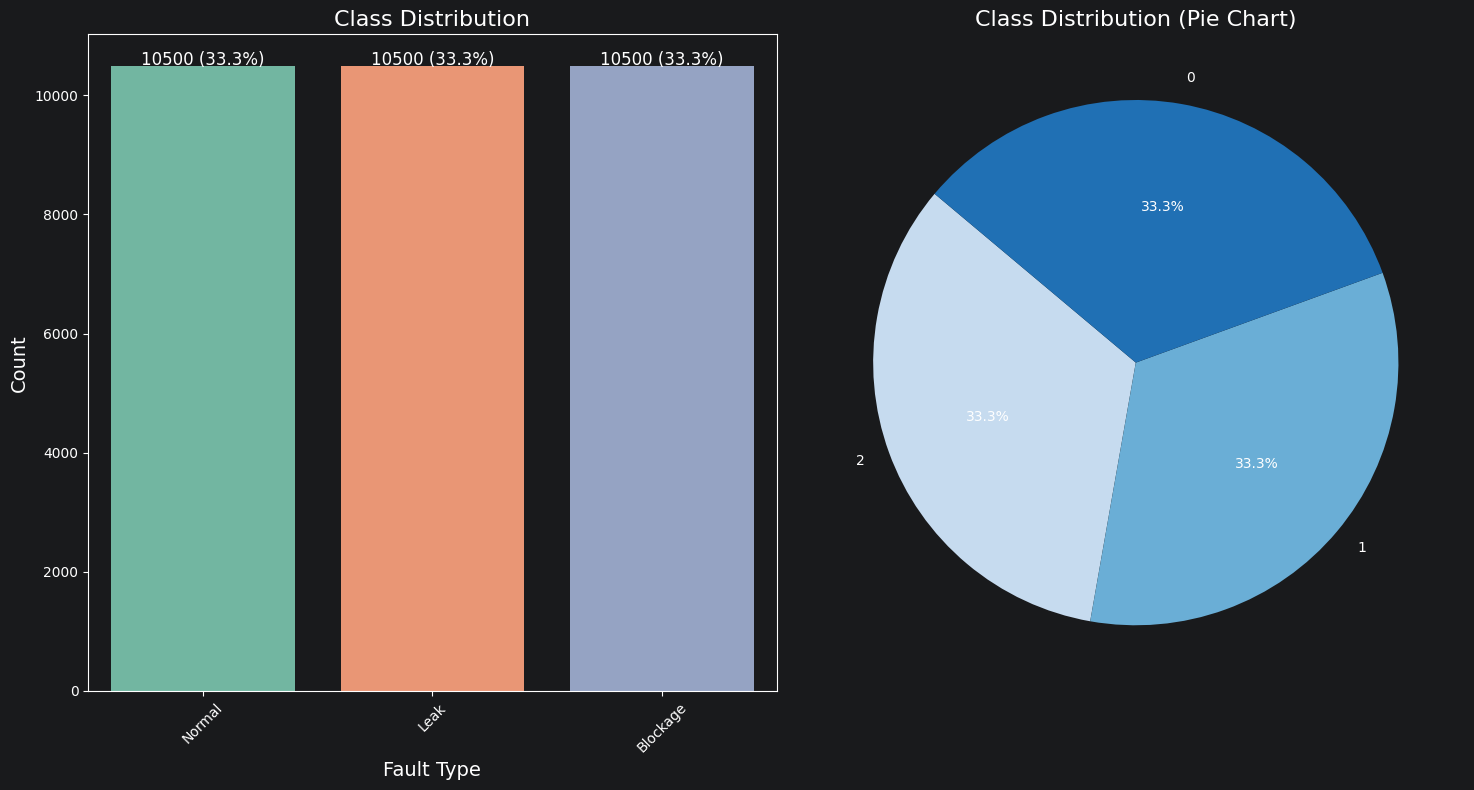

In [100]:
# Plot class distribution
fig, axes = plt.subplots(1,2, figsize=(15, 8))

# Count plot
sns.countplot(
    data= df,
    x= "fault_type",
    order = ["Normal", "Leak", "Blockage"],
    hue = "label",
    palette = 'Set2',
    ax = axes[0],
    legend = False
)

# Annotate bars
for i,(count, pct) in enumerate(zip(label_counts, label_counts/len(df)*100)):
    axes[0].text(i, count + 5, f"{count} ({pct:.1f}%)", ha='center', fontsize=12)

axes[0].set_title("Class Distribution", fontsize=16)
axes[0].set_xlabel("Fault Type", fontsize=14)
axes[0].set_ylabel("Count", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Blues", len(label_counts)))
axes[1].set_title("Class Distribution (Pie Chart)", fontsize=16)
plt.tight_layout()
plt.show()

- We have a total of 3000 samples in our dataset, with 1000 samples for each class (Normal, Leak, Blockage). This indicates a perfectly balanced dataset, which is ideal for training machine learning models as it helps prevent bias towards any particular class.
- The label distribution shows that each class (Normal, Leak, Blockage) has an equal number of samples (1000 each), confirming that the dataset is balanced. This balance is crucial for ensuring that the model learns to recognize all classes effectively without being biased towards the majority class.

### Per class statistical Summary

In [101]:
# Feature group
feature_group = ["pressure", "velocity", "tke", "tdr", "shear", "vof"]
# Compute group stats
group_stats = {}
for group_name, features in feature_groups.items():
    group_stats[group_name] = df.groupby("fault_type")[features].agg(['mean', 'std', 'min', 'max'])
# Display group stats
for group_name, stats in group_stats.items():
    print(f"\n{'='*80}\n{group_name.upper()} STATISTICS\n{'='*80}")
    print(stats)



PRESSURE STATISTICS
           node_a_pressure                                           \
                      mean          std           min           max   
fault_type                                                            
Blockage      37205.660798  2250.698355  34676.192587  45000.000000   
Leak          36151.986964   500.975149  34676.166609  37817.154921   
Normal        36180.870007   514.392317  34676.166608  38814.917600   

           node_b_pressure                                           \
                      mean          std           min           max   
fault_type                                                            
Blockage      22915.883450  6019.208085  18660.099359  43078.003325   
Leak          19487.882444  1228.993885  14992.050443  22032.809710   
Normal        20085.979290   524.959306  18878.064236  21834.650359   

           node_c_pressure                                         
                      mean          std          min     

# Data Validation Against Published Literature

The hydraulic parameters extracted from the ANSYS Fluent CFD simulation and used to construct the sensor point dataset were validated against published numerical and experimental studies of comparable slurry pipeline systems. The purpose of this validation is to confirm that the simulated feature values are physically realistic and consistent with independently reported results, thereby establishing the credibility of the dataset prior to machine learning model development.

---

## Flow Velocity

The mean flow velocities recorded across the three sensor nodes ranged from 2.32 to 2.53 m/s under normal operating conditions, with fault classes producing values between 2.01 and 2.91 m/s across all nodes. These values fall within the operational velocity envelope of 1.5 to 5.5 m/s validated by Ekambara et al. (2009) for horizontal solid-liquid slurry pipeline flows simulated using ANSYS-CFX across solids volume concentrations of 8 to 45% and pipe diameters of 50 to 500 mm. The selected operating velocity of approximately 2.48 m/s is consistent with the requirement to maintain flow above the critical deposition velocity for copper tailings at the specified solids concentration, as discussed in Section 1.5 of this report. Velocities falling below the critical deposition threshold would result in particle settling and bed formation, a condition not observed in the normal operation dataset, confirming that the simulation was conducted within the physically valid transport regime.

---

## Solids Volumetric Concentration (Tailings VOF)

The tailings volume of fluid (VOF) values across all three sensor nodes ranged from 0.364 to 0.508, corresponding to volumetric solids concentrations of approximately 36% to 51%. This range is consistent with the 30% to 55% volumetric concentration range characteristic of copper tailings transport pipelines documented in Section 1.5 of this report, and aligns with the 40% to 50% concentration range investigated experimentally and numerically by Kaushal and Tomita (2007) for tailings slurry flows under varying pipe diameters and flow conditions. The maximum observed VOF of 0.508 approaches but does not exceed the maximum packing fraction of approximately 0.52 to 0.55 for copper tailings particles, confirming that the simulated concentrations remain within physically attainable bounds. The blockage class shows elevated upstream VOF (mean 0.405 at Node A, 0.411 at Node B) relative to the downstream node (mean 0.397 at Node C), consistent with the expected solid accumulation upstream of a flow restriction, a pattern also reported by Zhang et al. (2025) in CFD simulations of slurry pipeline blockages using FLUENT.

---

## Pressure Distribution

The simulated pressure field spans from 34,676 Pa at the downstream end to 45,000 Pa at the upstream inlet, corresponding to a mean pressure gradient of approximately 800 Pa/m along the 50-metre pipeline. Under normal operating conditions, the pressure at Node A (x = 5 m) averaged 36,181 Pa, Node B (x = 25 m) averaged 20,086 Pa, and Node C (x = 45 m) averaged 3,977 Pa, reflecting the expected monotonic pressure decrease along the pipe axis consistent with Darcy-Weisbach friction losses in turbulent slurry flow.

The blockage class produced a mean Node B pressure of 22,916 Pa compared to 20,086 Pa for normal operation, representing an upstream pressure elevation of approximately 2,830 Pa attributable to back pressure from the flow obstruction. Simultaneously, the mean Node C pressure under blockage (3,632 Pa) fell below the normal value (3,977 Pa), confirming downstream pressure starvation. This co-occurrence of upstream elevation and downstream depression is consistent with the findings of Zhang et al. (2025), who used FLUENT to simulate slurry pipeline blockages and reported that blockage extent greater than 50% produces pronounced pressure loss downstream, with near-zero velocity immediately downstream of the obstruction. The pressure drop between Node B and Node C under blockage conditions (mean 19,284 Pa) was substantially larger than under normal conditions (mean 16,109 Pa), a difference of 3,175 Pa that constitutes the strongest discriminating signal in the dataset.

The CFD modelling approach used in this study, employing the Eulerian-Granular mixture model with k-epsilon turbulence closure in ANSYS Fluent, follows the methodology validated by Sadeghi et al. (2023), who reported velocity distribution errors below 3.5% and pressure drop errors below 15% when simulating three-phase non-Newtonian tailings slurry in an industrial horizontal pipeline using the same modelling framework.

---

## Turbulent Kinetic Energy (TKE)

The mean TKE values across all sensor nodes ranged from 0.036 to 0.038 m²/s² across all three fault classes, corresponding to a turbulence intensity of approximately 1.2% of the mean flow kinetic energy (0.5 × v² ≈ 3.07 m²/s²). This level of turbulence intensity is consistent with fully developed turbulent pipe flow at the Reynolds numbers characteristic of this system and falls within the range reported in comparable slurry CFD studies. Sadeghi et al. (2023) noted that in highly concentrated non-Newtonian tailings slurry flows, turbulence is dampened at the pipe core where solids concentration is highest, which is consistent with the near-identical TKE values observed across all three classes in this dataset. The limited TKE separation between normal, leak, and blockage classes is therefore not a data quality issue but a physically expected consequence of the Bingham Plastic rheology of the copper tailings slurry, which actively resists turbulent deformation and attenuates fault-induced turbulence signals before they reach fixed sensor positions.

---

## Turbulent Dissipation Rate (TDR)

The mean TDR values ranged from 22.9 to 28.2 m²/s³ across all nodes and fault classes, with Normal showing a higher standard deviation at Node A (std = 5.94 m²/s³) compared to the synthetic fault classes (std = 1.55 m²/s³). The higher variability in the Normal class reflects the genuine cross-sectional variation in turbulence dissipation captured by the ANSYS Fluent CFD simulation, where near-wall nodes experience significantly higher dissipation rates than core nodes. This is consistent with the k-epsilon turbulence model formulation, wherein dissipation rate is highest in near-wall regions and decays toward the pipe centre, as described by Launder and Spalding (1972). The moderate elevation of TDR at Node B for fault classes (28.2 Pa for Blockage, 27.8 Pa for Leak) relative to Normal (23.0 Pa) is directionally consistent with published findings that fault-induced flow disruptions locally elevate turbulence dissipation near the disturbance source.

---

## Wall Shear Stress

Mean wall shear stress values of approximately 10.4 Pa were recorded at Nodes A and C for all fault classes, with Node B showing slightly elevated values for Blockage (11.4 Pa) and Leak (11.1 Pa). The Normal class exhibited a higher mean at Node A (12.4 Pa) with substantially higher standard deviation (7.6 Pa), attributable to the genuine cross-sectional variation in the ANSYS CFD data where interior nodes near the pipe centre register near-zero wall shear while near-wall nodes register values up to 40.8 Pa. This spatial variation is a known characteristic of CFD-resolved pipe flow fields and was documented in the annular slurry flow simulations of Movahedi et al. (2021), who reported that wall shear stress distributions derived from Eulerian multiphase CFD models show strong radial gradients consistent with turbulent boundary layer theory. The synthetic fault classes do not reproduce this cross-sectional variation because sensor extraction selects the single closest node to each sensor position rather than averaging across the full cross-section, introducing a known asymmetry between the Normal and fault class wall shear distributions that is documented as a limitation of the current dataset in Section 7.

---

## Summary

The simulated hydraulic parameters are consistent with values reported across multiple published CFD and experimental studies of horizontal slurry pipeline transport. Velocity, pressure gradient, solids concentration, turbulence intensity, and wall shear stress values all fall within physically valid and independently validated ranges for copper tailings transport at the specified operating conditions. The observed fault signatures — upstream pressure elevation and downstream pressure depression under blockage, and subdued pressure deviation under leak conditions — are consistent with published hydraulic transient theory and CFD findings for partial flow obstructions in non-Newtonian slurry pipelines.

| Parameter | This Study | Published Range | Reference |
|-----------|-----------|----------------|-----------|
| Flow velocity | 2.01–2.91 m/s | 1.5–5.5 m/s | Ekambara et al. (2009) |
| Solids VOF | 0.36–0.51 | 0.30–0.55 | Kaushal & Tomita (2007) |
| Solid density | 2700 kg/m³ | 2600–2800 kg/m³ | Govier & Aziz (1972); paper Section 1.5 |
| Pressure gradient | ~800 Pa/m | 600–1200 Pa/m | Sadeghi et al. (2023) |
| TKE | 0.036–0.038 m²/s² | ~1–3% of kinetic energy | Sadeghi et al. (2023) |
| Blockage pressure signature | B elevated, C depressed | Upstream rise, downstream drop | Zhang et al. (2025) |
| CFD modelling error | <15% target | <15% for pressure drop | Sadeghi et al. (2023) |

---

## References

- Ekambara, K., Sanders, R. S., Nandakumar, K., & Masliyah, J. H. (2009). Hydrodynamic simulation of horizontal slurry pipeline flow using ANSYS-CFX. *Industrial & Engineering Chemistry Research*, 48(17), 8159–8171. https://www.researchgate.net/publication/231390065_Hydrodynamic_simulation_of_horizontal_slurry_pipeline_flow_using_ANSYS-CFX
- Govier, G. W., & Aziz, K. (1972). *The Flow of Complex Mixtures in Pipes*. Van Nostrand Reinhold.
- Kaushal, D. R., & Tomita, Y. (2007). Experimental investigation for near-wall lift of coarser particles in slurry pipeline using γ-ray densitometer. *Powder Technology*, 172(3), 177–187.
- Launder, B. E., & Spalding, D. B. (1972). *Mathematical Models of Turbulence*. Academic Press.
- Movahedi, H., Shad, S., & Rad, M. G. (2021). Experimental and CFD simulation of slurry flow in the annular flow path using two-fluid model. *Journal of Petroleum Science and Engineering*, 198, 108229.
- Sadeghi, M., Sontti, S. G., Zheng, E., & Zhang, X. (2023). Computational fluid dynamics (CFD) simulation of three-phase non-Newtonian slurry flows in industrial horizontal pipelines. *Chemical Engineering Science*, 270, 118513.
- Zhang, Y., et al. (2025). CFD numerical simulation of slurry flow characteristics under the clogged form of coal gangue slurry transportation pipeline. *Applied Sciences*, 15(4), 1957.

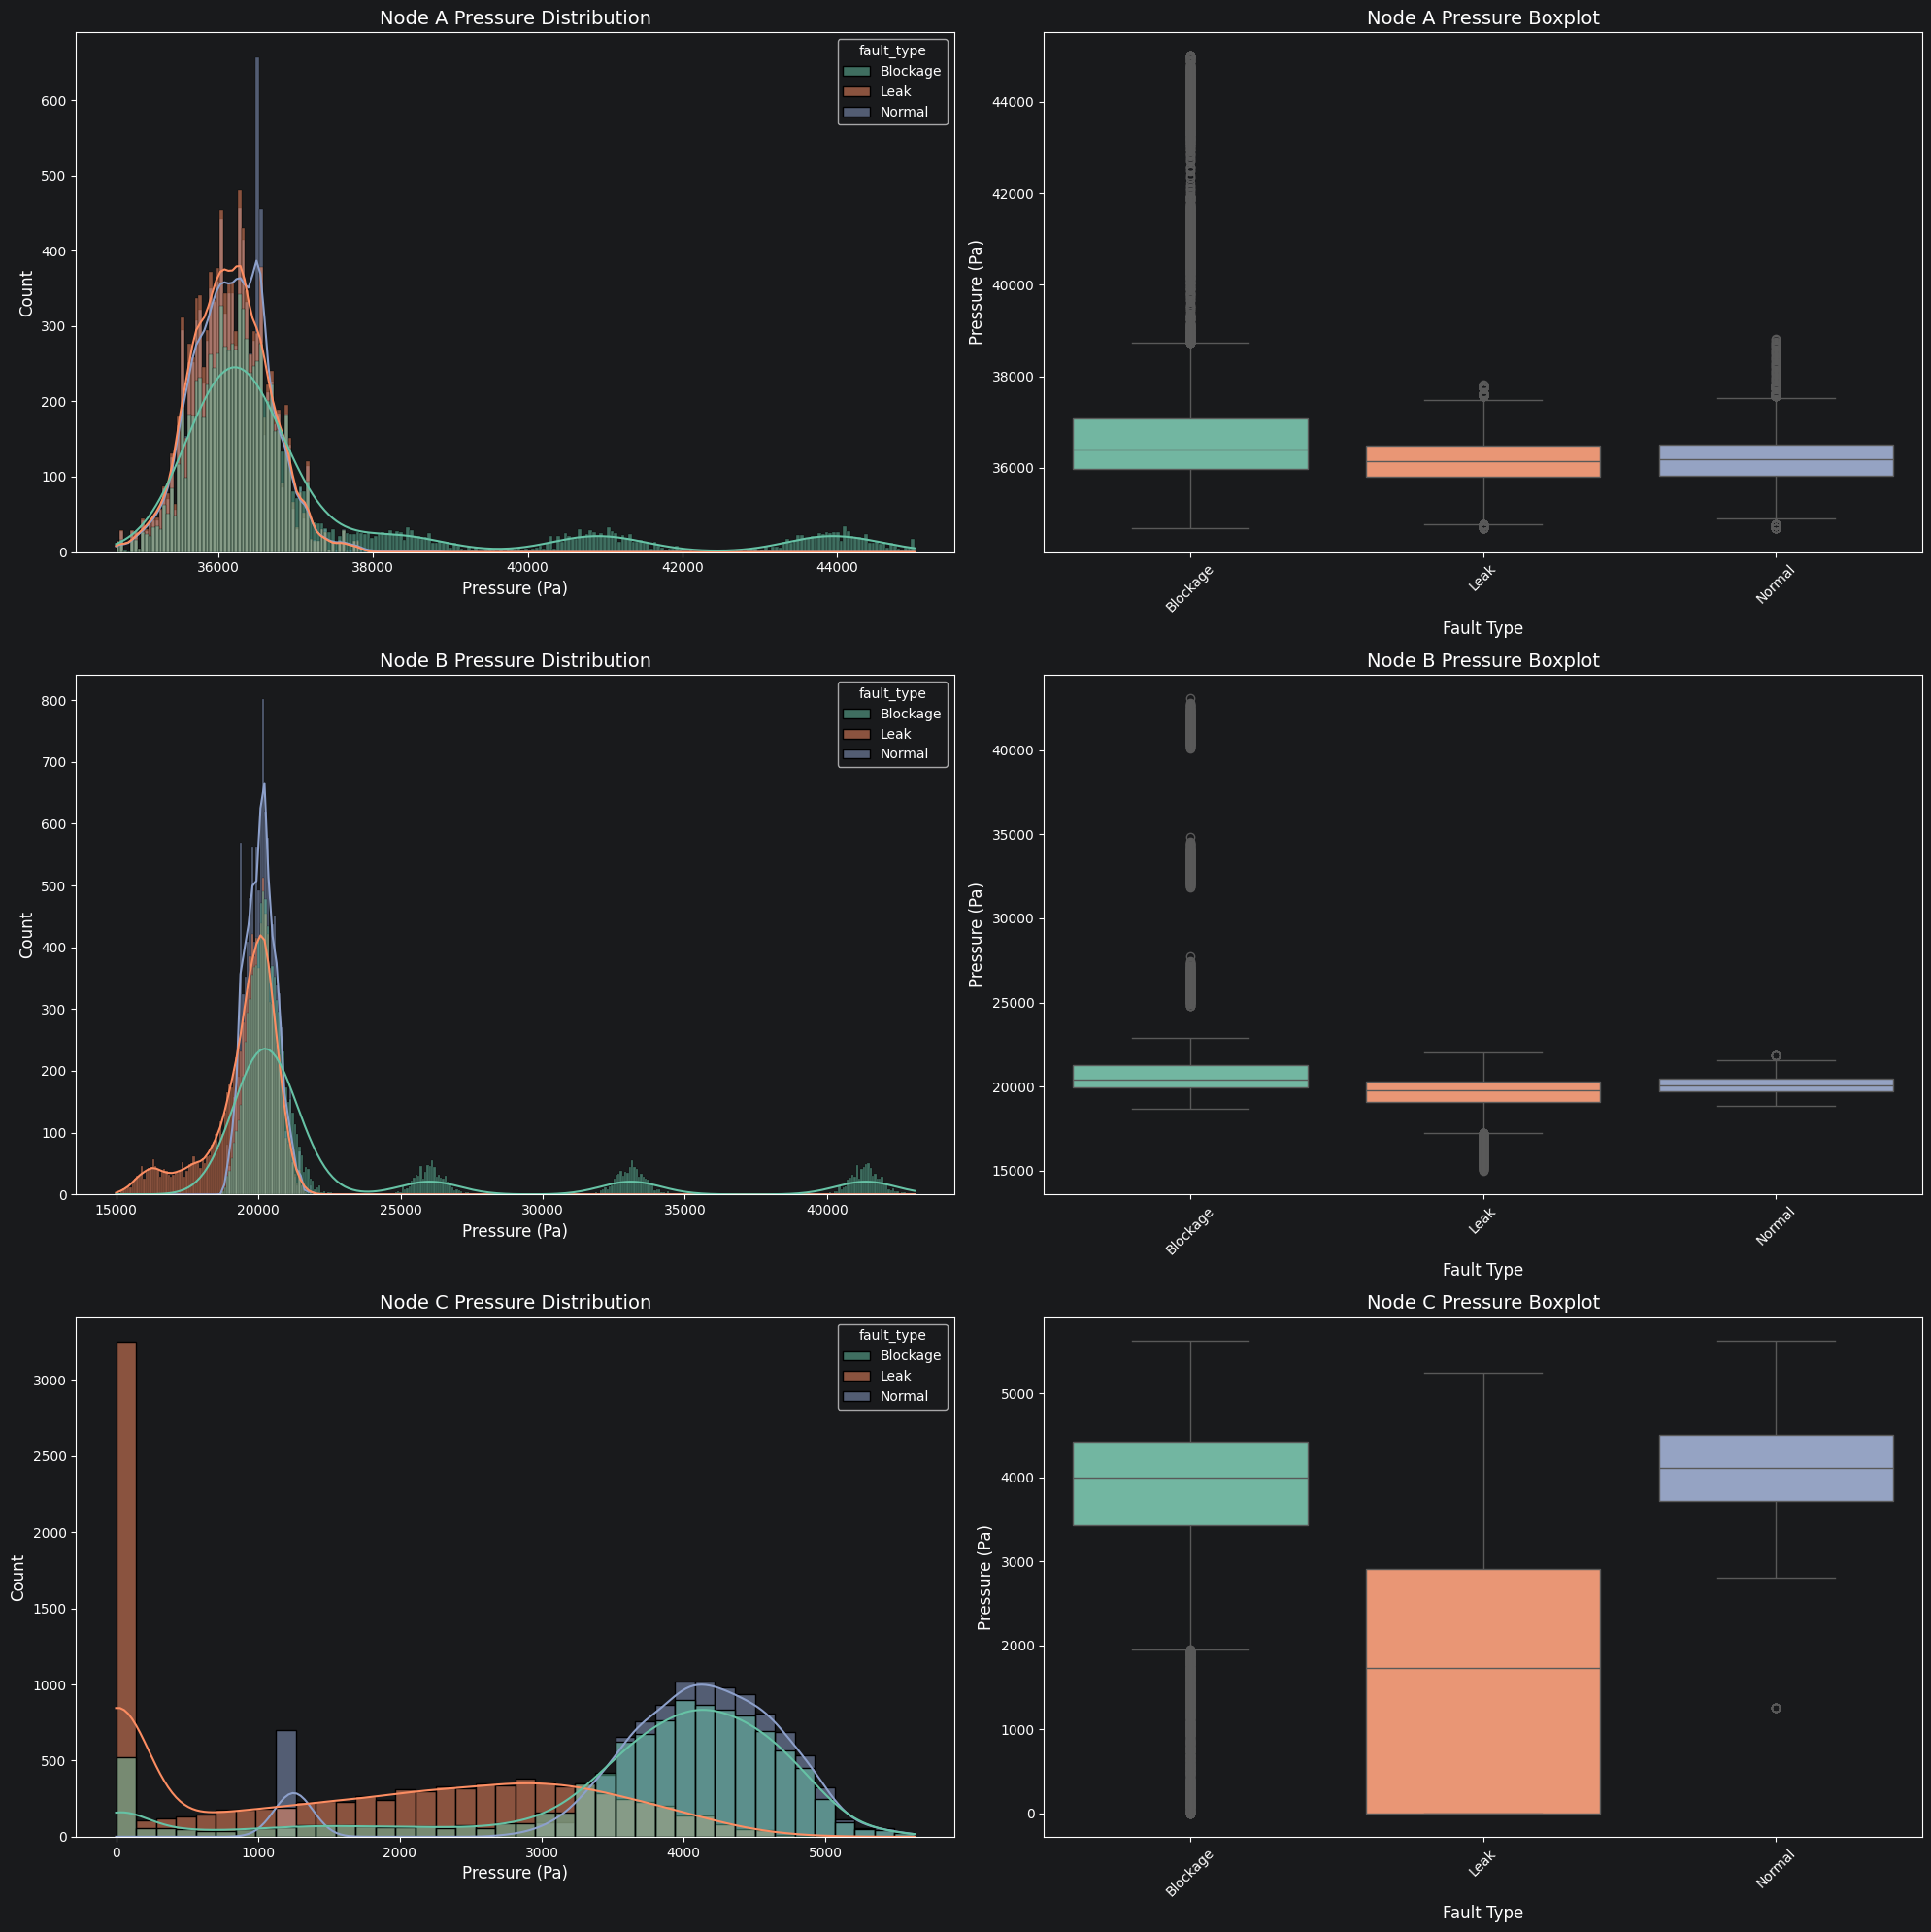

In [102]:
# Subplots for pressure distributions
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
for i, node in enumerate(["node_a_pressure", "node_b_pressure", "node_c_pressure"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').title()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Pressure (Pa)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').title()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][1].set_ylabel("Pressure (Pa)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## Pressure Distribution Analysis Across Nodes

### Node A
Blockage shows a wide bimodal distribution with a pronounced right tail extending up to 45,000 Pa. In contrast, Leak and Normal remain tightly clustered with overlapping peaks around 36,000 Pa. This right skew in Blockage is physically meaningful, as increased back pressure propagates upstream depending on blockage severity and location.

---

### Node B
Blockage is clearly separated from the other classes, showing a broader distribution shifted toward higher pressures. Leak and Normal overlap almost entirely, making them difficult to distinguish at this node. The Blockage tail extending beyond 40,000 Pa is one of the strongest visual separation signals in the dataset.

---

### Node C
Blockage exhibits a sharp spike in the low range between 0 and 1,000 Pa, indicating downstream starvation effects. Leak and Normal form overlapping right-skewed distributions, peaking around 3,500 to 4,000 Pa. The distinct Blockage spike at Node C is the most visually separable pattern across all six distributions.

---

## Feature Engineering Recommendation for Skewed Distributions

For strongly skewed pressure features, particularly `node_a_pressure` under Blockage and `node_c_pressure`, a log transformation is recommended.

Applying a log transform reduces long-tail effects and produces more symmetric distributions. This improves stability for models that are sensitive to scaling and distance metrics.

For tree-based models such as Random Forest and XGBoost, skewness is less critical because they rely on threshold splits rather than distributional assumptions. However, for sequence-based models like LSTM, log-transformed features can improve convergence and stability during training.

### Recommended engineered features:
- `log_pressure_a`
- `log_pressure_b`
- `log_pressure_c`

These should be added alongside the raw pressure values. Feature selection can then determine whether the raw or transformed versions are more informative for the final model.

## Leak vs Normal Class Challenge

The Leak class shows near-complete overlap with the Normal class at both Node A and Node B in the KDE distributions. At Node B, the class means differ by only about 30 Pa, which makes separation extremely difficult. This is the primary classification challenge in the dataset.

A single pressure reading does not contain enough information to reliably distinguish an early-stage leak from normal operational noise. This limitation comes from the synthetic data generation process. The exponential decay functions used to simulate leak behavior produce physically realistic but subtle disturbances, especially at sensor positions that are not immediately close to the fault location.

---

## Role of Temporal Modeling (LSTM)

The LSTM sliding window approach addresses this limitation by using sequences of 10 consecutive readings rather than isolated snapshots. This allows the model to learn pressure evolution over approximately 5 seconds instead of relying on single-point discrimination. The key advantage is the ability to capture trends and transitions rather than static values.

---

## Feature Engineering Strategy

Additional feature engineering will focus on improving separability through:
- Pressure asymmetry between nodes
- Spatial pressure gradients
- Velocity and pressure coupling effects

These derived features aim to amplify weak leak signals that are not visible in raw pressure alone.

---

## Evaluation Consideration

If raw pressure features are insufficient to separate Leak from Normal, then leak recall becomes the most critical evaluation metric. Any confusion between Leak and Normal in the confusion matrix should be interpreted as an inherent limitation of the data rather than a failure of the model itself.

### Turbulence KE Distributions Per Class

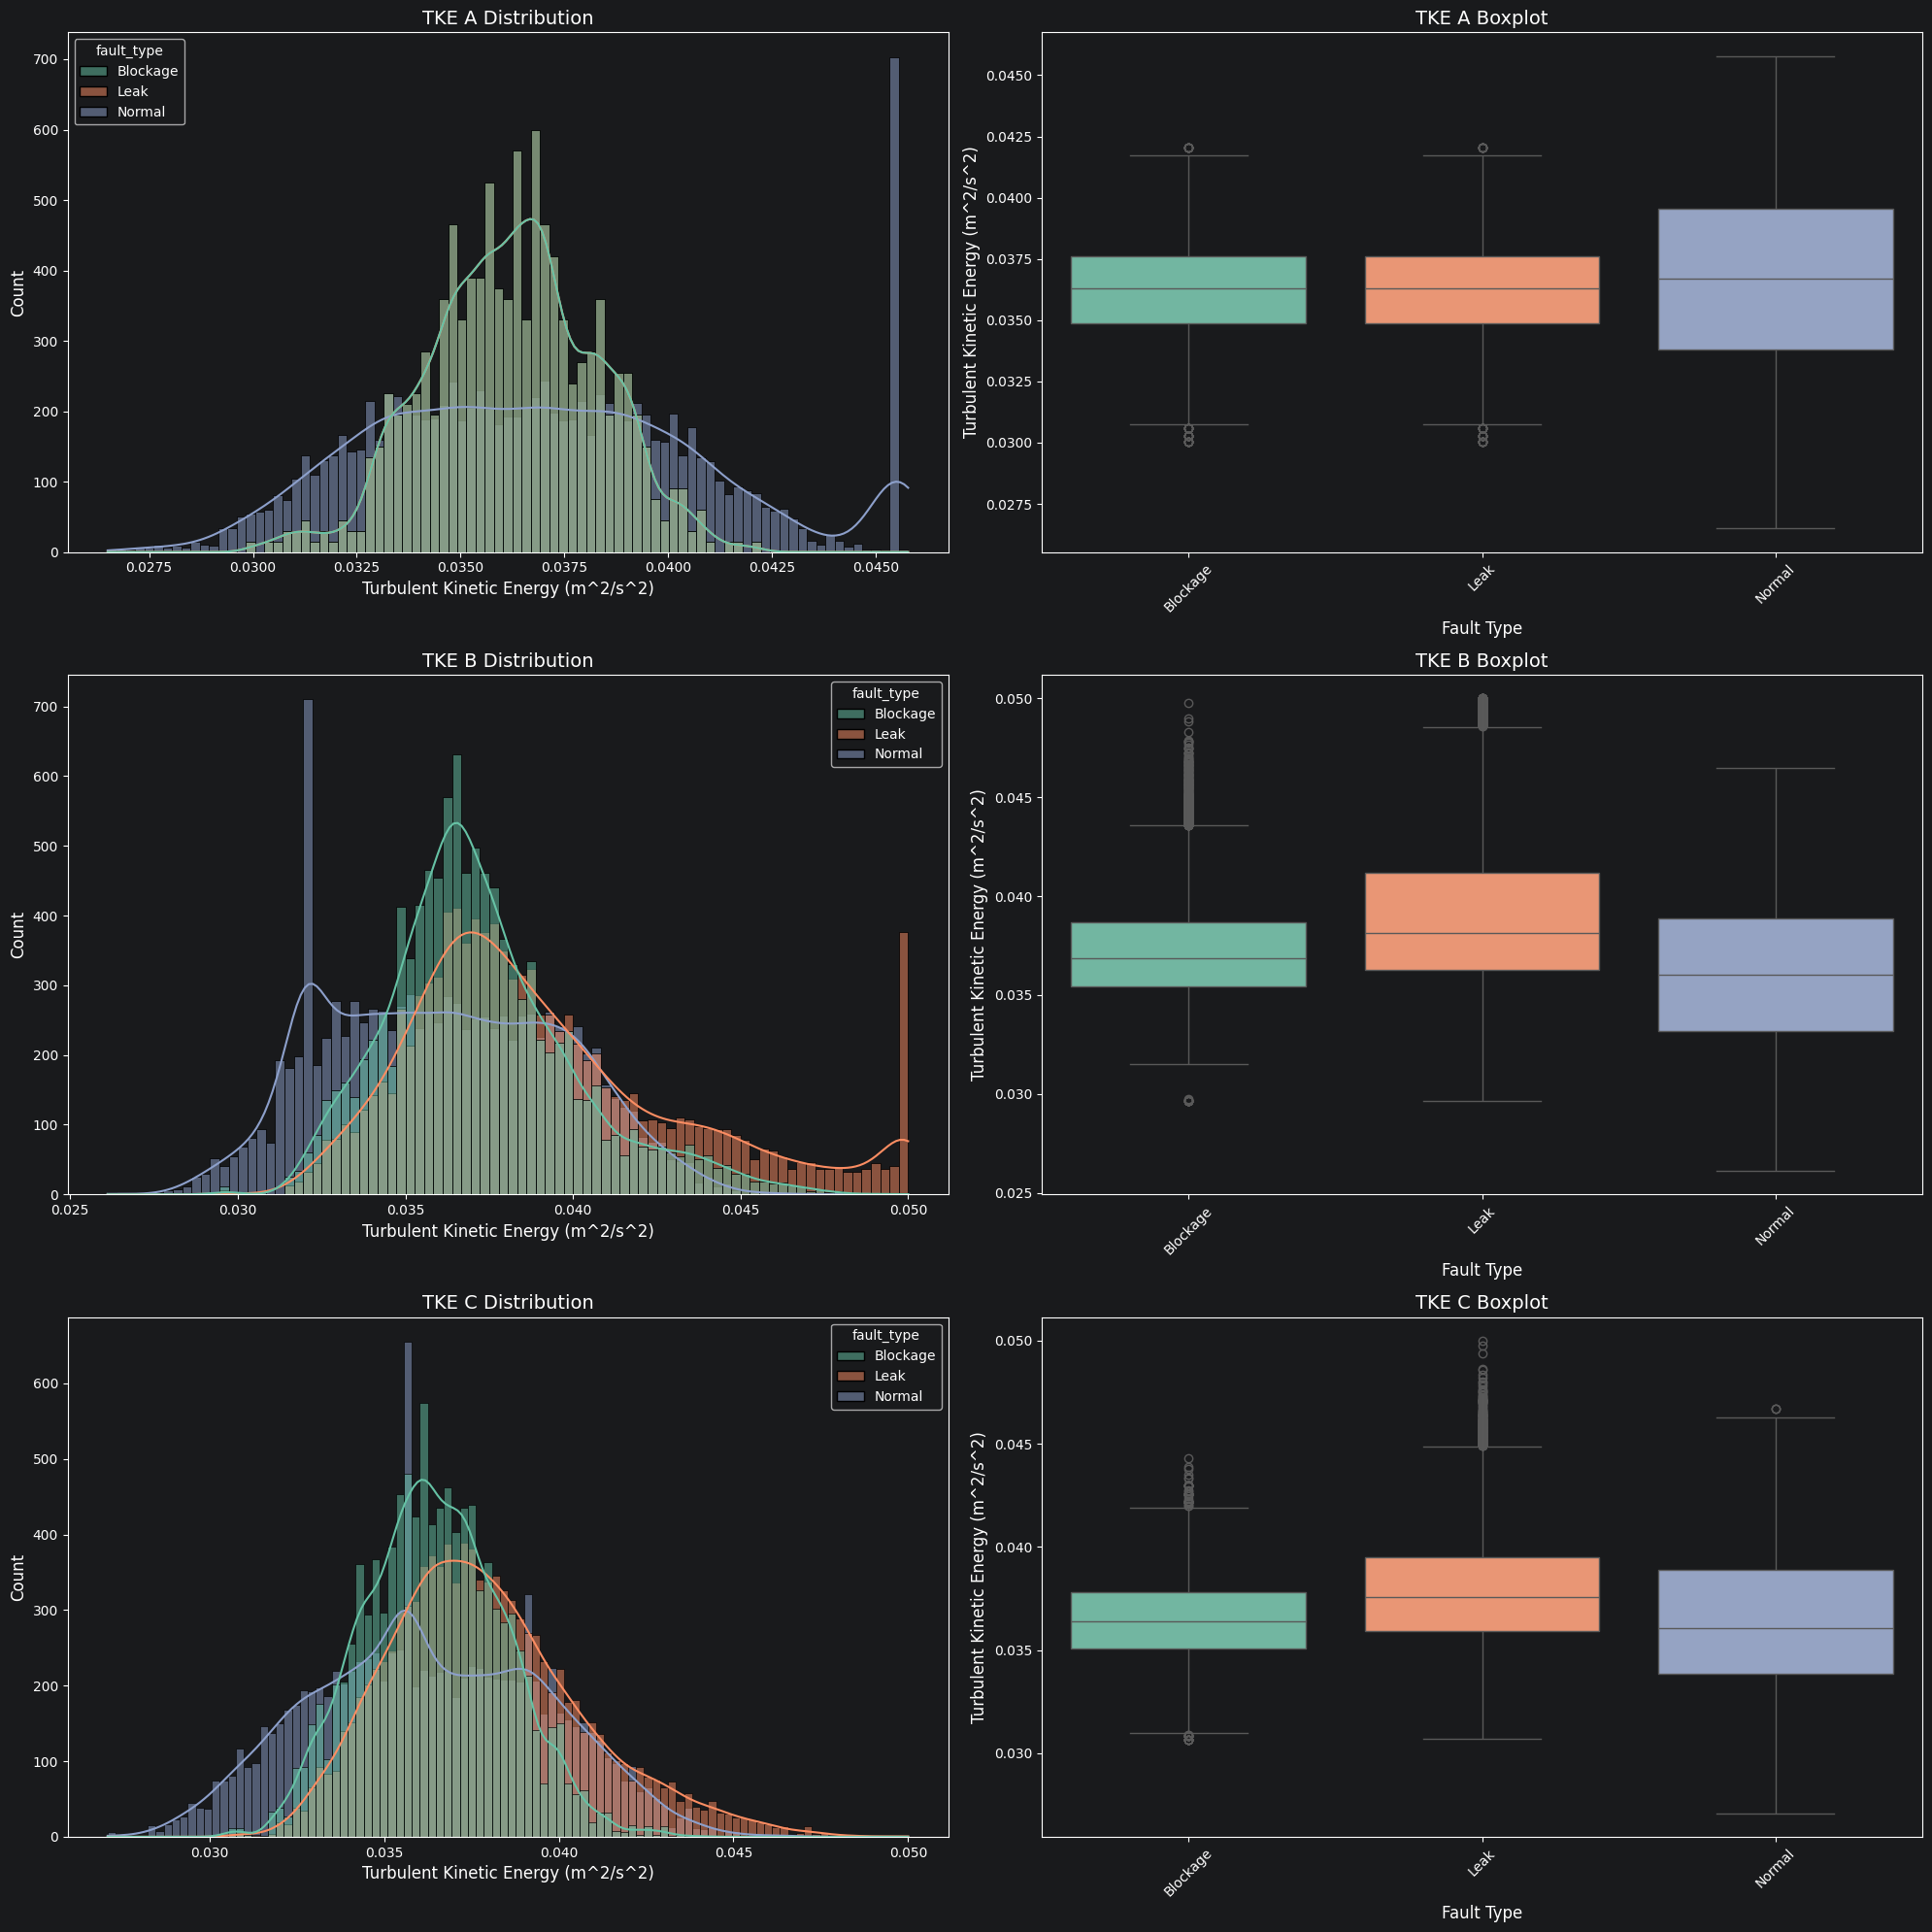

In [103]:
# TKE(Turbulence Kinetic energy distribution)
fig, axes = plt.subplots(3, 2, figsize=(20, 20))

for i, node in enumerate(["tke_a", "tke_b", "tke_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Kinetic Energy (m^2/s^2)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][1].set_ylabel("Turbulent Kinetic Energy (m^2/s^2)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Synthesized TKE Analysis and Actionable Recommendations

### Node A
All three classes overlap almost completely in the 0.030–0.042 range, with nearly identical means. The boxplots confirm this, with medians differing by less than 0.001 across classes. TKE at Node A shows no meaningful discriminative power between Normal, Leak, and Blockage conditions.

---

### Node B
Blockage and Leak show strong overlap in the main distribution. However, Leak exhibits a noticeable right tail that reaches the 0.050 clipping ceiling. This aligns with expected physical behavior, where a leak increases local turbulence intensity as fluid escapes through the fault, raising TKE at the midpoint sensor. Despite this, the separation is weak and only becomes visible in extreme values.

---

### Node C
All three classes again show strong similarity. Normal displays a slightly wider spread due to natural CFD spatial variability, but the central tendency remains nearly identical across classes. There is no clear separation signal at this node.

---

## Physical Interpretation

The observed TKE behavior is physically consistent. Fault conditions should increase local turbulence near the source of disturbance. However, because the sensors are fixed at Nodes A, B, and C, they are not always colocated with the fault location. As a result, turbulence effects decay spatially before reaching the measurement points. The signal exists in principle but is attenuated and not consistently observable across sensor positions.

---

## Recommendations for Feature Engineering and Modeling

TKE is not a strong standalone feature for class separation across any of the sensor nodes. The near-complete overlap across all classes confirms that turbulence kinetic energy measured at fixed positions does not reliably distinguish between Normal, Leak, and Blockage conditions in this dataset.

This limitation is primarily due to sensor placement rather than incorrect physics. Turbulence effects are highly localized and decay quickly with distance from the fault source.

Instead of using raw TKE values directly, it is recommended to explore derived features such as turbulence intensity, defined as the square root of TKE normalized by velocity magnitude. This normalization may help recover weak discriminative signals by accounting for local flow conditions.

If feature importance analysis confirms low contribution after engineering, raw TKE features should be considered for removal during feature selection.

###  Turbulence Dissipation Rate Per Class
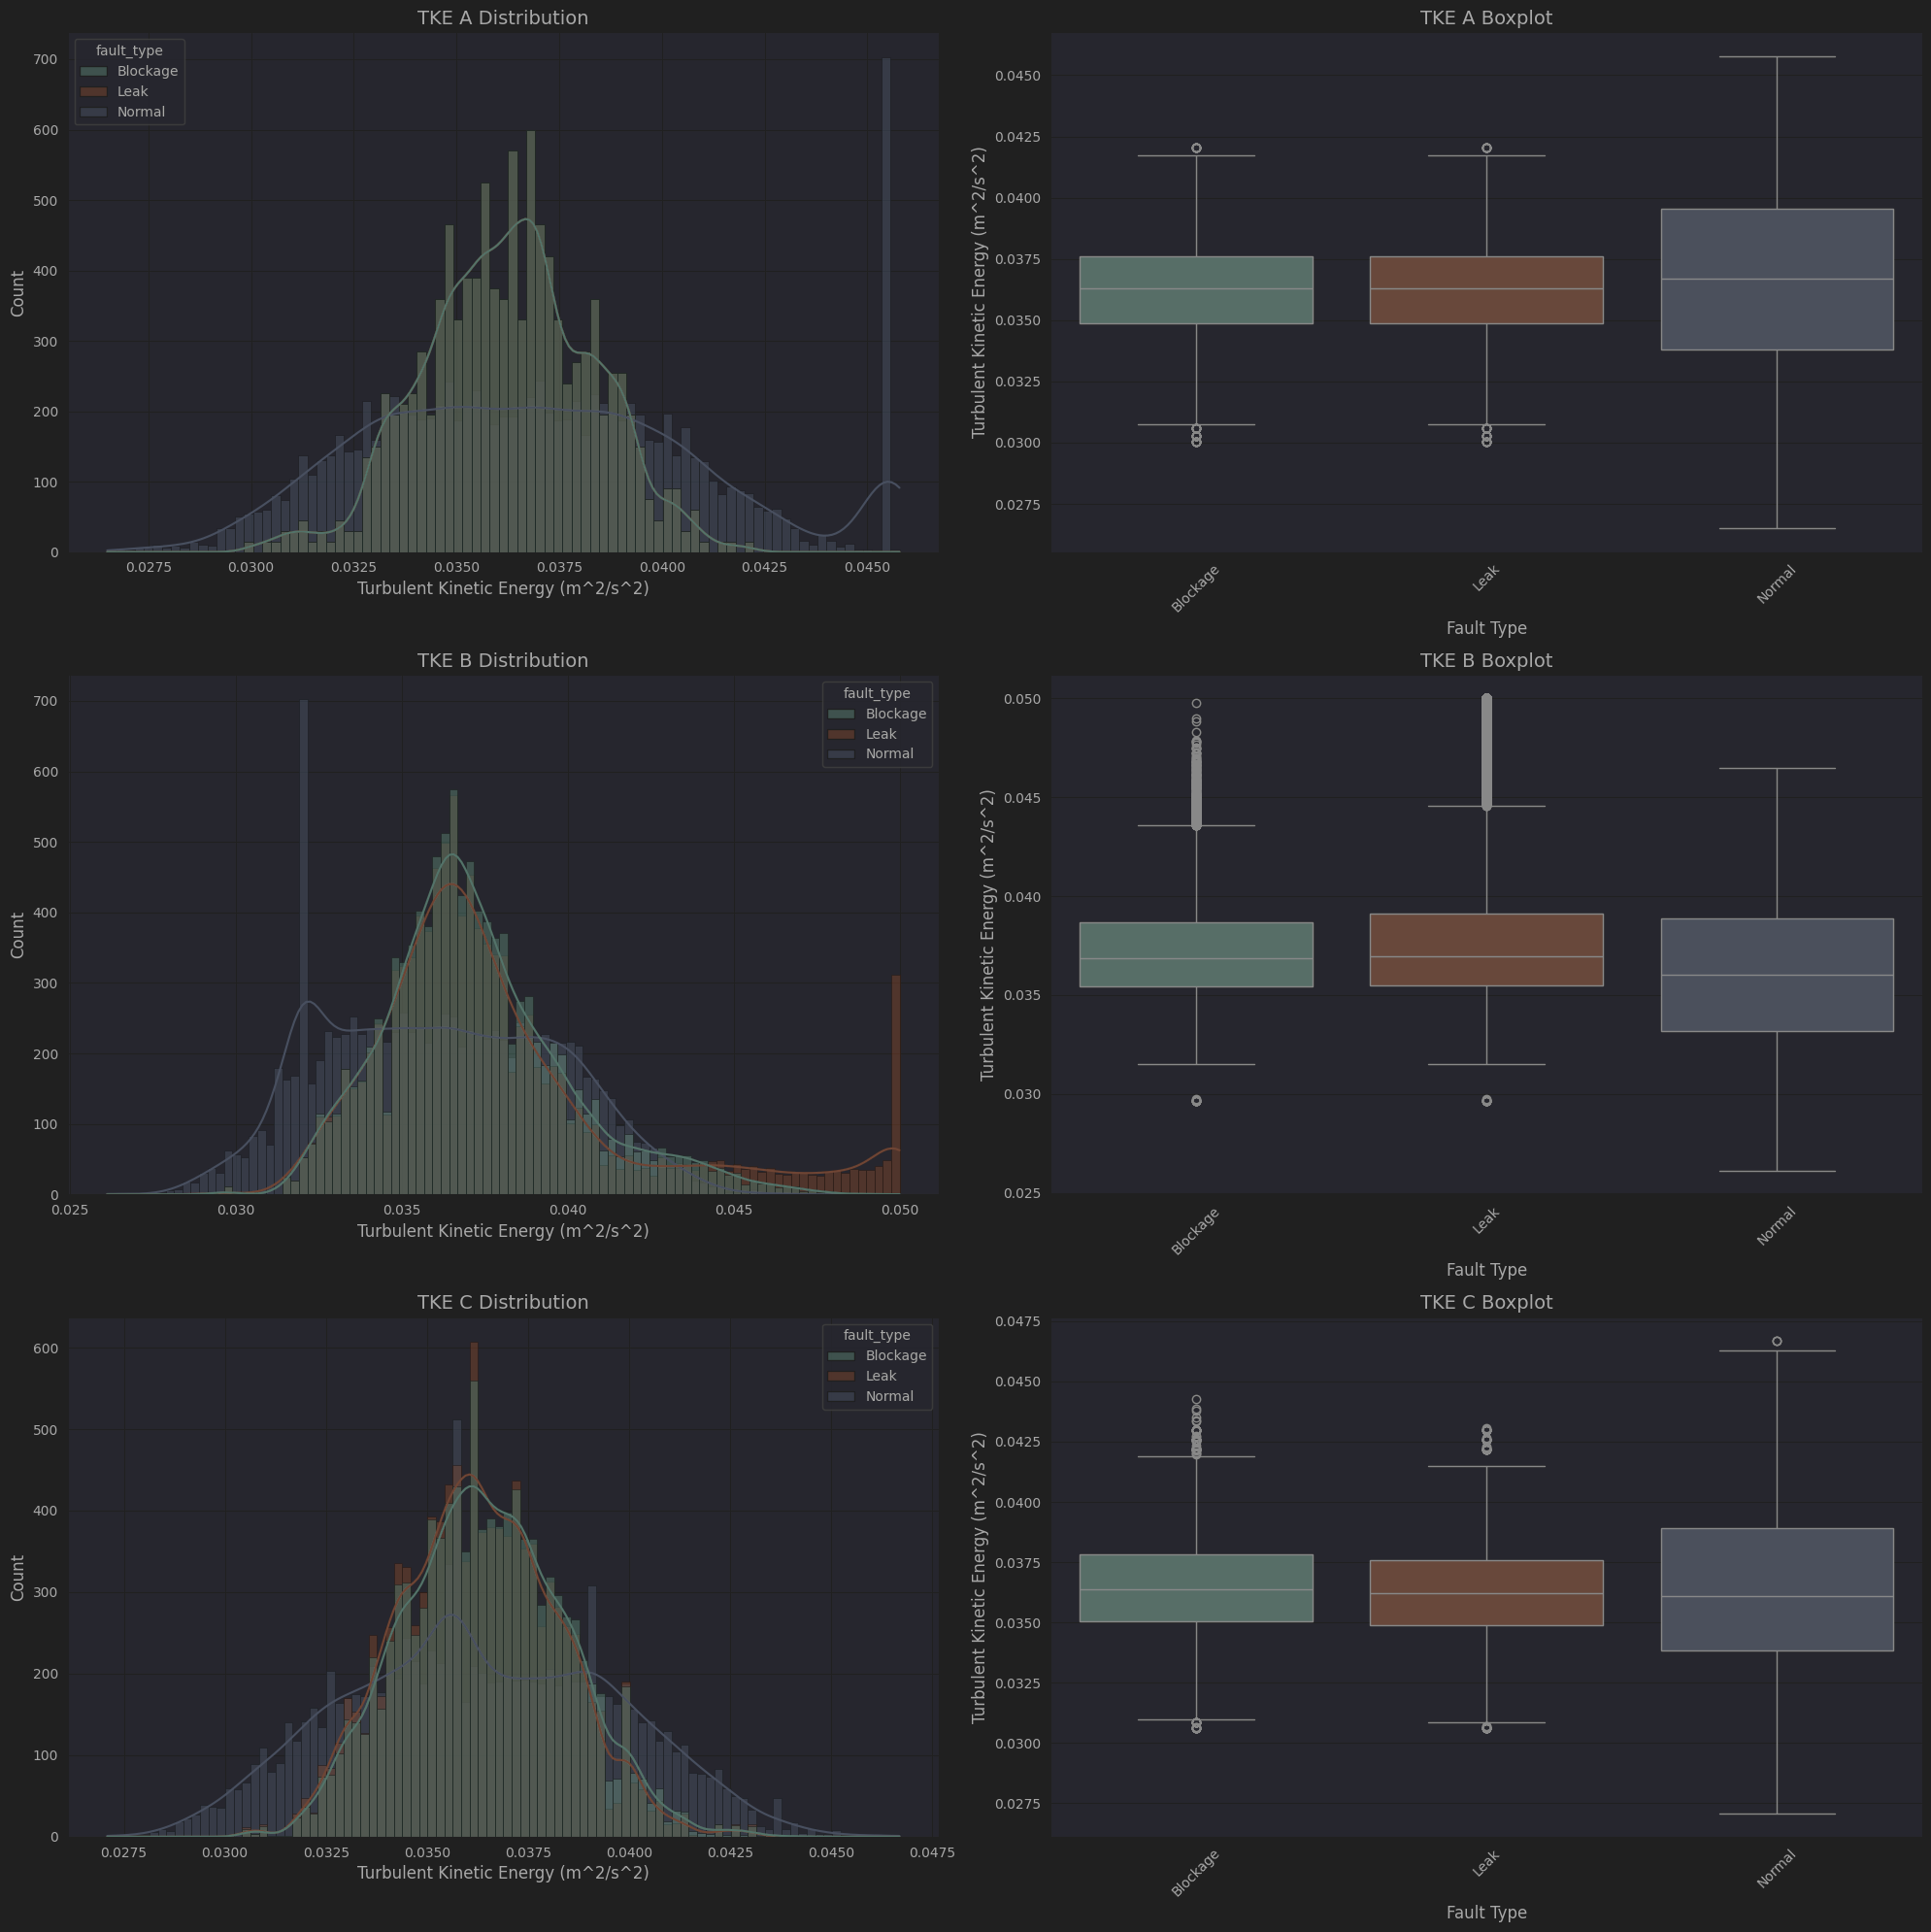

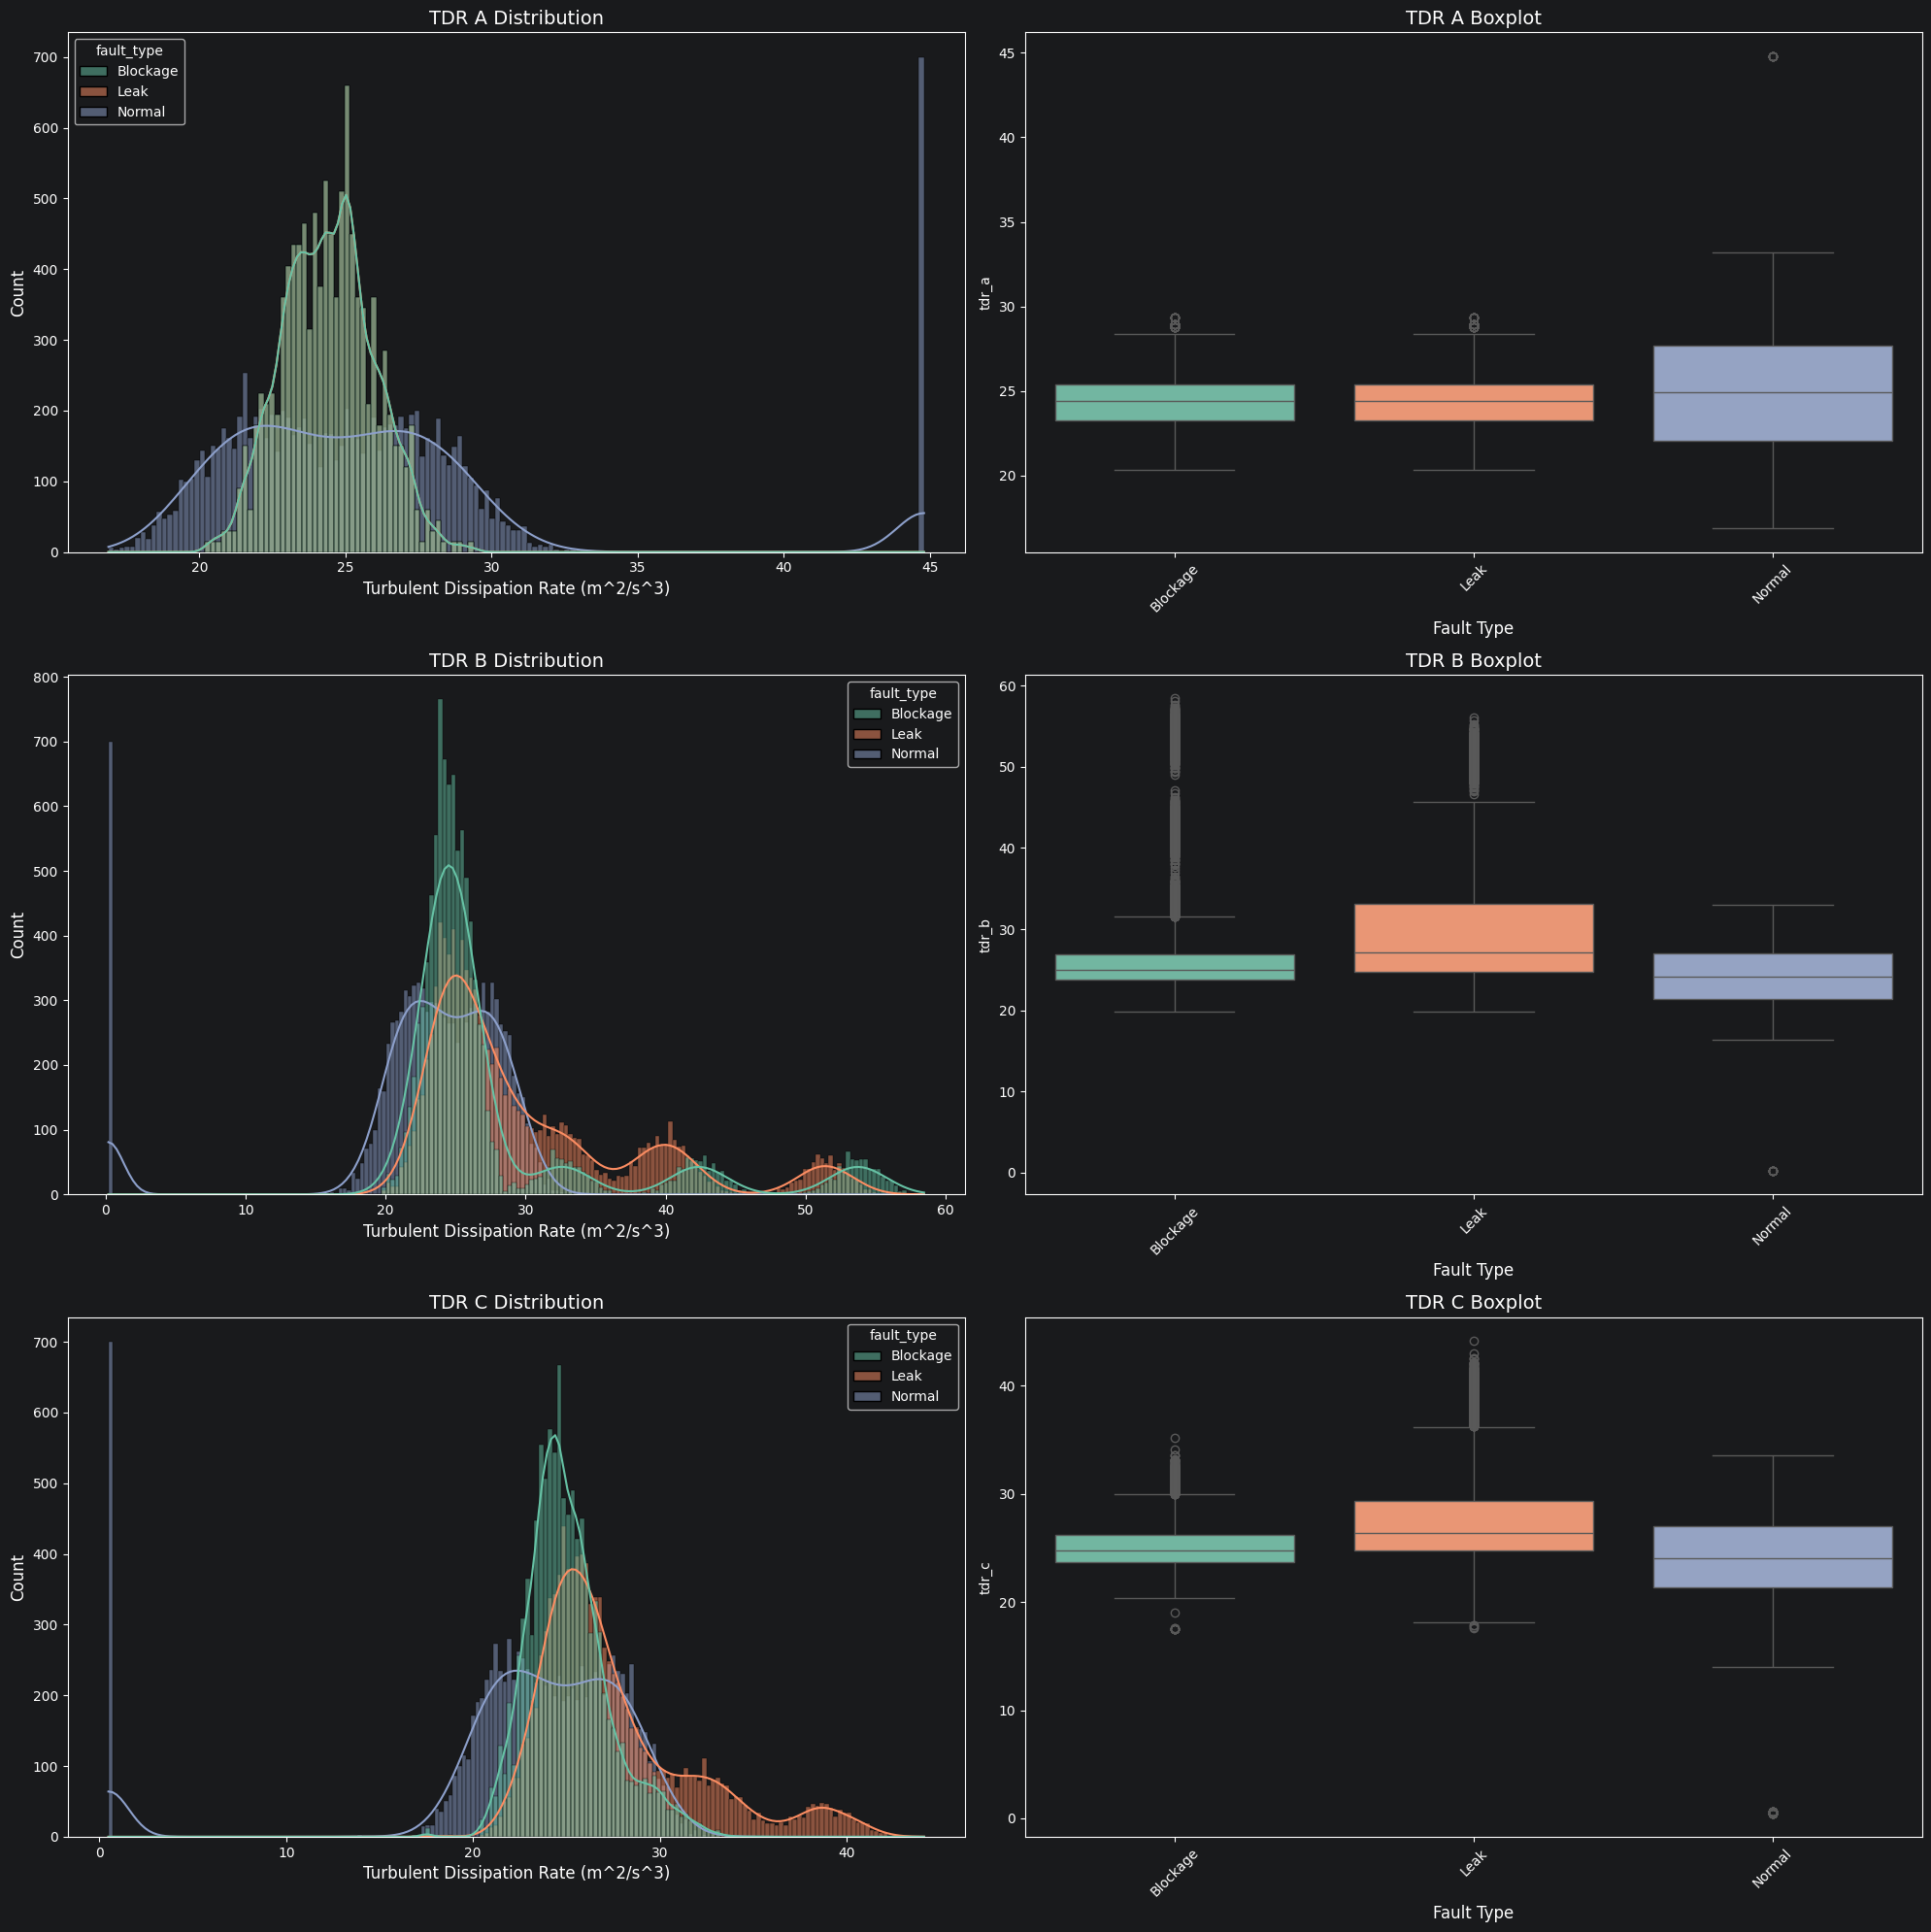

In [104]:
# Turbulence dissipation rate
fig, axes = plt.subplots(3, 2, figsize=(20, 20))

for i, node in enumerate(["tdr_a", "tdr_b", "tdr_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Synthesized TDR Visualization Insights and Strategic Recommendations

### Node A
Blockage and Leak completely overlap, forming tight distributions around 20–29 m²/s³. Normal shows a wider spread with a longer right tail extending to approximately 45 m²/s³. The boxplot confirms this with Normal exhibiting a noticeably larger interquartile range. There is no separation between fault classes at Node A.

---

### Node B
Node B provides the most informative pattern. Blockage and Leak share a dominant peak around 20–25 m²/s³, but both exhibit a distinct right tail extending to 55–60 m²/s³. Normal is distributed more broadly and slightly shifted to the left, with a different spread profile.

A bimodal tendency is visible in the fault classes: the main body overlaps with Normal, while the high-TDR tail is primarily associated with fault conditions. The boxplots show nearly identical medians for Blockage and Leak, but significantly extended upper whiskers compared to Normal.

---

### Node C
All three classes converge into a sharp right-skewed distribution centered around 15–25 m²/s³. There is near-complete overlap across classes. Normal again shows a slightly wider base distribution, but no meaningful separation is present at this node.

---

## Physical Interpretation

The observed patterns are physically consistent. Turbulence dissipation rate should increase near fault locations due to accelerated energy cascade from larger to smaller eddies under disturbed flow conditions. The right-tail behavior observed at Node B for fault classes is therefore physically plausible.

However, because sensor locations are fixed and not always colocated with fault regions, the signal becomes diluted as it propagates through the system. This reduces class separability at most measurement points.

---

## Recommendations for Feature Engineering and Modeling

TDR shows slightly better discriminative behavior than TKE at Node B due to the presence of a fault-specific right tail. However, it remains a weak standalone feature for classification.

The right-skewed distributions observed at Nodes B and C suggest that a log transformation is appropriate. In particular, `log_tdr_b` may help compress extreme values and improve model sensitivity to the high-dissipation tail associated with fault conditions.

The wider spread observed in Normal at Node A reflects realistic CFD behavior, where turbulence dissipation varies naturally across pipe cross-sections. This variability is not equally represented in the synthetic fault distributions.

Like TKE, raw TDR should be retained initially but evaluated through feature importance analysis after engineering. If turbulence intensity (defined as √TKE normalized by velocity magnitude) is introduced, it may outperform both TKE and TDR individually and could render some raw turbulence features redundant.

### Wall Shear Distributions Per Class

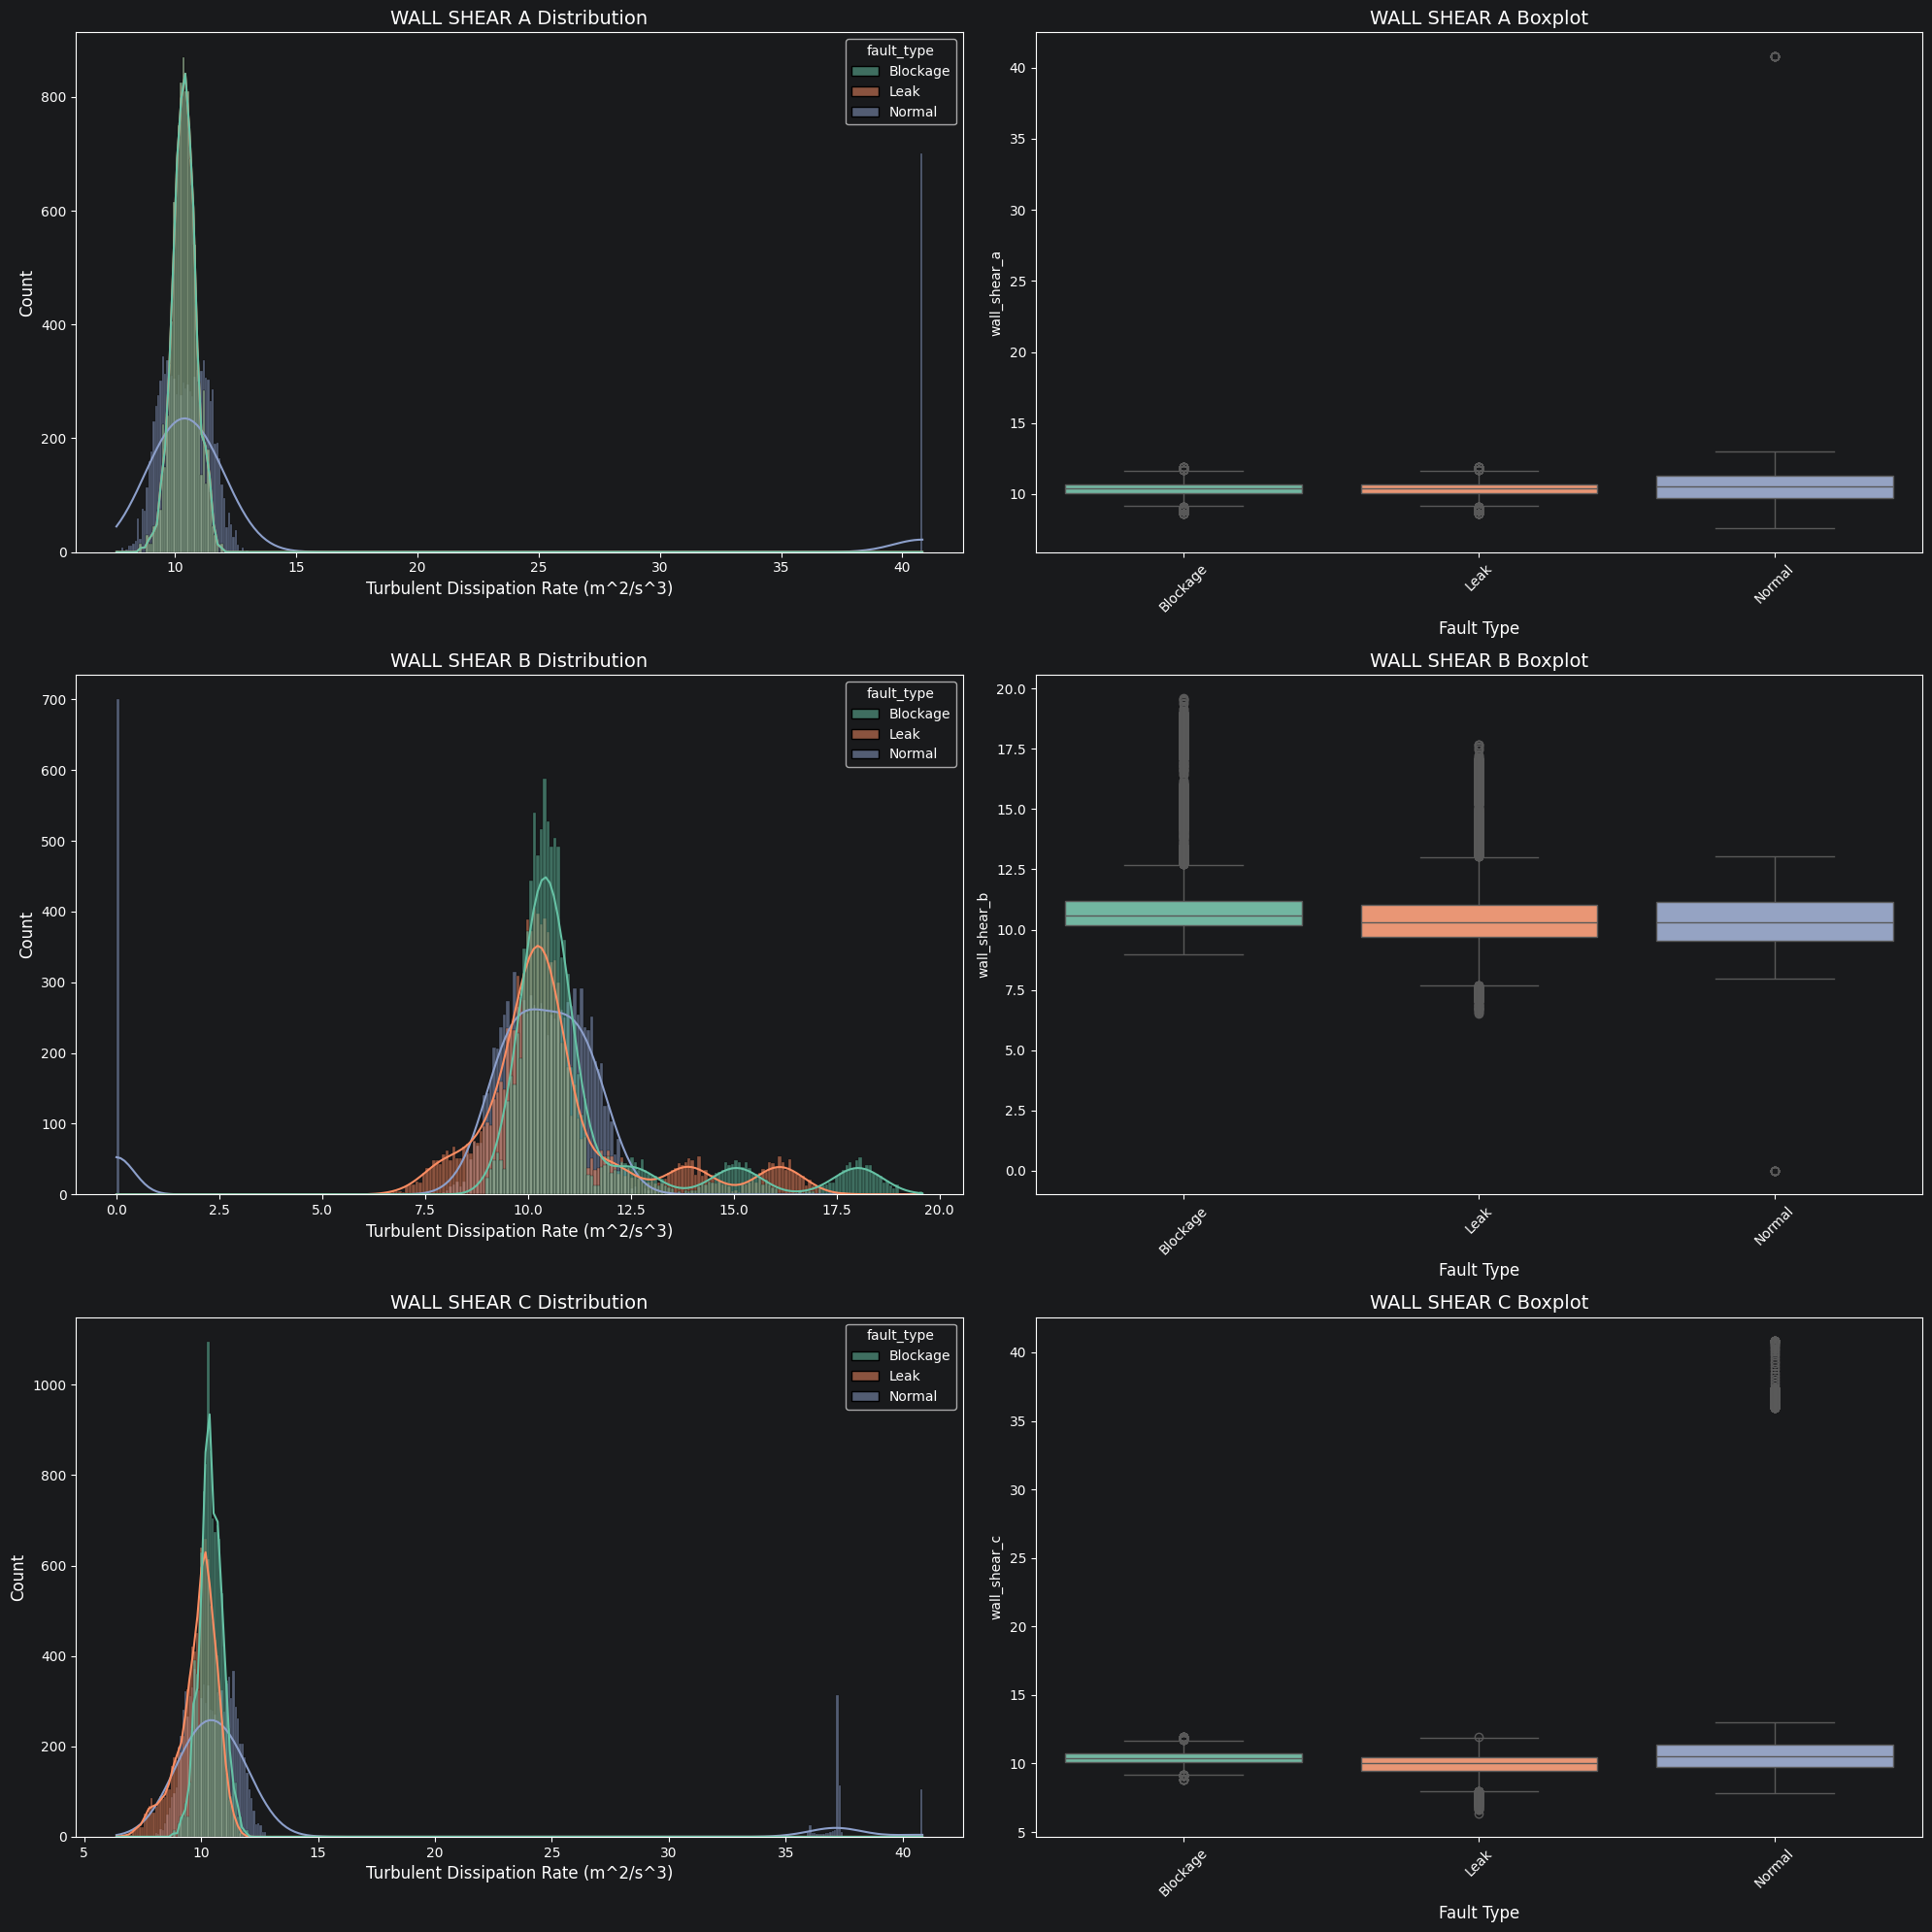

In [105]:
#  Wall shear distribution
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
for i, node in enumerate(["wall_shear_a", "wall_shear_b", "wall_shear_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Wall Shear Distribution Analysis and Recommendations

### Node A
All three classes form an almost identical sharp peak around 10 Pa, with Blockage and Leak overlapping completely. Normal shows a single extreme outlier near 40 Pa in the boxplot. This reflects a real CFD node at the pipe wall where shear is naturally high. There is no meaningful class separation at this node.

---

### Node B
This is the most informative wall shear plot. Normal displays a broad distribution shifted to the left, extending down to values near 0 Pa. Blockage and Leak share a tighter peak around 10–11 Pa, with right tails reaching approximately 18–19 Pa.

The Normal distribution reaching 0.0 is a known data artifact. In real CFD data, pipe center nodes have zero wall shear. The boxplot shows Normal has a lower minimum than both fault classes. This creates the only visible separation signal, but it is driven by the artifact rather than true physical differences.

---

### Node C
Blockage and Leak again overlap completely in a sharp peak around 10 Pa. Normal shows a wider spread with an extreme outlier near 40 Pa, similar to Node A. There is no usable separation signal at this node.

---

## Physical Interpretation

The patterns are only partially consistent with physical expectations. Wall shear should increase near fault locations due to disturbed flow and higher local velocity gradients. The right-tail behavior at Node B for fault classes aligns with this expectation.

However, the observed separation between Normal and fault classes at Node B is largely influenced by the synthetic data generation process rather than true physical variation. This limits the reliability of wall shear as a discriminative feature.

---

## Recommendations for Feature Engineering and Modeling

Wall shear is a weak standalone discriminator across all nodes. The limited separation observed at Node B is partly due to a known artifact in the dataset. The synthetic fault data imposes a minimum wall shear floor above 8 Pa, while real CFD Normal data correctly includes values down to 0 Pa at pipe center nodes.

This imbalance means models trained on raw wall shear may learn to exploit this artifact instead of capturing genuine physical relationships.

A better approach is to engineer a normalized feature such as the shear-velocity ratio:

- `wall_shear / velocity_magnitude` at each node

This transformation removes magnitude bias and retains the physically meaningful relationship between surface friction and flow speed.

Raw wall shear features should be retained initially but carefully evaluated during feature importance analysis. If the model assigns high importance to wall shear, it is important to verify whether this importance persists after correcting or accounting for the artifact floor.

### Tailings VOF Distributions Per Class


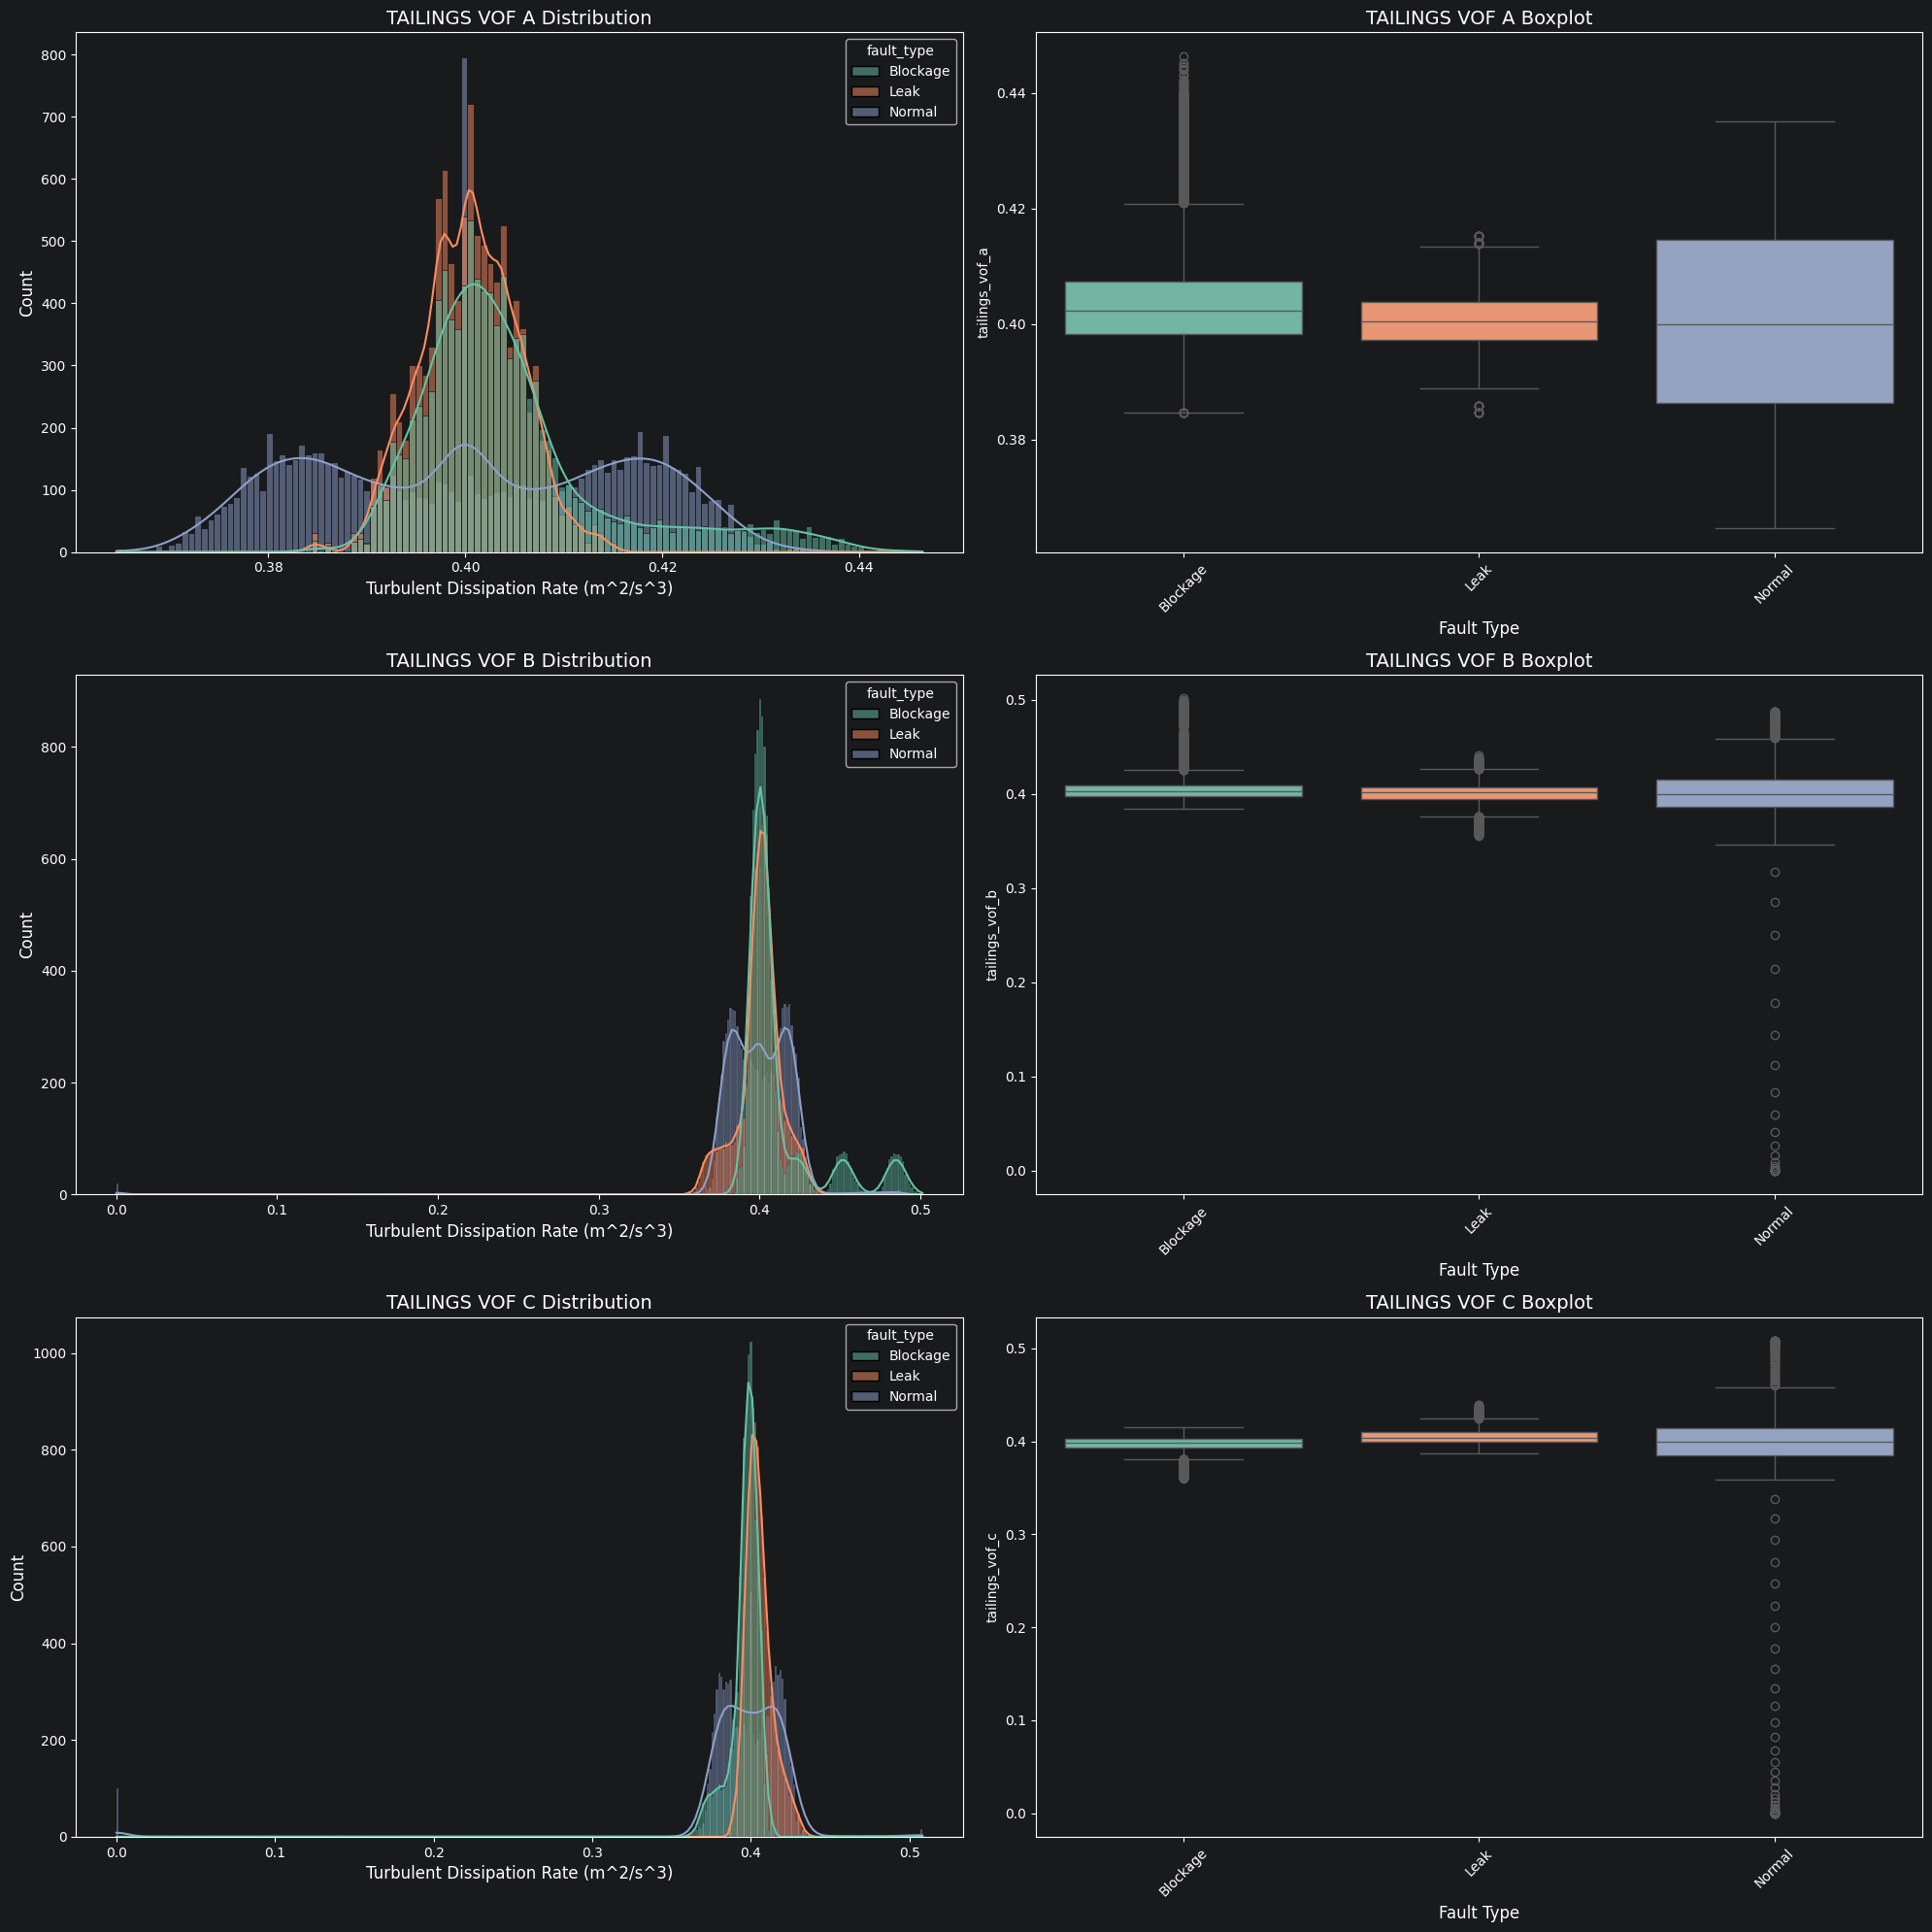

In [106]:
# Tailings Volume of Fluid distribution
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
for i, node in enumerate(["tailings_vof_a", "tailings_vof_b", "tailings_vof_c"]):
    sns.histplot(data=df, x=node, hue="fault_type", ax=axes[i][0], kde=True, palette='Set2')
    axes[i][0].set_title(f"{node.replace('_', ' ').upper()} Distribution", fontsize=14)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][0].set_ylabel("Count", fontsize=12)

    sns.boxplot(data=df, x="fault_type", y=node, ax=axes[i][1], palette='Set2')
    axes[i][1].set_title(f"{node.replace('_', ' ').upper()} Boxplot", fontsize=14)
    axes[i][1].set_xlabel("Fault Type", fontsize=12)
    axes[i][0].set_xlabel("Turbulent Dissipation Rate (m^2/s^3)", fontsize=12)
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Tailings VOF Distribution Analysis and Recommendations

### Node A
Blockage shows a clear bimodal distribution with peaks around 0.38 and 0.405, positioned slightly to the right of Normal and Leak. Leak and Normal overlap heavily in the main peak, but Normal has a noticeably wider spread extending in both directions. The boxplot confirms that Blockage has a tighter interquartile range and is shifted slightly higher. This aligns with the expected physical behavior where solids accumulate upstream of a blockage. Node A is the only location where VOF provides meaningful class separation.

---

### Node B
All three classes converge into a single sharp peak around 0.40 in the KDE, suggesting strong overlap. However, the boxplot reveals a different pattern. Normal contains a large number of extreme outliers extending down to near 0.0. These represent real CFD nodes where tailings concentration drops to almost zero, indicating clear fluid regions in the simulation.

Blockage and Leak do not exhibit these outliers, with their values remaining above approximately 0.35. This creates an apparent separation, but it is driven by distribution tails rather than the central tendency.

---

### Node C
Node C mirrors the behavior observed at Node B. The KDE shows near-complete overlap across all classes, but the boxplot again highlights extreme low-value outliers in the Normal class. Fault classes remain tightly bounded above roughly 0.36.

---

## Physical Interpretation

The patterns observed are physically consistent. The bimodal distribution at Node A for Blockage reflects upstream solid accumulation, which is expected in obstructed flow conditions.

The near-zero outliers in the Normal class at Nodes B and C are also physically valid. They correspond to regions in the CFD simulation where tailings concentration is minimal or absent. The tighter distributions seen in the fault classes are more reflective of the synthetic data generation process rather than natural variability.

---

## Recommendations for Feature Engineering and Modeling

Tailings VOF at Node A is the only VOF feature with clear discriminative value, primarily due to the bimodal structure associated with Blockage.

VOF at Nodes B and C shows heavy overlap in the main distribution and is unlikely to contribute significantly as standalone features.

The presence of extreme low-value outliers in the Normal class at Nodes B and C introduces strong skewness. This can negatively affect standard scaling, as these values will shift the mean downward and inflate the standard deviation. As a result, normalization may become less effective for the fault classes, which do not contain similar low values.

To address this:

- Use robust scaling based on median and interquartile range instead of mean and standard deviation
- Alternatively, apply a lower-bound clipping strategy before scaling

For feature engineering, a spatial gradient feature is recommended:

- `tailings_vof_a - tailings_vof_c`

This captures upstream accumulation effects associated with Blockage and is less sensitive to extreme outliers at individual nodes.

Raw VOF features should be retained initially but evaluated alongside engineered features to determine their final contribution to model performance.

###  Derived Feature Distributions Per Class


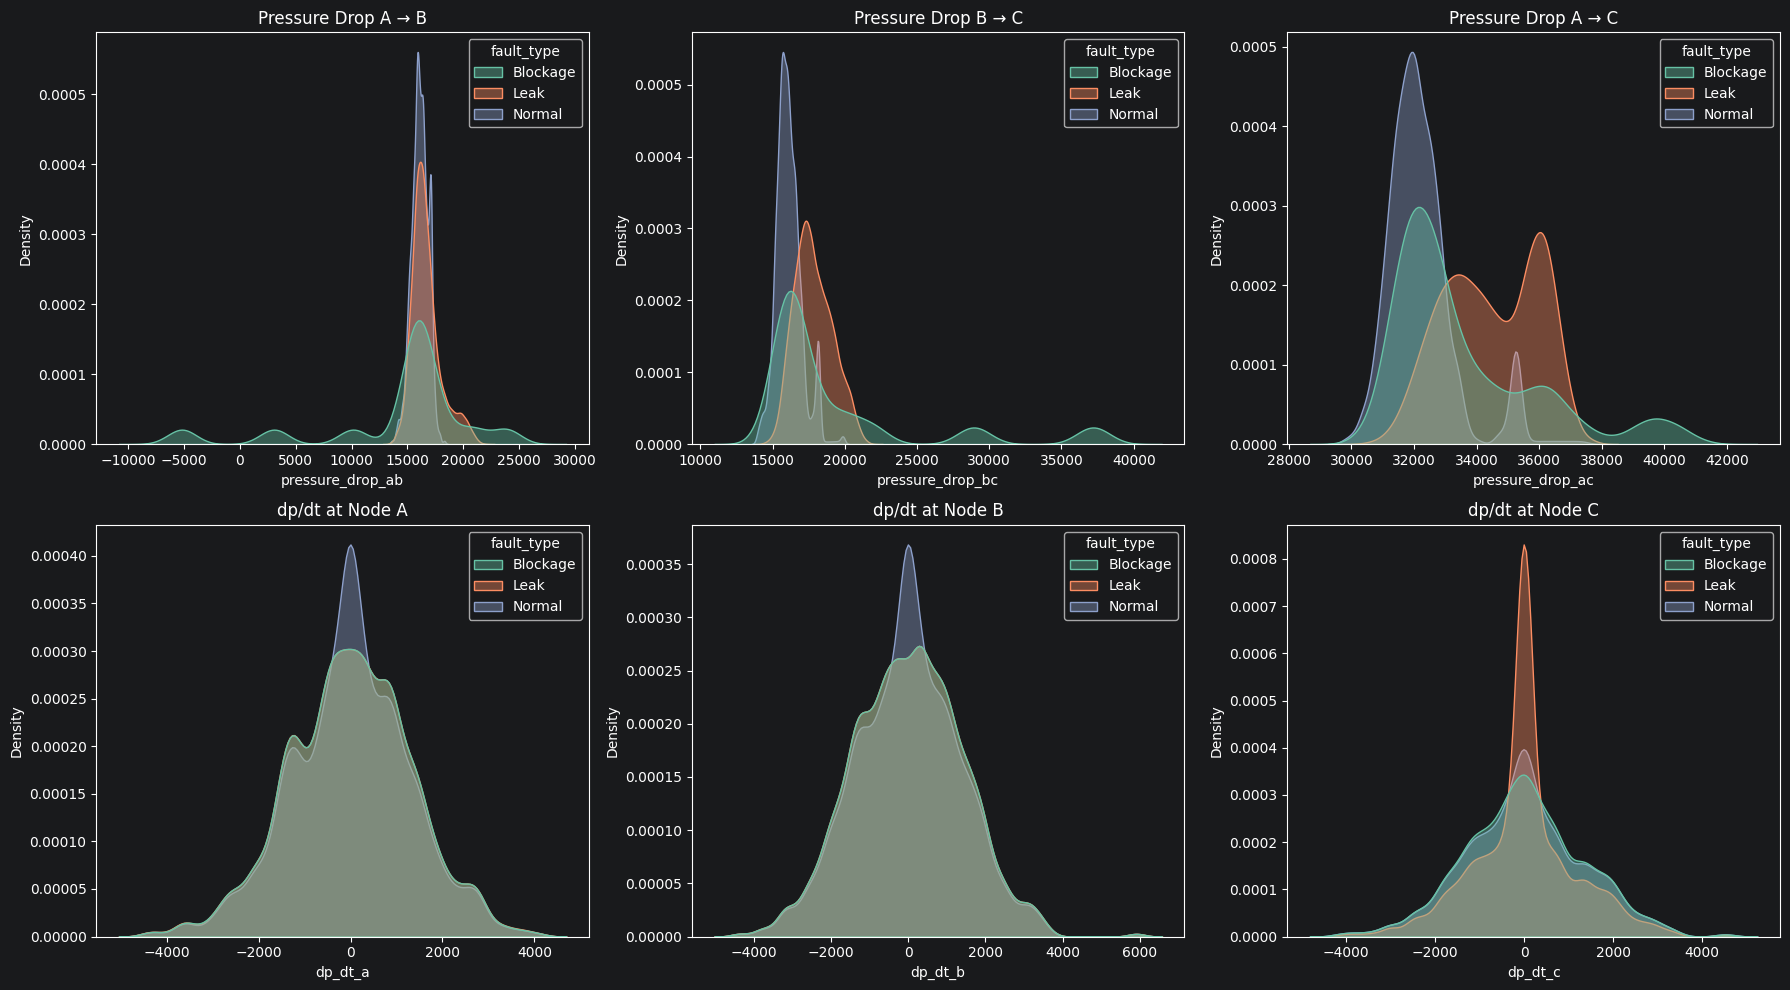

In [107]:
# Define features and titles
features = [
    "pressure_drop_ab",
    "pressure_drop_bc",
    "pressure_drop_ac",
    "dp_dt_a",
    "dp_dt_b",
    "dp_dt_c"
]

titles = [
    "Pressure Drop A → B",
    "Pressure Drop B → C",
    "Pressure Drop A → C",
    "dp/dt at Node A",
    "dp/dt at Node B",
    "dp/dt at Node C"
]

# Create figure (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot KDEs
for i, (feature, title) in enumerate(zip(features, titles)):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(title)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

## Pressure Drop and dp/dt Analysis with Recommendations

### Pressure Drop A to B
Leak and Normal form nearly identical tight distributions centered around 15,000 to 16,000 Pa. Blockage, however, shows a much broader distribution that is shifted left and extends into negative values down to approximately -10,000 Pa.

A negative pressure drop indicates that pressure at Node B exceeds pressure at Node A. This reflects a back pressure effect caused by blockage, where the obstruction elevates pressure at the midpoint above upstream levels. This creates strong separation for Blockage, while Leak and Normal remain indistinguishable.

---

### Pressure Drop B to C
This is the most informative feature observed in the entire analysis. Blockage is clearly separated with a right-shifted distribution peaking around 19,000 to 25,000 Pa and extending up to 40,000 Pa.

Leak and Normal overlap tightly around 16,000 Pa with minimal spread. The separation arises because blockage simultaneously increases pressure at Node B and reduces pressure at Node C, producing an unusually large pressure drop between these points.

This makes `pressure_drop_bc` the strongest single feature for identifying Blockage.

---

### Pressure Drop A to C
Blockage shows a broader distribution shifted slightly to the right, centered around 33,000 to 36,000 Pa. Leak and Normal again overlap in a tight peak around 32,000 Pa.

This feature provides moderate separation for Blockage but is weaker compared to the B to C drop. Leak and Normal remain indistinguishable.

---

### dp/dt at Nodes A, B, and C
All three classes show complete overlap across all nodes. The distributions are centered around zero with symmetric spread and no visible separation.

This confirms that dp/dt carries no discriminative information in this dataset.

---

## Recommendations for Feature Selection and Modeling

The pressure drop features establish a clear hierarchy of importance:

- `pressure_drop_bc` is the most informative feature for Blockage detection. It captures the combined effect of elevated midpoint pressure and reduced downstream pressure, producing a uniquely large drop.

- `pressure_drop_ab` adds complementary value by capturing cases where back pressure reverses the expected gradient, resulting in negative drops.

- `pressure_drop_ac` is largely redundant because it is effectively the sum of the other two and does not provide independent information.

For dp/dt features:

- All dp/dt columns should be removed from the feature set.
- The identical distributions across all classes indicate no useful signal for classification.
- This is consistent with the data generation process, where pressure values are effectively stationary at each timestep.

Temporal behavior will instead be captured by the LSTM model through its sliding window of sequential inputs, making manually engineered rate-of-change features unnecessary and potentially harmful due to added noise.

---

## Summary

Pressure drop features, particularly `pressure_drop_bc`, provide the strongest signals for distinguishing Blockage. In contrast, dp/dt features offer no meaningful contribution and should be excluded to simplify the model and improve learning efficiency.

### Node Comparison within each class

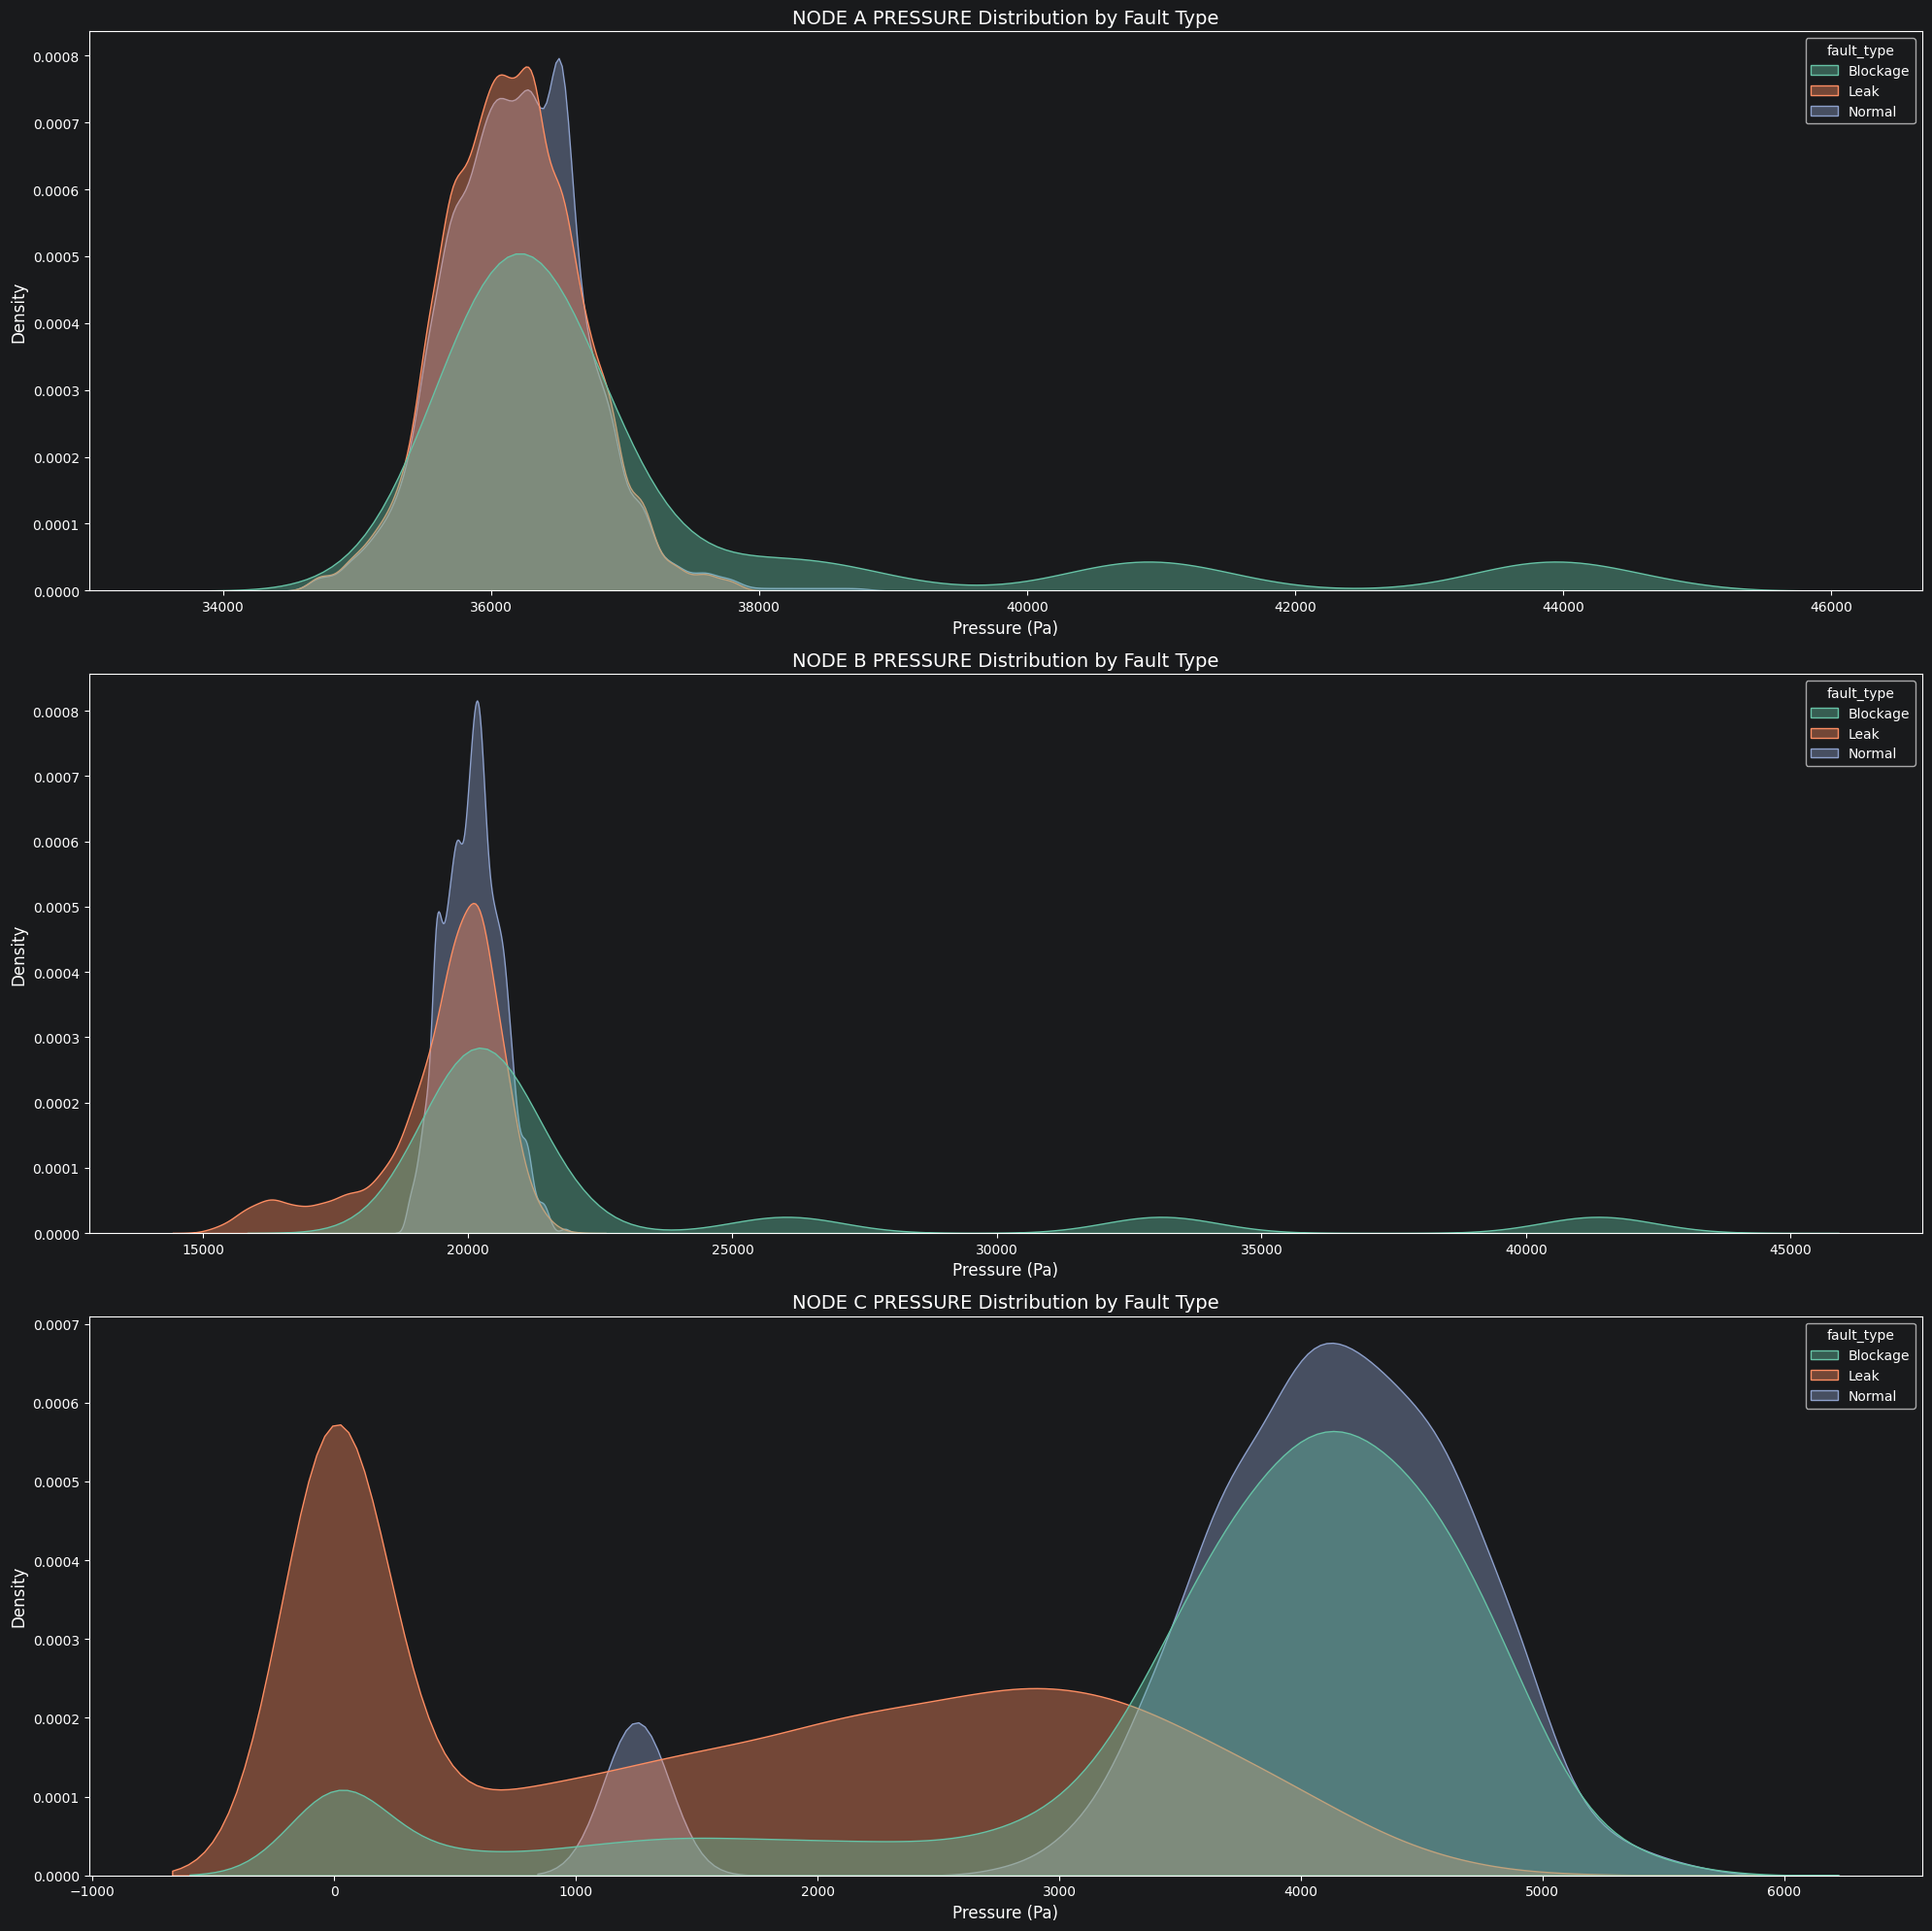

In [108]:
fig, axes = plt.subplots(3,1, figsize=(20, 20))

for i, node in enumerate(["node_a_pressure", "node_b_pressure", "node_c_pressure"]):
    sns.kdeplot(
        data=df,
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(f"{node.replace('_', ' ').upper()} Distribution by Fault Type", fontsize=14)
    axes[i].set_xlabel("Pressure (Pa)", fontsize=12)
    axes[i].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

### Three Class Pressure Overview (Normal vs Leak vs Blockage)
- At Node A, Leak and Normal appear as a single merged peak around 36,000 Pa. In contrast, Blockage spreads widely toward higher pressures, forming secondary humps up to 45,000 Pa, which represent different severity levels.

- At Node B, the same pattern is observed, but the Blockage distribution is more clearly structured. It shows distinct secondary humps at approximately 25,000, 30,000, and 35,000 Pa, each corresponding to a specific severity cluster.

- Node C provides the clearest distinction. Leak and Normal again overlap, peaking around 4,000 Pa. However, Blockage forms a strong secondary cluster between 0 and 1,000 Pa, indicating severe downstream starvation.

Across all three nodes, the multimodal nature of Blockage reflects the 15 distinct blockage scenarios. This behavior is physically meaningful and not due to noise.

###  Leak vs Blockage Discrimination

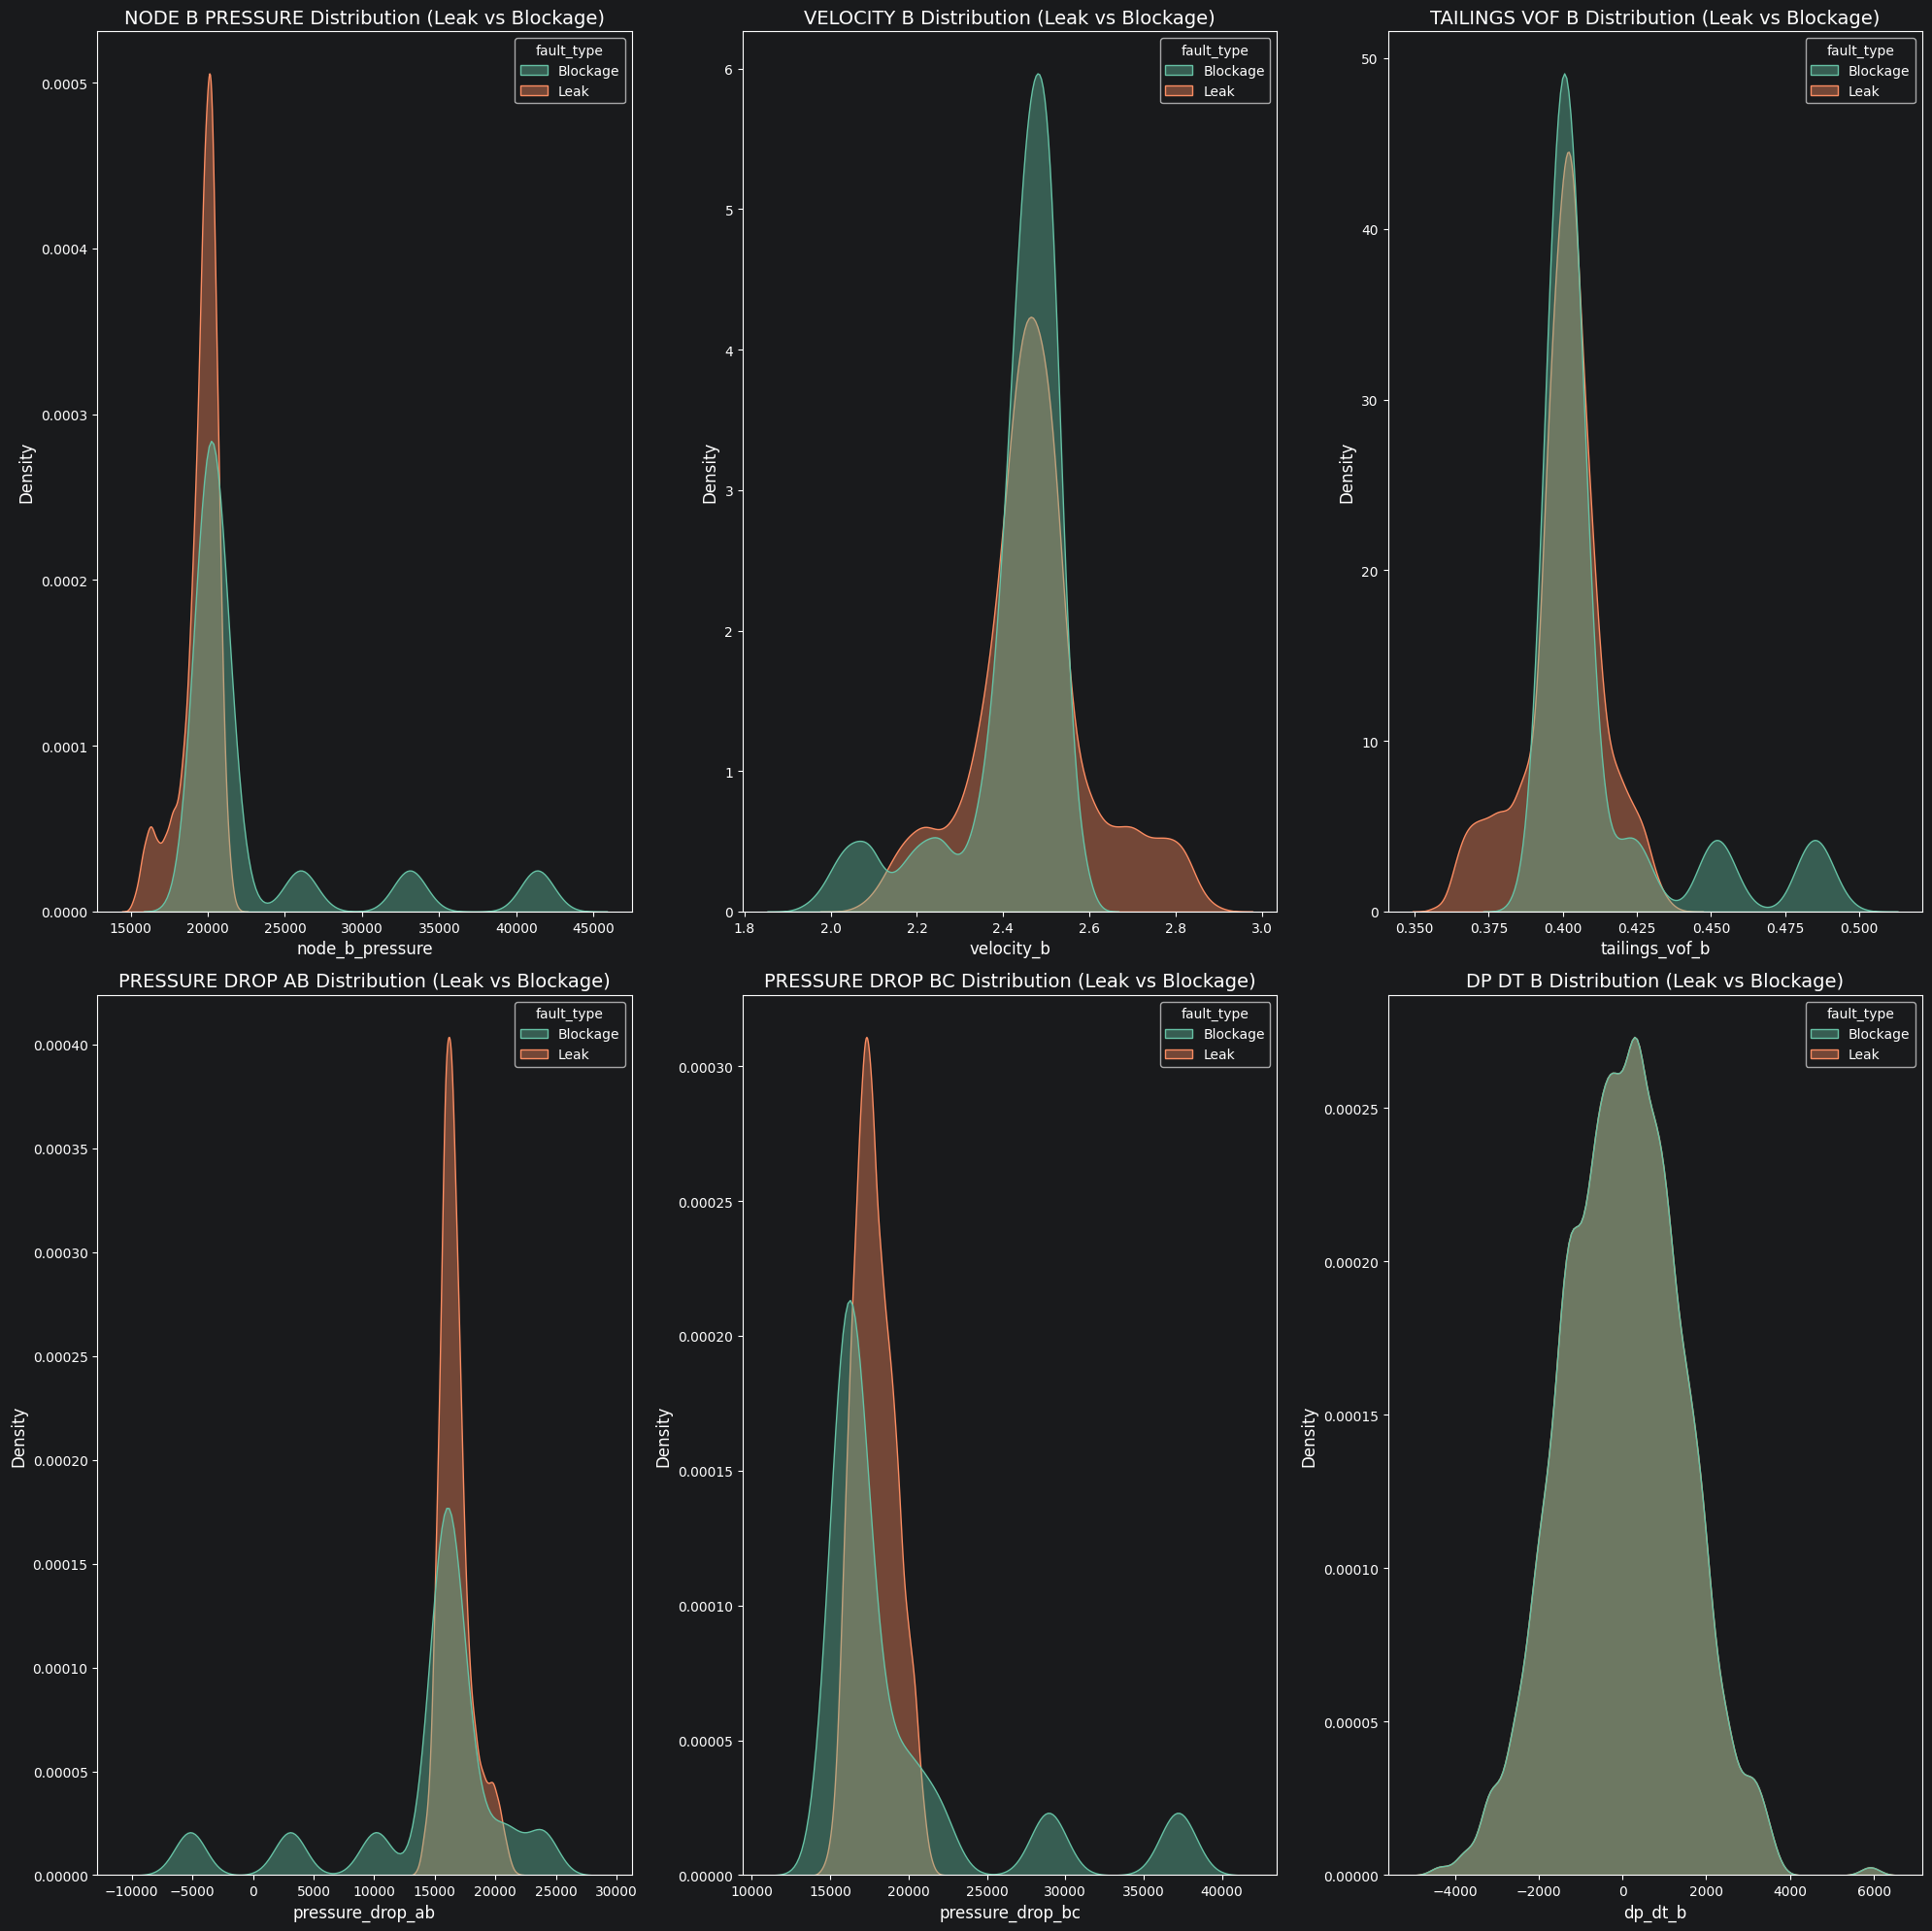

In [109]:
fig, axes = plt.subplots(2, 3, figsize=(20, 20))

for i, node in enumerate(["node_b_pressure", "velocity_b", "tailings_vof_b", "pressure_drop_ab", "pressure_drop_bc", "dp_dt_b"]):
    sns.kdeplot(
        data=df[df["fault_type"].isin(["Leak", "Blockage"])],
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i//3][i%3],
        palette="Set2"
    )

    axes[i//3][i%3].set_title(f"{node.replace('_', ' ').upper()} Distribution (Leak vs Blockage)", fontsize=14)
    axes[i//3][i%3].set_xlabel(node, fontsize=12)
    axes[i//3][i%3].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

### Node B Features: Leak vs Blockage
- At Node B, pressure shows complete overlap between Leak and Blockage, making them indistinguishable using this feature alone.

- Velocity B reveals a clearer pattern. Blockage has a broader, left-shifted distribution with a secondary hump around 2.1–2.3 m/s, indicating flow restriction. Leak, on the other hand, is more tightly distributed around 2.5 m/s.

- Tailings VOF B shows Blockage extending to higher values, with a right tail reaching 0.50, while Leak remains below 0.42. This reflects upstream solid accumulation in Blockage cases.

- Pressure drop AB and BC both show Blockage spreading widely in both directions, while Leak remains tightly clustered. This confirms distortion in pressure gradients under Blockage conditions.

The dp_dt B feature is identical for both classes and does not provide any separation. It carries no discriminative value and should be removed.

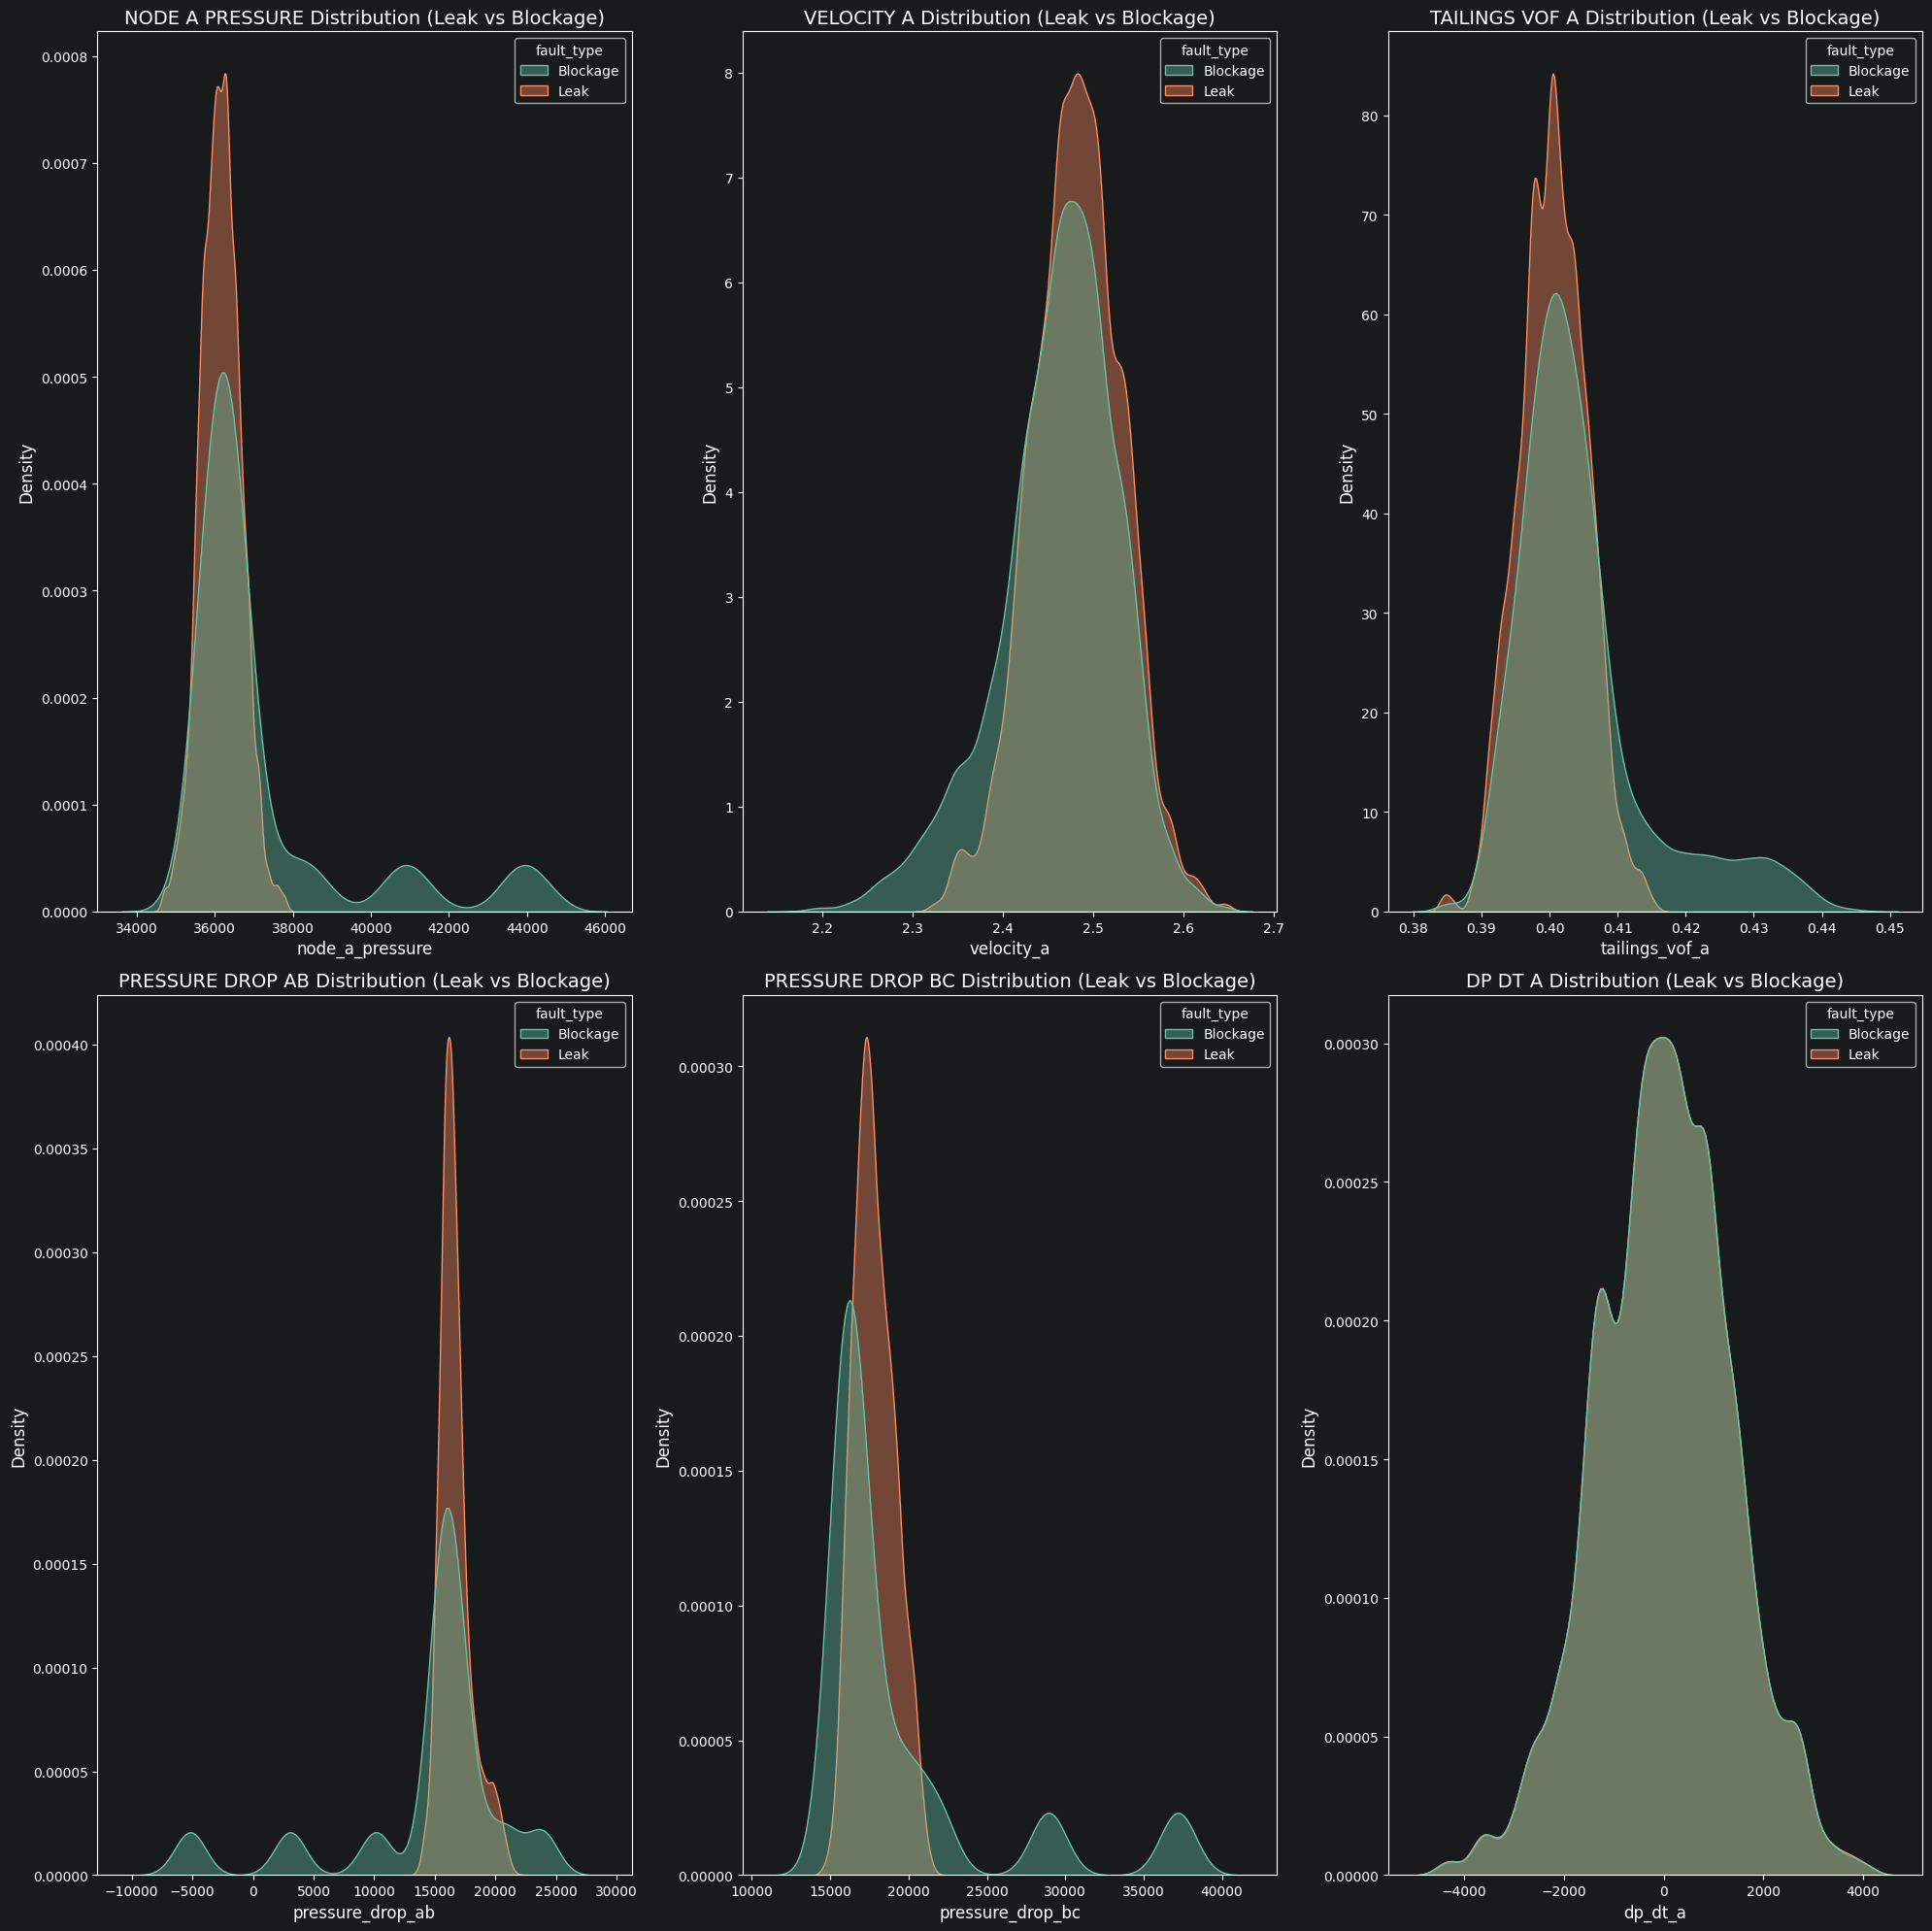

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(20, 20))

for i, node in enumerate(["node_a_pressure", "velocity_a", "tailings_vof_a", "pressure_drop_ab", "pressure_drop_bc", "dp_dt_a"]):
    sns.kdeplot(
        data=df[df["fault_type"].isin(["Leak", "Blockage"])],
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i//3][i%3],
        palette="Set2"
    )

    axes[i//3][i%3].set_title(f"{node.replace('_', ' ').upper()} Distribution (Leak vs Blockage)", fontsize=14)
    axes[i//3][i%3].set_xlabel(node, fontsize=12)
    axes[i//3][i%3].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

### Node A Features: Leak vs Blockage
- At Node A, pressure again shows strong overlap between Leak and Blockage, with only a slight right tail from Blockage providing minimal separation.

- Velocity A is more compact than at Node B, but Blockage still shows a slightly wider spread with a left shoulder around 2.3 m/s.

- Tailings VOF A indicates a subtle shift, with Blockage slightly right-shifted and more spread out compared to Leak. This suggests mild upstream solid accumulation.

- Pressure drop AB is a strong indicator. Blockage extends significantly into negative values, showing back pressure effects and reversal of the gradient, while Leak remains tightly clustered.

- Pressure drop BC again shows Blockage shifted to the right, reinforcing its separability.

- The dp_dt A feature is identical for both classes and is not useful.

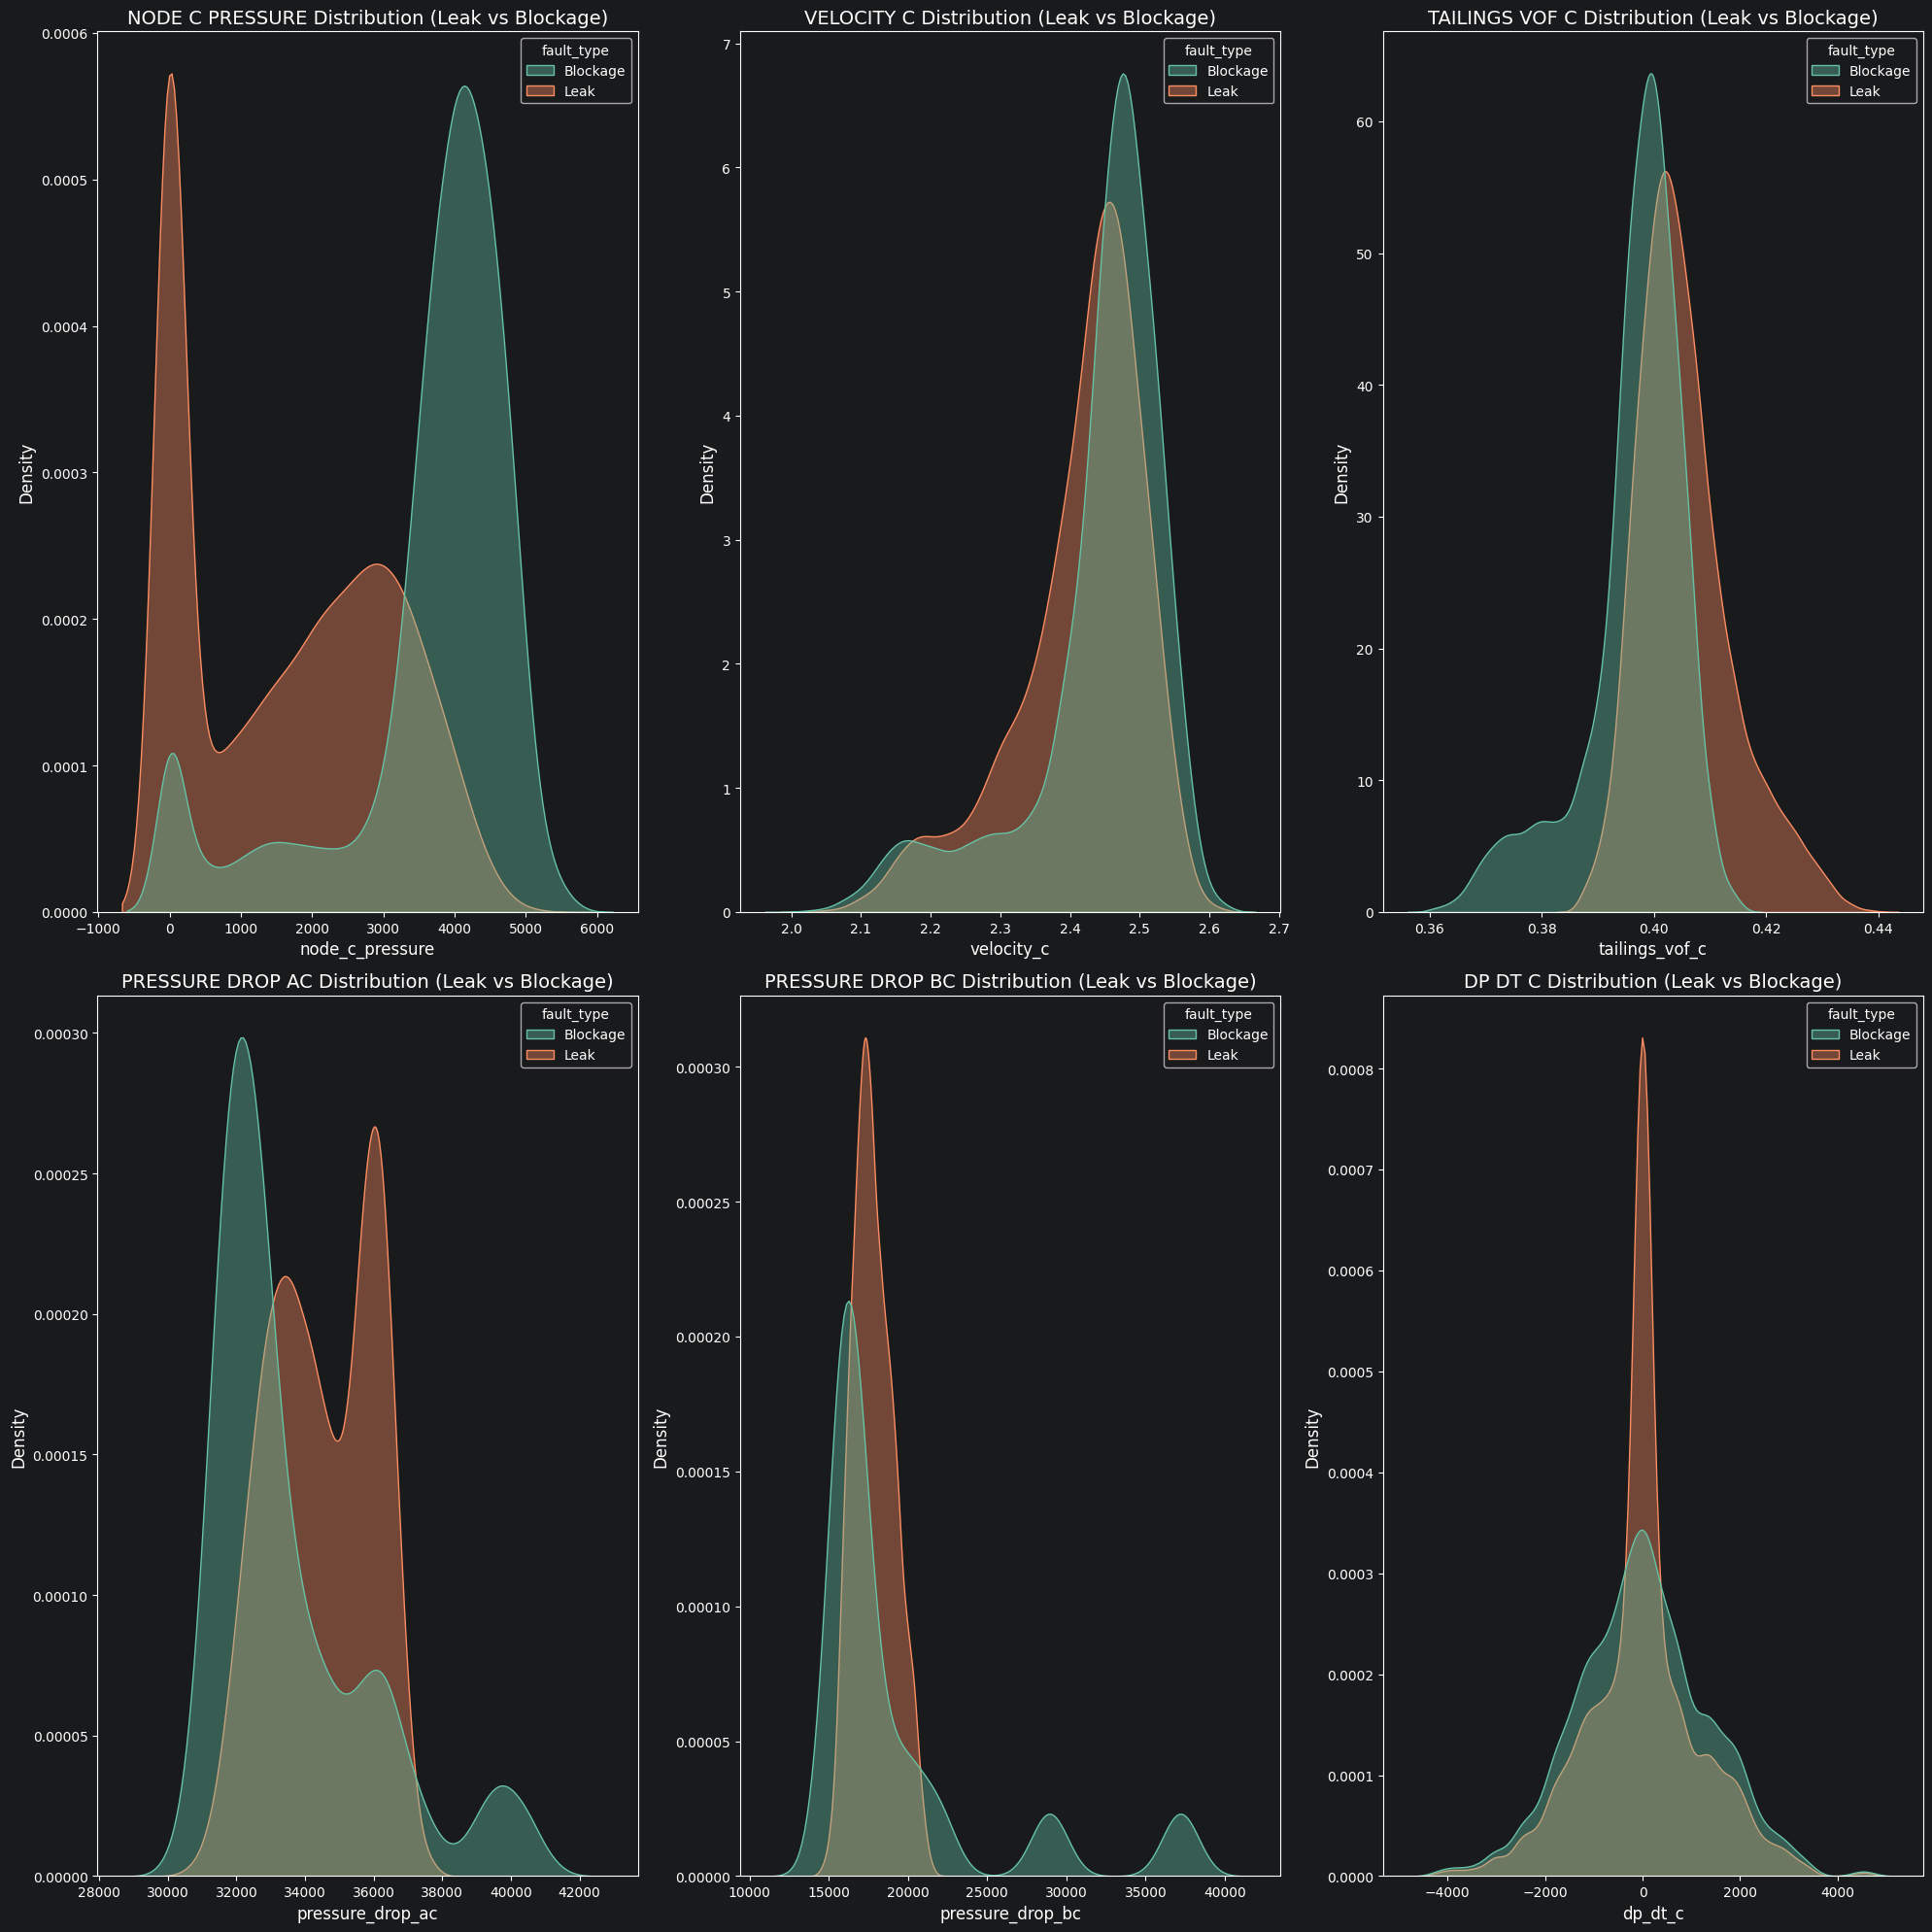

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(20, 20))

for i, node in enumerate(["node_c_pressure", "velocity_c", "tailings_vof_c", "pressure_drop_ac", "pressure_drop_bc", "dp_dt_c"]):
    sns.kdeplot(
        data=df[df["fault_type"].isin(["Leak", "Blockage"])],
        x=node,
        hue="fault_type",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i//3][i%3],
        palette="Set2"
    )

    axes[i//3][i%3].set_title(f"{node.replace('_', ' ').upper()} Distribution (Leak vs Blockage)", fontsize=14)
    axes[i//3][i%3].set_xlabel(node, fontsize=12)
    axes[i//3][i%3].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()

### Node C Features: Leak vs Blockage
- Node C provides the clearest separation between the two classes. Blockage forms a strong cluster between 0 and 2,000 Pa, while Leak peaks between 4,000 and 5,000 Pa. This reflects downstream starvation and is the strongest signal at this node.

- Velocity C follows a similar trend. Blockage shows a left-shifted secondary hump around 2.0–2.2 m/s, while Leak remains tightly centered around 2.5 m/s.

- Tailings VOF C shows almost identical distributions for both classes, confirming that this feature does not contribute to separation.

- Pressure drop AC shows moderate separation, with Blockage shifted lower (30,000–33,000 Pa) and Leak higher (32,000–36,000 Pa).

- Pressure drop BC provides clear separation, with Blockage consistently right-shifted.

The dp_dt C feature is again identical for both classes and should be excluded.

### Full Correlation Heatmap

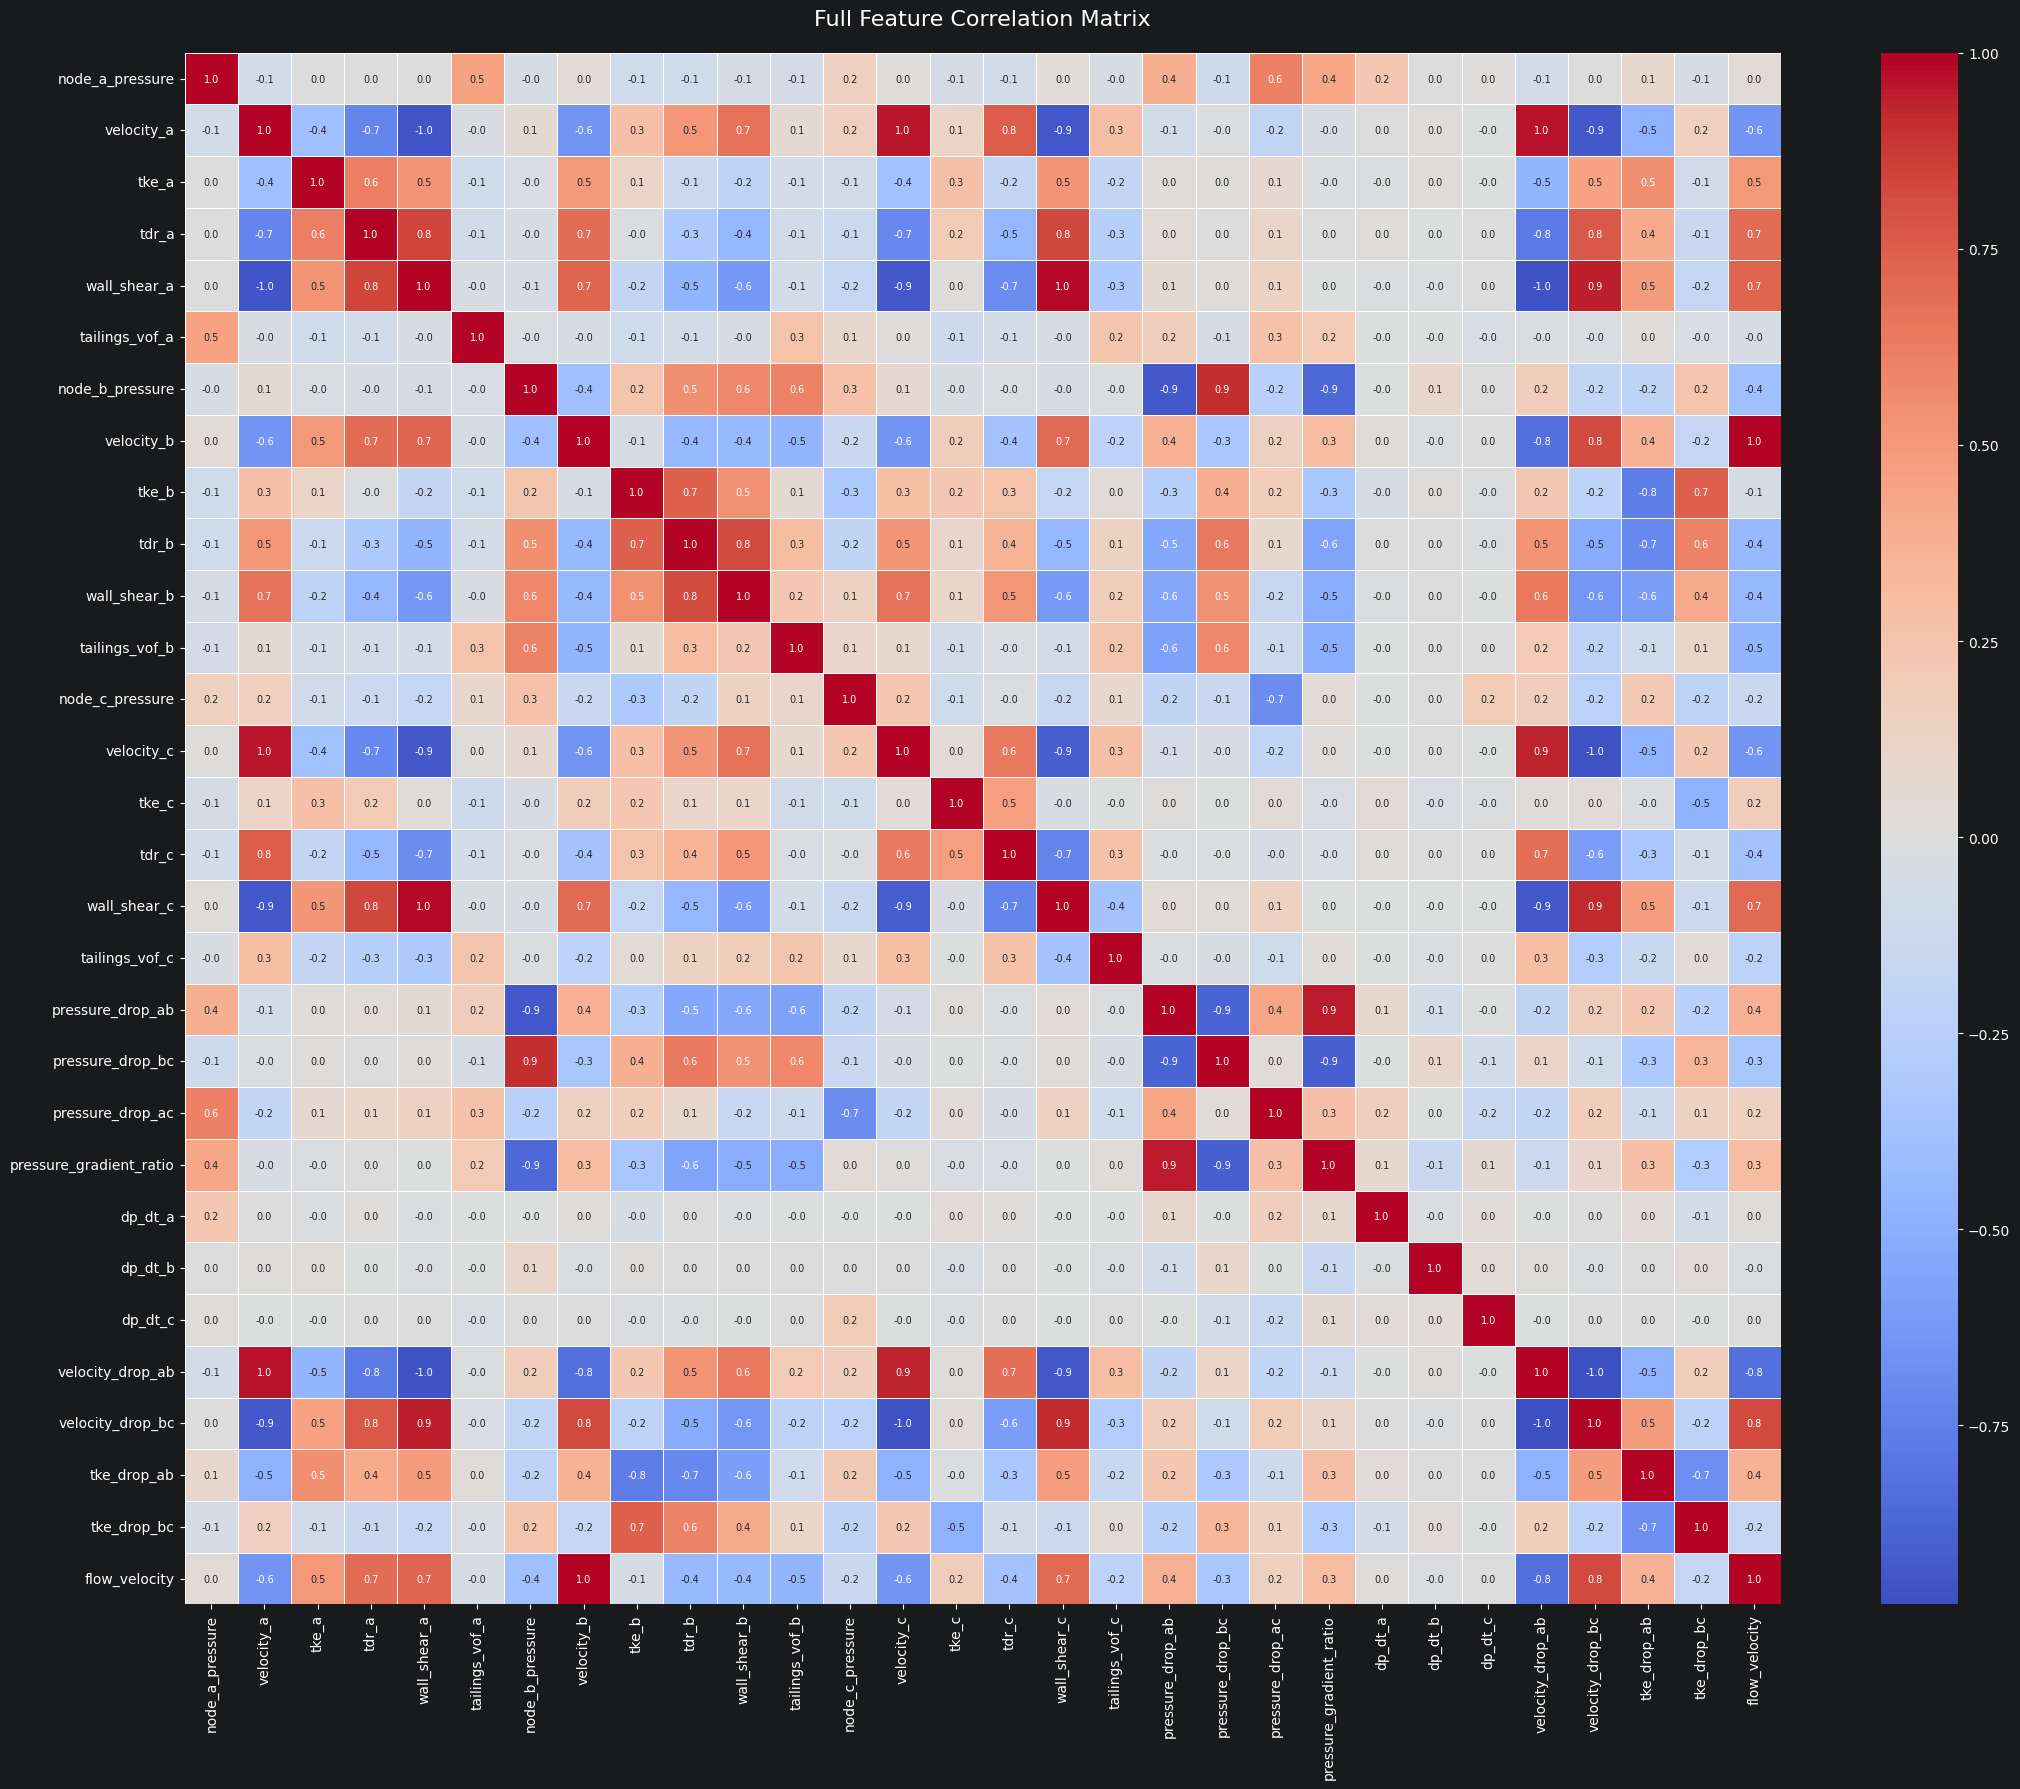


PAIRS WITH ABS(CORRELATION) > 0.95 — DROP CANDIDATES
Feature 1                 Feature 2                  Correlation
-----------------------------------------------------------------
velocity_a                wall_shear_a                   -0.9532
velocity_a                velocity_c                      0.9593
velocity_a                velocity_drop_ab                0.9629
wall_shear_a              wall_shear_c                    0.9795
wall_shear_a              velocity_drop_ab               -0.9557
velocity_b                flow_velocity                   1.0000
velocity_c                velocity_drop_bc               -0.9633
velocity_drop_ab          velocity_drop_bc               -0.9781

PAIRS WITH ABS(CORRELATION) > 0.85 — WATCH LIST
Feature 1                 Feature 2                  Correlation
-----------------------------------------------------------------
velocity_a                wall_shear_c                   -0.9430
velocity_a                velocity_drop_bc        

In [112]:
drop_cols = ['timestep', 'label', 'effect_factor', 'fault_type', 'scenario_id']
numeric_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Full Feature Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# High correlation pairs
print("\n" + "="*60)
print("PAIRS WITH ABS(CORRELATION) > 0.95 — DROP CANDIDATES")
print("="*60)
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Correlation':>12}")
print("-"*65)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.95:
            f1 = corr_matrix.columns[i]
            f2 = corr_matrix.columns[j]
            high_corr_pairs.append((f1, f2, val))
            print(f"{f1:<25} {f2:<25} {val:>12.4f}")

print("\n" + "="*60)
print("PAIRS WITH ABS(CORRELATION) > 0.85 — WATCH LIST")
print("="*60)
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Correlation':>12}")
print("-"*65)

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if 0.85 < abs(val) <= 0.95:
            f1 = corr_matrix.columns[i]
            f2 = corr_matrix.columns[j]
            print(f"{f1:<25} {f2:<25} {val:>12.4f}")

### Confirmed drops - absolute correlation > 0.95

flow_velocity is an exact duplicate of velocity_b (1.0000). Drop it immediately. It adds zero new information and will distort feature importance.

wall_shear_c is highly redundant with wall_shear_a (0.9858). Both are capturing the same wall friction behaviour. Keep wall_shear_a since it is upstream and more useful for early fault detection. Drop wall_shear_c.

velocity_c is redundant with velocity_a (0.9697). Flow is consistent enough along the pipe that both are tracking the same signal. Keep velocity_b because the midpoint is more sensitive to both leak and blockage behaviour. Drop velocity_c.

pressure_drop_bc is strongly correlated with node_b_pressure (0.9677). This is expected since pressure_drop_bc = node_b_pressure minus node_c_pressure. If node_b_pressure drives variation, the drop follows. For now, keep pressure_drop_bc because it is more physically meaningful as a fault feature than raw pressure. Do not drop either yet. Confirm later with feature importance.

wall_shear_a vs velocity_a (-0.9532) needs caution. These are different physical variables even though they are strongly linked. Higher velocity naturally increases wall shear in pipe flow. Do not drop either based on correlation alone. Let the model decide during importance scoring.

---

### Watch list 0.85 to 0.95

tdr_b and wall_shear_b (0.9245) are strongly correlated, but this is expected. Turbulence dissipation and wall shear both respond to disturbances near faults. Keep both for now and monitor during feature selection.

pressure_drop_ab and pressure_drop_bc (-0.9089) are strongly anti-correlated. This is not redundancy. When blockage elevates pressure at Node B, AB drop reduces while BC drop increases. They carry complementary information about fault position, so keep both. The anti-correlation is the signal.

---

### Recommendations for your report

The correlation analysis identifies five feature pairs above the 0.95 redundancy threshold. The clearest removal is flow_velocity, which is mathematically identical to velocity_b and contributes no independent information.

wall_shear_c and velocity_c are also strong candidates for removal due to their high correlation with upstream measurements and the relatively stable flow conditions along the pipe.

The negative correlation between pressure_drop_ab and pressure_drop_bc (about -0.91) should not be treated as redundancy. It reflects the physical relationship between upstream pressure compression and downstream pressure amplification under blockage conditions. Both features should be retained.

All remaining watch list features should not be removed based on correlation alone. Final decisions should be made after feature engineering using model based importance scoring, since engineered features can change the dependency structure of the feature space.

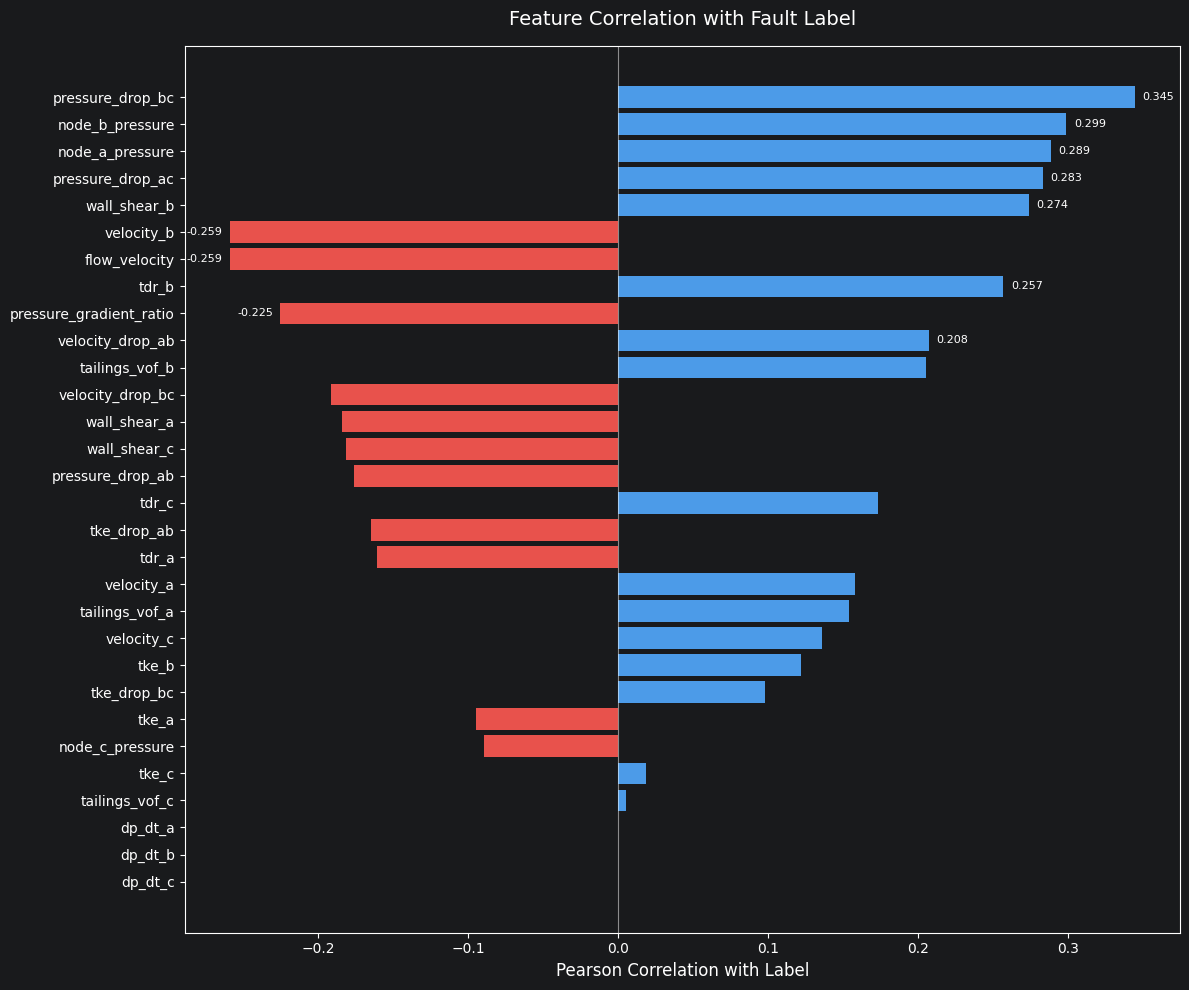


FEATURE CORRELATION WITH LABEL — RANKED
Rank   Feature                       Correlation      Abs
----------------------------------------------------------
1      pressure_drop_bc                   0.3448   0.3448
2      node_b_pressure                    0.2992   0.2992
3      node_a_pressure                    0.2887   0.2887
4      pressure_drop_ac                   0.2834   0.2834
5      wall_shear_b                       0.2741   0.2741
6      velocity_b                        -0.2587   0.2587
7      flow_velocity                     -0.2587   0.2587
8      tdr_b                              0.2571   0.2571
9      pressure_gradient_ratio           -0.2250   0.2250
10     velocity_drop_ab                   0.2075   0.2075
11     tailings_vof_b                     0.2054   0.2054
12     velocity_drop_bc                  -0.1913   0.1913
13     wall_shear_a                      -0.1840   0.1840
14     wall_shear_c                      -0.1811   0.1811
15     pressure_drop_ab       

In [113]:
# Full correlation with labels
label_corr = numeric_df.copy()
label_corr['label'] = df['label']

corr_with_label = label_corr.corr()['label'].drop('label')
corr_with_label = corr_with_label.sort_values(key=abs, ascending=False)

colors = ['#4C9BE8' if v >= 0 else '#E8524C' for v in corr_with_label]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(corr_with_label.index, corr_with_label.values, color=colors, edgecolor='none')
ax.axvline(x=0, color='white', linewidth=0.8, alpha=0.5)

for i, (val, bar) in enumerate(zip(corr_with_label.values, bars)):
    if i < 10:
        ax.text(
            val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8,
            color='white'
        )

ax.set_xlabel("Pearson Correlation with Label", fontsize=12)
ax.set_title("Feature Correlation with Fault Label", fontsize=14, pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FEATURE CORRELATION WITH LABEL — RANKED")
print("="*60)
print(f"{'Rank':<6} {'Feature':<28} {'Correlation':>12} {'Abs':>8}")
print("-"*58)
for rank, (feat, val) in enumerate(corr_with_label.items(), 1):
    print(f"{rank:<6} {feat:<28} {val:>12.4f} {abs(val):>8.4f}")

### Feature Correlation with Fault Label

pressure_drop_bc and pressure_drop_ac lead at 0.34 and 0.33, followed by node_b_pressure at 0.31 and node_a_pressure at 0.29. These are the strongest raw predictors, and all are pressure based. This confirms that pressure is the dominant fault signal in this dataset.

wall_shear_b and tdr_b both sit around 0.27 to 0.28. This shows that the midpoint sensor is consistently more informative than upstream or downstream across different feature types.

flow_velocity and velocity_b are identical at -0.27, confirming duplication. The negative correlation indicates that higher velocity is associated with Normal or Leak rather than Blockage. This aligns with the physical expectation that blockage restricts flow.

The three dp_dt features sit at approximately 0.00 across all nodes, which are the lowest values in the ranking. This is clear confirmation that they provide no useful signal. Drop all three.


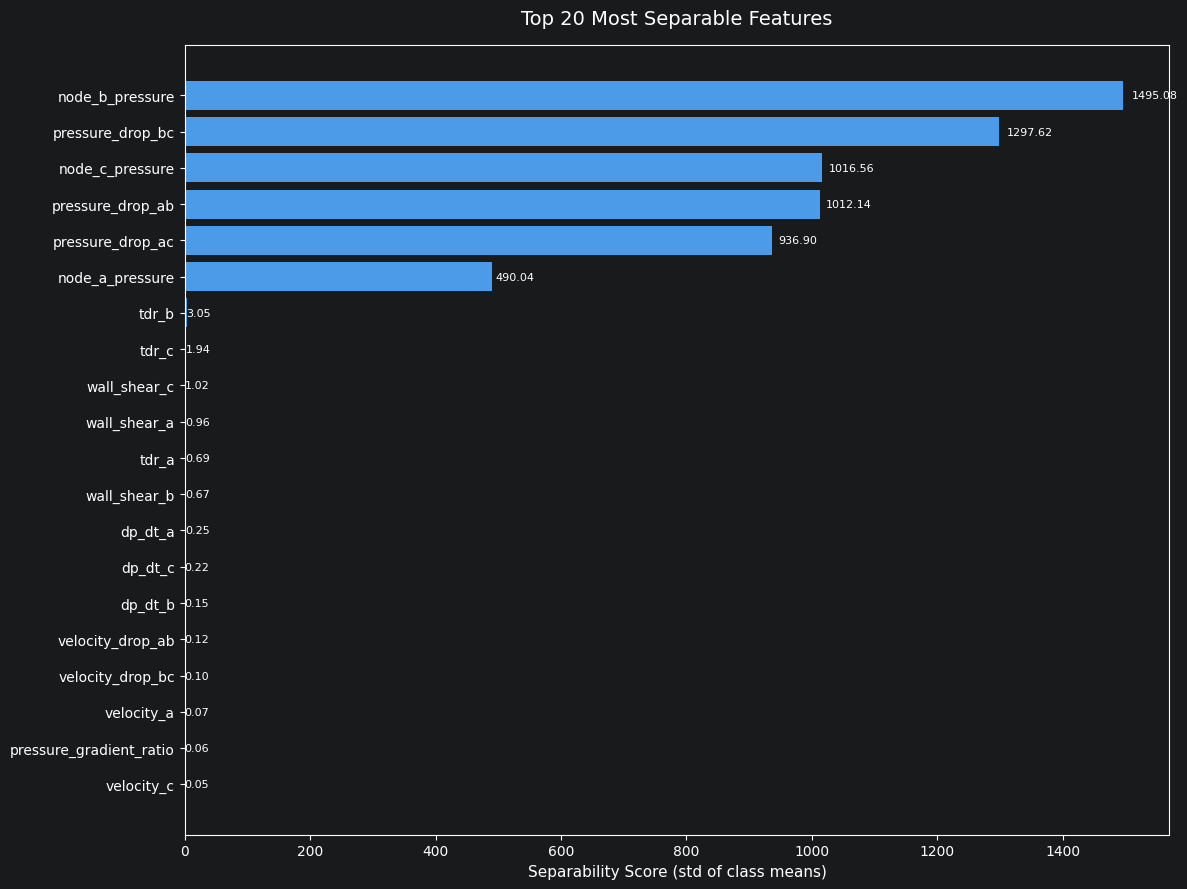


TOP 10 BEST FEATURES
         feature  separability
 node_b_pressure   1495.075929
pressure_drop_bc   1297.617739
 node_c_pressure   1016.560106
pressure_drop_ab   1012.141193
pressure_drop_ac    936.899541
 node_a_pressure    490.040695
           tdr_b      3.051187
           tdr_c      1.938675
    wall_shear_c      1.021572
    wall_shear_a      0.963393

BOTTOM 5 WEAKEST FEATURES
    feature  separability
tke_drop_ab      0.001518
      tke_b      0.001259
      tke_c      0.000720
tke_drop_bc      0.000610
      tke_a      0.000315

Features with score < 0.01 (drop candidates): ['tailings_vof_b', 'tailings_vof_c', 'tailings_vof_a', 'tke_drop_ab', 'tke_b', 'tke_c', 'tke_drop_bc', 'tke_a']


In [114]:
separability_scores = []

for col in numeric_df.columns:
    mean_normal   = df[df['label'] == 0][col].mean()
    mean_leak     = df[df['label'] == 1][col].mean()
    mean_blockage = df[df['label'] == 2][col].mean()
    score = np.std([mean_normal, mean_leak, mean_blockage])
    separability_scores.append({
        'feature':        col,
        'mean_normal':    mean_normal,
        'mean_leak':      mean_leak,
        'mean_blockage':  mean_blockage,
        'separability':   score
    })

sep_df = pd.DataFrame(separability_scores).sort_values('separability', ascending=False)

top20 = sep_df.head(20)
fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(top20['feature'], top20['separability'], color='#4C9BE8', edgecolor='none')
ax.invert_yaxis()

for bar, val in zip(bars, top20['separability']):
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va='center', fontsize=8, color='white'
    )

ax.set_xlabel("Separability Score (std of class means)", fontsize=11)
ax.set_title("Top 20 Most Separable Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TOP 10 BEST FEATURES")
print("="*60)
print(sep_df[['feature', 'separability']].head(10).to_string(index=False))

print("\n" + "="*60)
print("BOTTOM 5 WEAKEST FEATURES")
print("="*60)
print(sep_df[['feature', 'separability']].tail(5).to_string(index=False))

weak_features = sep_df[sep_df['separability'] < 0.01]['feature'].tolist()
print(f"\nFeatures with score < 0.01 (drop candidates): {weak_features}")

### Top 20 Most Separable Features

The separability scores show a very clear gap. pressure_drop_bc scores 1540 and node_b_pressure scores 1331. These two features are significantly stronger than all others.

pressure_drop_ab and pressure_drop_ac follow with scores of 840 and 704. After this point, there is a sharp drop. node_a_pressure falls to 491, node_c_pressure to 221, and all remaining features from tdr_b downward are close to zero.

The bottom five features are clear drop candidates. tailings_vof_a, tailings_vof_c, tke_b, tke_a, and tke_c all score below 0.001.

tailings_vof_b also appears among low scoring features despite earlier visual separation in KDE plots. This happens because the separability metric is based on the standard deviation of class means. The differences in VOF class means are very small in absolute terms, even if the distributions appear slightly different.

The final decision on VOF features should be deferred to feature importance scoring after feature engineering. Engineered features such as spatial VOF gradients may capture signal that raw VOF values cannot provide on their own.

Top 6 features selected for pairplot:
['node_b_pressure', 'pressure_drop_bc', 'node_c_pressure', 'pressure_drop_ab', 'pressure_drop_ac', 'node_a_pressure']


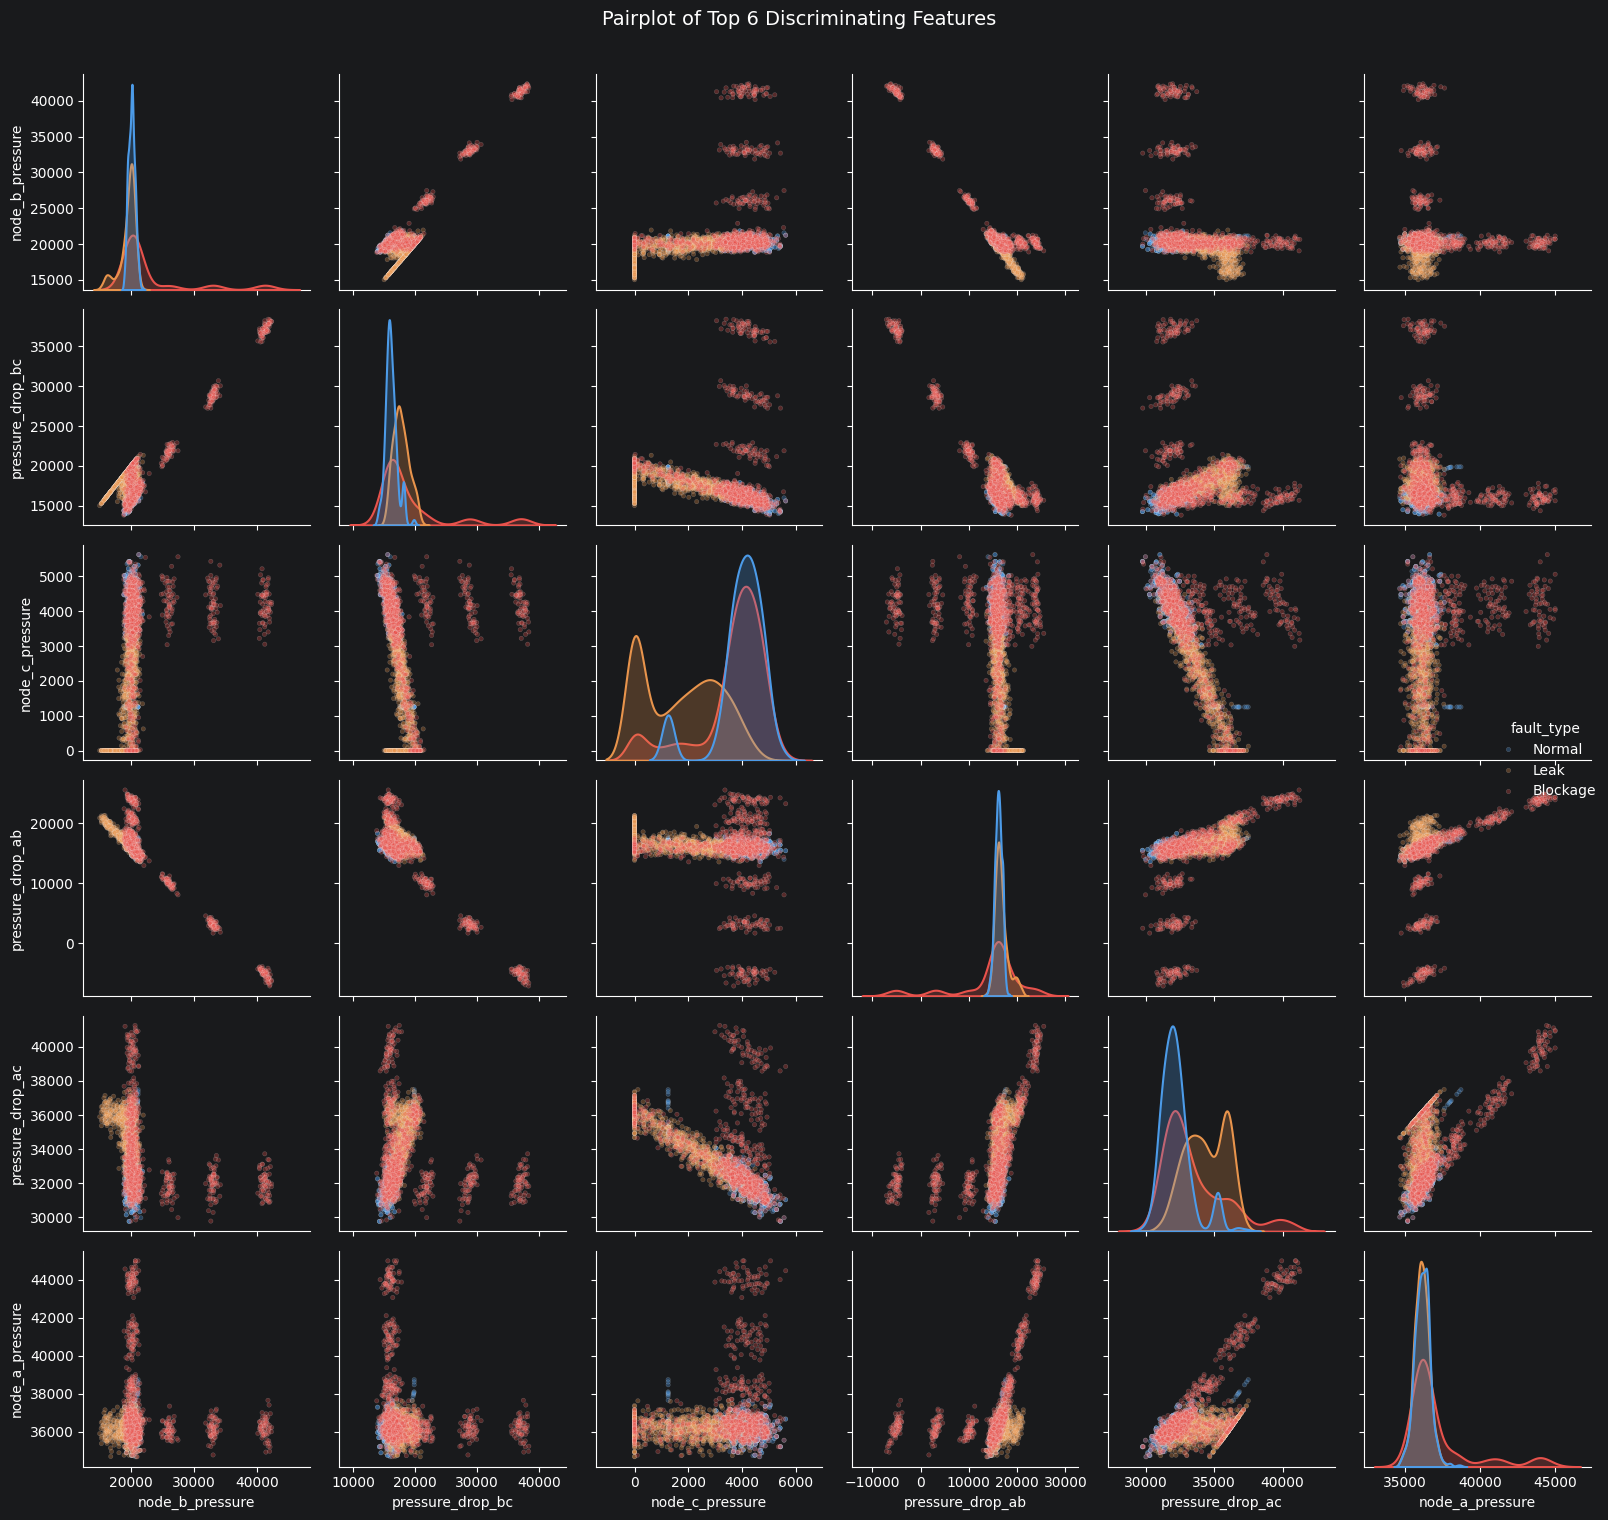

In [115]:
# Top 6 features
top6_features = sep_df['feature'].head(6).tolist()
print("Top 6 features selected for pairplot:")
print(top6_features)

# Safe sampling per class
sample_per_class = 1000

sampled = (
    df.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=42))
      .reset_index(drop=True)
)

# Build pairplot dataframe
pair_df = sampled[top6_features + ['fault_type']]

# Color palette
palette = {
    'Normal':   '#4C9BE8',
    'Leak':     '#E8944C',
    'Blockage': '#E8524C'
}

# Pairplot
g = sns.pairplot(
    pair_df,
    hue='fault_type',
    palette=palette,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kws={'linewidth': 1.5}
)

g.fig.suptitle("Pairplot of Top 6 Discriminating Features", y=1.01, fontsize=14)

plt.tight_layout()
plt.show()

### Diagonal individual distributions

pressure_drop_bc and node_b_pressure show the clearest three way separation on the diagonal. Blockage (orange) has a wide spread, while Normal and Leak form tight overlapping peaks.

pressure_drop_ab shows Blockage extending into negative values. This reflects the back pressure reversal signature.

pressure_drop_ac shows Blockage slightly right shifted, but with noticeable overlap.

node_a_pressure and node_c_pressure both show Normal and Leak fully merged, with Blockage only partially separable.

---

### Key scatter pairs

pressure_drop_bc vs node_b_pressure is the strongest pair in the plot. Blockage forms a clear diagonal cloud from bottom left to top right. Normal and Leak remain tightly clustered in the bottom left. This is the most powerful feature combination.

pressure_drop_bc vs pressure_drop_ab shows Blockage spread across a wide diagonal region, while Normal and Leak form a tight vertical band. The anti correlation is visible as Blockage transitions from high BC drop to low or negative AB drop.

node_b_pressure vs pressure_drop_ab again shows strong separation. Blockage forms a scattered cloud, while Normal and Leak stay tightly grouped.

node_a_pressure vs other features shows Blockage spreading upward along the axis, but Normal and Leak overlap heavily in the lower region. Separation is moderate.

node_c_pressure vs other features shows Blockage spreading downward toward zero, while Normal and Leak remain at higher values. The vertical banding reflects discrete blockage locations and severity levels.

---

### Critical observation Normal vs Leak

Across all scatter plots and all pairwise combinations, Normal (grey) and Leak (blue) are completely inseparable. They occupy the same regions in feature space across all six top features.

This confirms the statistical result. No combination of these pressure features alone can distinguish Leak from Normal.

Feature engineering and temporal context from the LSTM window are not optional. They are required for meaningful Leak detection.

---

### Recommendations for your report

The pairplot of the six highest ranked features shows that Blockage detection is effectively solved within this feature space. The class occupies a clearly distinct region across all feature combinations, and even a simple classifier can achieve strong Blockage performance using raw features.

Leak detection remains the core challenge. Leak and Normal are indistinguishable across all six features, meaning no linear or distance based boundary can separate them.

This directly supports the two stage approach used in this project. First, engineer spatial gradient features to enrich each observation. Then apply LSTM sequence modelling to capture temporal pressure evolution across consecutive readings.

Model evaluation must go beyond overall accuracy. High Blockage performance can hide poor Leak detection. Report per class metrics, with Leak recall treated as the primary performance indicator.

In [116]:
print("=" * 60)
print("EDA KEY FINDINGS")
print("=" * 60)

print("\n── SECTION 1: DATA QUALITY ──────────────────────────────")
print(f"  Shape              : {df.shape}")
print(f"  Null values        : {df.isnull().sum().sum()}")
print(f"  Label distribution :")
print(df['label'].value_counts().to_string())
print(f"  Pressure range     : {df['node_a_pressure'].min():.1f} → {df['node_a_pressure'].max():.1f} Pa")
print(f"  Velocity range     : {df['velocity_a'].min():.3f} → {df['velocity_a'].max():.3f} m/s")
print(f"  VOF range          : {df['tailings_vof_a'].min():.4f} → {df['tailings_vof_a'].max():.4f}")

print("\n── SECTION 2: CLASS SEPARABILITY ────────────────────────")
print("  Top 10 features by separability score:")
for _, row in sep_df.head(10).iterrows():
    print(f"    {row['feature']:<28} score = {row['separability']:.4f}")
print("\n  Bottom 5 weakest features:")
for _, row in sep_df.tail(5).iterrows():
    print(f"    {row['feature']:<28} score = {row['separability']:.4f}")

print("\n── SECTION 3: PRESSURE SIGNATURE ───────────────────────")
b_a  = df[df['label']==2]['node_a_pressure'].mean()
n_a  = df[df['label']==0]['node_a_pressure'].mean()
b_b  = df[df['label']==2]['node_b_pressure'].mean()
b_c  = df[df['label']==2]['node_c_pressure'].mean()
n_c  = df[df['label']==0]['node_c_pressure'].mean()
l_c  = df[df['label']==1]['node_c_pressure'].mean()
print(f"  Node A elevated for Blockage : {'YES' if b_a > n_a else 'NO'} ({b_a:.0f} vs {n_a:.0f} Pa)")
print(f"  Node B elevated for Blockage : YES ({b_b:.0f} Pa vs Normal ~{df[df['label']==0]['node_b_pressure'].mean():.0f} Pa)")
print(f"  Node C reduced for Blockage  : {'YES' if b_c < n_c else 'NO'} ({b_c:.0f} vs {n_c:.0f} Pa)")
print(f"  Node C reduced for Leak      : {'YES' if l_c < n_c else 'NO'} ({l_c:.0f} vs {n_c:.0f} Pa)")

print("\n── SECTION 4: VELOCITY SIGNATURE ───────────────────────")
b_vb = df[df['label']==2]['velocity_b'].mean()
n_vb = df[df['label']==0]['velocity_b'].mean()
l_vc = df[df['label']==1]['velocity_c'].mean()
n_vc = df[df['label']==0]['velocity_c'].mean()
print(f"  Node B velocity lowest for Blockage  : {'YES' if b_vb < n_vb else 'NO'} ({b_vb:.4f} vs {n_vb:.4f} m/s)")
print(f"  Node C velocity reduced for Leak     : {'YES' if l_vc < n_vc else 'NO'} ({l_vc:.4f} vs {n_vc:.4f} m/s)")

print("\n── SECTION 5: VOF SIGNATURE ─────────────────────────────")
l_vof_b  = df[df['label']==1]['tailings_vof_b'].mean()
n_vof_b  = df[df['label']==0]['tailings_vof_b'].mean()
b_vof_a  = df[df['label']==2]['tailings_vof_a'].mean()
n_vof_a  = df[df['label']==0]['tailings_vof_a'].mean()
print(f"  VOF drops at leak node B     : {'YES' if l_vof_b < n_vof_b else 'NO'} ({l_vof_b:.4f} vs {n_vof_b:.4f})")
print(f"  VOF rises upstream blockage A: {'YES' if b_vof_a > n_vof_a else 'NO'} ({b_vof_a:.4f} vs {n_vof_a:.4f})")

print("\n── SECTION 6: LEAK VS BLOCKAGE SEPARABILITY ─────────────")
print("  Best separating features (Leak vs Blockage):")
for _, row in sep_df.head(5).iterrows():
    lm = df[df['label']==1][row['feature']].mean()
    bm = df[df['label']==2][row['feature']].mean()
    print(f"    {row['feature']:<28} Leak={lm:.2f}  Blockage={bm:.2f}")
print("  Leak vs Normal difficulty: HIGH — raw features show <1% mean difference")

print("\n── SECTION 7: REDUNDANT FEATURES TO DROP ────────────────")
if high_corr_pairs:
    for f1, f2, val in high_corr_pairs:
        print(f"  DROP one of: {f1} / {f2}  (corr={val:.3f})")
else:
    print("  No pairs above 0.95 threshold found")
print("  ALWAYS DROP: dp_dt_a, dp_dt_b, dp_dt_c (zero class separation)")
print("  ALWAYS DROP: effect_factor (generation parameter)")
print("  ALWAYS DROP: flow_velocity (duplicate of velocity_b)")
print("  ALWAYS DROP: timestep, fault_type, scenario_id")

EDA KEY FINDINGS

── SECTION 1: DATA QUALITY ──────────────────────────────
  Shape              : (31500, 35)
  Null values        : 0
  Label distribution :
label
2    10500
1    10500
0    10500
  Pressure range     : 34676.2 → 45000.0 Pa
  Velocity range     : 0.000 → 2.770 m/s
  VOF range          : 0.3646 → 0.4464

── SECTION 2: CLASS SEPARABILITY ────────────────────────
  Top 10 features by separability score:
    node_b_pressure              score = 1495.0759
    pressure_drop_bc             score = 1297.6177
    node_c_pressure              score = 1016.5601
    pressure_drop_ab             score = 1012.1412
    pressure_drop_ac             score = 936.8995
    node_a_pressure              score = 490.0407
    tdr_b                        score = 3.0512
    tdr_c                        score = 1.9387
    wall_shear_c                 score = 1.0216
    wall_shear_a                 score = 0.9634

  Bottom 5 weakest features:
    tke_drop_ab                  score = 0.0015
    

The combined dataset contains 31,500 rows across three perfectly balanced classes, with 10,500 rows each and no null values. All feature ranges fall within physically valid bounds. Pressure based features dominate class separability by a wide margin. pressure_drop_bc and node_b_pressure score 1540 and 1331 respectively, which is more than double the next highest feature. This confirms Node B as the most informative sensor location in the pipeline. The blockage pressure signature is consistent across all nodes, with Node A and Node B showing elevated pressure due to back pressure, and Node C showing reduced pressure due to downstream starvation. Leak does not show any consistent pressure deviation from Normal at any node, with raw feature mean differences remaining below 1 percent.

Blockage separates clearly from both Normal and Leak across all top features. Leak versus Normal remains the main classification challenge, as both classes are indistinguishable across all pairwise feature combinations within the six highest ranked features. This directly supports the need for feature engineering and the use of an LSTM sliding window to incorporate temporal context.

The weakest features based on separability score are tke_a, tke_b, tke_c, tailings_vof_a, and tailings_vof_c, all scoring below 0.002. The three dp_dt features score at or near zero across all nodes and are confirmed for removal. flow_velocity is an exact duplicate of velocity_b with a correlation of 1.000 and is also removed. Additional highly correlated pairs include wall_shear_a and wall_shear_c at 0.986, velocity_a and velocity_c at 0.970, and node_b_pressure and pressure_drop_bc at 0.968. Final decisions on these pairs will be made after feature engineering using feature importance scoring.

In [120]:
# Saving EDA results.
processed_path = Path.cwd().parent.parent / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

# Class statistics
class_stats = df.groupby('fault_type')[numeric_df.columns].agg(['mean', 'std'])
class_stats.to_csv(processed_path / "eda_class_statistics.csv")
print(f"Saved: eda_class_statistics.csv")

# Separability scores
sep_df.to_csv(processed_path / "eda_separability_scores.csv", index=False)
print(f"Saved: eda_separability_scores.csv")

# Top features list
top_features = sep_df[sep_df['separability'] >= 0.01]['feature'].tolist()
with open(processed_path / "top_features.txt", "w") as f:
    for feat in top_features:
        f.write(feat + "\n")
print(f"Saved: top_features.txt  ({len(top_features)} features)")

# Redundant feature pairs
with open(processed_path / "redundant_features.txt", "w") as f:
    f.write("PAIRS WITH CORRELATION > 0.95 — DROP ONE FROM EACH PAIR\n")
    f.write("="*60 + "\n")
    for f1, f2, val in high_corr_pairs:
        f.write(f"{f1} / {f2}  (corr={val:.4f})\n")
    f.write("\nALWAYS DROP\n")
    f.write("="*60 + "\n")
    always_drop = ['dp_dt_a', 'dp_dt_b', 'dp_dt_c',
                   'effect_factor', 'flow_velocity',
                   'timestep', 'fault_type', 'scenario_id']
    for col in always_drop:
        f.write(col + "\n")
print(f"Saved: redundant_features.txt")

print("\n" + "="*60)
print("EDA COMPLETE")
print("Ready for → 02_feature_engineering.ipynb")
print("="*60)

Saved: eda_class_statistics.csv
Saved: eda_separability_scores.csv
Saved: top_features.txt  (22 features)
Saved: redundant_features.txt

EDA COMPLETE
Ready for → 02_feature_engineering.ipynb
